# Сборный проект: Оценка риска ДТП

**Описание проекта**

Специалистам по Data Science в каршеринговой компании поступил заказ: нужно создать систему, которая могла бы оценить риск ДТП по выбранному маршруту движения. Под риском понимается вероятность ДТП с любым повреждением транспортного средства. Как только водитель забронировал автомобиль, сел за руль и выбрал маршрут, система должна оценить уровень риска. Если уровень риска высок, водитель увидит предупреждение и рекомендации по маршруту.

**Идея решения задачи**

Идея создания такой системы находится в стадии предварительного обсуждения и проработки. Чёткого алгоритма работы и подобных решений на рынке ещё не существует. Текущая задача — понять, возможно ли предсказывать ДТП, опираясь на исторические данные одного из регионов.

Идея решения задачи от заказчика:

- Создать модель предсказания ДТП (целевое значение — at_fault (виновник) в таблице parties)
     
1. Для модели выбрать тип виновника — только машина (car).
2. Выбрать случаи, когда ДТП привело к любым повреждениям транспортного средства, кроме типа SCRATCH (царапина).
3. Для моделирования ограничиться данными за 2012 год — они самые свежие.
4. Обязательное условие — учесть фактор возраста автомобиля.
- На основе модели исследовать основные факторы ДТП.
- Понять, помогут ли результаты моделирования и анализ важности факторов ответить на вопросы:
     
* Возможно ли создать адекватную системы оценки водительского риска при выдаче авто?
* Какие ещё факторы нужно учесть?
* Нужно ли оборудовать автомобиль какими-либо датчиками или камерой?

Заказчик предлагает нам поработать с базой данных по происшествиям и сформировать свои идеи создания такой системы.

**Оформление**

Выполните задание в Jupyter Notebook. Заполните программный код в ячейках типа code, текстовые пояснения — в ячейках типа markdown. Примените форматирование и заголовки.

**ER - диаграмма**

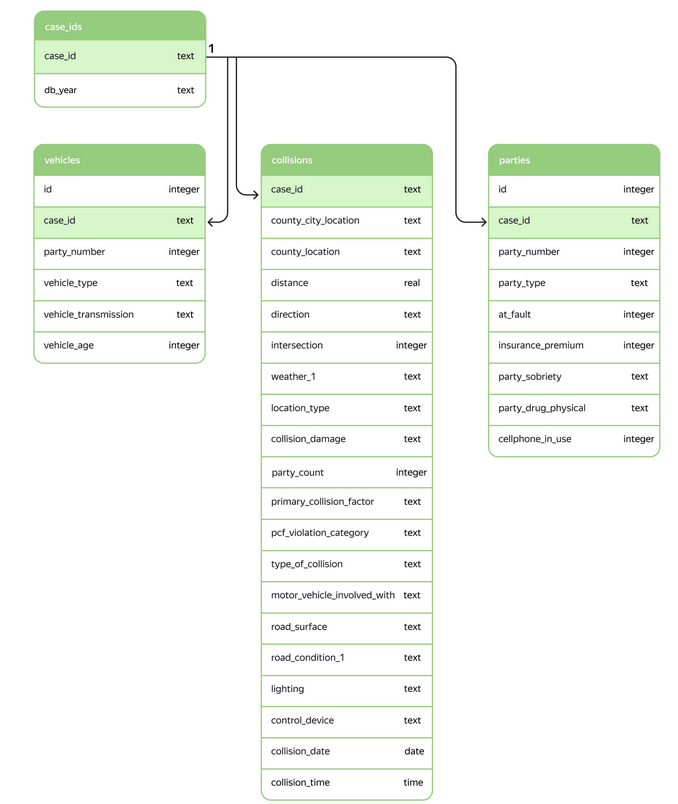!

**Краткое описание таблиц**

- **collisions** — общая информация о ДТП

Имеет уникальный case_id. Эта таблица описывает общую информацию о ДТП. Например, где оно произошло и когда.
      
- **parties**  — информация об участниках ДТП

Имеет неуникальный case_id, который сопоставляется с соответствующим ДТП в таблице collisions. Каждая строка здесь описывает одну из сторон, участвующих в ДТП. Если столкнулись две машины, в этой таблице должно быть две строки с совпадением case_id. Если нужен уникальный идентификатор, это case_id and party_number.
      
- **vehicles**  — информация о пострадавших машинах

Имеет неуникальные case_id и неуникальные party_number, которые сопоставляются с таблицей collisions и таблицей parties. Если нужен уникальный идентификатор, это case_id and party_number.
      
Более подробное описание данных было предоставлено нам дополнительно, однако ввиду своей объемности, оно будет отображено в приложении.

## Загрузка библиотек и установление констант

Загрузим и подключим необходимые для работы над проектом библиотеки, а также зададим константы, которые будем использовать далее.

Для работы с SQL запросами будем использовать библиотеку SQLAlchemy — она одна из самых распространённых. Также для работы с проектом потребуется загрузка иных библиотек, котрых нет "в коробке".

In [ ]:
# в тренажере уже установлена, поэтому закомменчено
#!pip install sqlalchemy # установка библиотеки для работы с SQL-запросами

In [ ]:
# подгружаем и обновляем необходимые библиотеки
# "выключаем звук" (строчки с текстом по мере загрузки) с помощью -q

!pip install scikit-learn==1.5.2 -q # обновление для корректной работы некоторых частей кода

!pip install missingno -q # удобная визуализация пропусков

# признаки
!pip install phik -q # весы и корреляция
!pip install shap -q # оценка важности признаков

# модели
##!pip install catboost -q # СatBoost, вроде есть в пакете "по-умолчанию" в тренажере
!pip install lightgbm -q # LightGBM

Минимумом для части проекта, связанного с SQL нам понадобится pandas (для работы с датафреймами), matplotlib (для визуализации данных) и функция create_engine() из библиотеки SQLAlchemy для подключения к базе данных и выполнения SQL-запроса.

Но для остальной части библиотек потребуется гораздо больше. Подключим их.

In [ ]:
# подключаем библиотеки
import pandas as pd # работа с данными в формате таблиц
import numpy as np # математические операции и работа с массивами
import math # расширенная работа с числами
from math import ceil # функция ceil округляет число до ближайшего целого в большую сторону
# import random # для контроля над некоторыми рандомами (обеспечение воспроизводимости)
import time # расчет времени выполнения функций

# расширение дисплея для отображения информации
from IPython.display import display

# SQL-запросы
from sqlalchemy import create_engine # для подключения к базе данных и выполнения SQL-запроса

# "выключаем" красные предупреждения.
#import warnings
#warnings.filterwarnings('ignore', category=FutureWarning)

# визуализация данных
import seaborn as sns # для некоторых графиков и матриц
import matplotlib.pyplot as plt # для некоторых графиков
import missingno as msno # для удобной визуализации пропусков

# корреляция
#import phik # дублирование для иных проектов и платформ (может не требоваться в данном проекте, тк загружали ее выше)
from phik import phik_matrix # вариант матрицы корреляции
from phik.report import plot_correlation_matrix # ее отрисовка

# подготовка данных
from sklearn.model_selection import train_test_split # для разбивки на выборки для МО
from sklearn.utils import shuffle # перемешивание данных для уравновешивания их в разных выборках
from sklearn.preprocessing import(
# кодировка категориальных признаков
    OneHotEncoder, # номинальные
    OrdinalEncoder, # ранговые
    StandardScaler, # масштабирование количественных
    )
from sklearn.impute import SimpleImputer # работа с пропусками при кодировании

# инструменты для работы с пайплайнами

#класс, который позволяет объединить несколько шагов обработки данных в одну структуру.
# он принимает список кортежей, где каждый кортеж содержит название шага и соответствующий объект-преобразователь или модель
# from sklearn.pipeline import Pipeline # пайплайны

# вспомогательная функция, которая упрощает создание экземпляра Pipeline.
# Она автоматически назначает имена шагов на основе имён передаваемых объектов
# и позволяет быстро создать пайплайн без необходимости явно указывать названия шагов.
from sklearn.pipeline import make_pipeline

from sklearn.compose import(
    #ColumnTransformer # помогает работать с данными разного типа в одном наборе
    # варианты ниже более гибкие
    # функция для создания объекта ColumnTransformer,
    # который позволяет применять различные преобразования к выбранным столбцам датасета
    make_column_transformer,
    # функция для создания селектора столбцов, который можно использовать в ColumnTransformer.
    # cелектор позволяет выбирать столбцы для преобразования
    # на основе их имён или типов данных, что упрощает настройку и применение трансформаций к нужным столбцам
    make_column_selector
    )

# модели
# базовая даммми-модель для сравнения
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression # логистическая регрессия
from sklearn.ensemble import RandomForestClassifier # лес случайных деревьев
import lightgbm as lgb # для некоторых действий по подготовке
from lightgbm import LGBMClassifier # LightGBM модель
from catboost import CatBoostClassifier # CatBoost

# автоподбор параметров моделей
from sklearn.model_selection import GridSearchCV

#кросс-валидация
from sklearn.model_selection import KFold # создание блоков
from sklearn.model_selection import cross_val_score # оценка модели на кросс-валидации

# метрики моделей
from sklearn.metrics import(
    confusion_matrix, # матрица ошибок
    ConfusionMatrixDisplay, # класс для визуализации матрицы ошибок в виде тепловой карты или таблицы
    f1_score, # f1-метрика, уже включена в объединенную групу ниже, но тут нужна для иного подхода к оценке
    # функция для генерации отчёта по классификации, который включает такие метрики,
    # как точность (precision), полнота (recall), F1-мера и поддержка (количество экземпляров каждого класса) для каждого класса
    classification_report,
    # следующие нужны для анализа и визуализации работы бинарных признаков
    precision_recall_curve, # вычисляет точность, полноту и пороги вероятности, при которых вычисляются метрики
    PrecisionRecallDisplay # визуализация кривой Prescision-Recall
    )

# для оценки вкладов признаков
#from sklearn.inspection import permutation_importance # важность перестановок
import shap # с помощью значений Шепли
shap.initjs()   # отображение результатов

In [ ]:
# задаем настройки отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.options.display.float_format ='{:,.2f}'.format
sns.set_theme(style='whitegrid', palette='pastel')
sns.set_context(
    'notebook',
    rc={
        'font.size':12,
        'axes.titlesize':16,
        'axes.labelsize':12,
        'legend.fontsize':12,
        'figure.figsize':(14, 7)
    }
)

# отключаем предупреждения:
# когда используется функционал, который в будущем может измениться или устареть
#warnings.simplefilter(action='ignore', category=FutureWarning)
# когда выполняется присваивание значений через несколько индексов или атрибутов,
# и библиотека не может однозначно определить, является ли это намеренным действием или потенциальной ошибкой
#pd.options.mode.chained_assignment = None

# задаем класс для стилизации вывода метода .print()
class color:
   PURPLE = '\033[95m'
   CYAN = '\033[96m'
   DARKCYAN = '\033[36m'
   BLUE = '\033[94m'
   GREEN = '\033[92m'
   YELLOW = '\033[93m'
   RED = '\033[91m'
   BOLD = '\033[1m'
   UNDERLINE = '\033[4m'
   END = '\033[0m'

In [ ]:
# задаем константы
# для фиксации объектов тренировочной и тестовой выборок
RANDOM_STATE = 42
# для пропорционального разделения датасета на тренировочную и тестовую выборки
TEST_SIZE = 0.25

**Вывод**

Необходимые для работы библиотеки подключены, некоторые константы заданы, стиль отображения настроен.

## Подключение к базе. Загрузка таблицы sql

Подключимся к базе данных, используя полученные для проекта данные. Эти данные удобно записать в объект, чтобы потом их было легко поправить.

In [ ]:
# параметры сделаны неработоспособными в рамках этичности работы с предоставляемыми данными
# настройка конфигурации
db_config = {
'user': 'имя_удалено', # имя пользователя,
'pwd': 'пароль_удален', # пароль,
'host': 'хост_удален.mdb.yandexcloud.net',
'port': 6432, # порт подключения,
'db': 'data-science-vehicle-db' # название базы данных,
}

После того как данные для авторизации записаны в объект db_config, нужно передать функции create_engine() строку для соединения с базой данных. Строка содержит информацию об используемой СУБД, а также все данные для авторизации.

Сформируем строку для подключения с помощью метода .format():

In [ ]:
# формирование строки для подключения с посощью метода .format()
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

Чтобы создать соединение передадим функции create_engine() строку с данными для подключения:

In [ ]:
# создаем подключение
engine = create_engine(connection_string)

Теперь, когда мы подключились к базе, можно извлекать результаты SQL-запроса.

**Вывод**

Мы настроили конфигурацию подключения, а затем подключились к базе.

## Первичное исследование таблиц

Сначала посмотрим на ER-диаграмму. Мы можем увидеть, что наша БД имеет структуру, которая напоминает звездообразную (Star Schema) или снежинку (Snowflake Schema), используемые в хранилищах данных.

Ключевые признаки:  
1. Центральная таблица (`'statistics'`), которая является таблицей фактов (хранит основные события — например, данные о ДТП).  
2. Таблицы-измерения (`'variables'`, `'parity'`), которые содержат дополнительные атрибуты (например, информацию о транспортных средствах или участниках).  
3. Связи через `'case_id'` — это внешний ключ, объединяющий таблицы.  

Так как таблицы `'variables'` и `'parity'` не нормализованы (например, `'vehicle_type'` хранится прямо в `'variables'` без отдельной таблицы), это скорее всего - звезда (Star Schema).  

После изучения ER-диаграммы перейдем к непосредственному изучению самих таблиц в нашей БД. В рамках поставленной задачи нам необходимо исследовать следующее:

- Все ли таблицы имеют набор данных;
- Соответствует ли количество таблиц условию задачи;
- Имеется ли общий ключ для связи таблиц.

Для обзора таблиц необходимо использовать SQL-запрос.

Запрос можно записывать в переменную query — так его удобнее редактировать. Сам же запрос лучше записывать в тройные кавычки — так в Python обозначают многострочную строку. Результат выдачи SQL-запроса можно записать в датафрейм с помощью метода pd.read_sql_query(), после чего с данными SQL-запроса можно работать как с датафреймом.

Для начала посмотрим названия таблиц в БД.

In [ ]:
# получаем список пользовательских таблиц в базе данных,
# игнорируя системные таблицы и таблицы, связанные с информационной схемой PostgreSQL
query = '''
SELECT table_name
  FROM information_schema.tables
 WHERE table_schema NOT IN ('information_schema','pg_catalog');
'''
df = pd.read_sql_query(query, con=engine)
df

,table_name
0,case_ids
1,collisions
2,parties
3,vehicles


Названия таблиц совпадают с заявленными. Теперь выведем первые 10 строк этих таблиц.

In [ ]:
# первые 10 строк из объединяющей таблицы
# используем LIMIT вместо .head() чтобы не подгружать лишнее
query = '''
SELECT *
  FROM case_ids
  LIMIT 10;
'''
df = pd.read_sql_query(query, con=engine)
#df.head()
df

,case_id,db_year
0,0081715,2021
1,0726202,2021
2,3858022,2021
3,3899441,2021
4,3899442,2021
5,3899445,2021
6,3899446,2021
7,3899449,2021
8,3899450,2021
9,3899453,2021


In [ ]:
# первые 10 строк из таблицы с происшествиями
# используем LIMIT вместо .head() чтобы не подгружать лишнее
query = '''
SELECT *
  FROM collisions
  LIMIT 10;
'''
df = pd.read_sql_query(query, con=engine)
#df.head()
df

,case_id,county_city_location,county_location,distance,direction,intersection,weather_1,location_type,collision_damage,party_count,primary_collision_factor,pcf_violation_category,type_of_collision,motor_vehicle_involved_with,road_surface,road_condition_1,lighting,control_device,collision_date,collision_time
0,4083072,1942,los angeles,528.00,north,0,cloudy,highway,small damage,2,vehicle code violation,unsafe lane change,sideswipe,other motor vehicle,wet,normal,daylight,none,2009-01-22,07:25:00
1,4083075,4313,santa clara,0.00,None,1,clear,None,small damage,1,vehicle code violation,improper passing,hit object,fixed object,dry,normal,dark with street lights,functioning,2009-01-03,02:26:00
2,4083073,0109,alameda,0.00,None,1,clear,None,scratch,2,vehicle code violation,improper turning,broadside,other motor vehicle,dry,normal,dark with street lights,functioning,2009-01-11,03:32:00
3,4083077,0109,alameda,0.00,None,1,clear,None,scratch,2,vehicle code violation,automobile right of way,broadside,other motor vehicle,dry,normal,daylight,functioning,2009-01-11,10:35:00
4,4083087,4313,santa clara,0.00,None,1,clear,None,scratch,2,vehicle code violation,speeding,rear end,other motor vehicle,dry,None,dark with street lights,functioning,2009-01-02,22:43:00
5,4083097,0109,alameda,0.00,None,1,clear,ramp,small damage,2,vehicle code violation,speeding,rear end,other motor vehicle,dry,normal,dark with street lights,functioning,2009-01-18,02:18:00
6,4083092,1942,los angeles,"1,320.00",south,0,clear,highway,scratch,2,vehicle code violation,unsafe lane change,rear end,other motor vehicle,dry,normal,daylight,none,2009-01-21,10:30:00
7,4083096,1942,los angeles,200.00,south,0,clear,highway,scratch,3,vehicle code violation,speeding,rear end,other motor vehicle,dry,normal,daylight,none,2009-01-21,08:55:00
8,4083100,1942,los angeles,"2,112.00",north,0,cloudy,highway,scratch,2,vehicle code violation,speeding,rear end,other motor vehicle,dry,normal,daylight,none,2009-01-21,16:20:00
9,4083103,4313,santa clara,0.00,None,1,cloudy,None,scratch,2,vehicle code violation,None,broadside,other motor vehicle,wet,normal,dusk or dawn,functioning,2009-01-02,15:55:00


In [ ]:
# первые 10 строк из таблицы c описанием участников происшествия
# используем LIMIT вместо .head() чтобы не подгружать лишнее
query = '''
SELECT *
  FROM parties
  LIMIT 10;
'''
df = pd.read_sql_query(query, con=engine)
#df.head()
df

,id,case_id,party_number,party_type,at_fault,insurance_premium,party_sobriety,party_drug_physical,cellphone_in_use
0,22,3899454,1,road signs,1,29.00,had not been drinking,None,0.00
1,23,3899454,2,road signs,0,7.00,had not been drinking,None,0.00
2,29,3899462,2,car,0,21.00,had not been drinking,None,0.00
3,31,3899465,2,road signs,0,24.00,had not been drinking,None,0.00
4,41,3899478,2,road bumper,0,NaN,not applicable,not applicable,0.00
5,43,3899481,2,road bumper,0,NaN,not applicable,not applicable,0.00
6,72,3899505,2,road bumper,0,NaN,not applicable,not applicable,0.00
7,73,3899505,3,road bumper,0,NaN,not applicable,not applicable,0.00
8,76,3899509,1,road bumper,0,NaN,had not been drinking,None,0.00
9,93,3981292,2,road bumper,0,NaN,had not been drinking,None,NaN


In [ ]:
# первые 10 строк из таблицы c описанием автомобиля
# используем LIMIT вместо .head() чтобы не подгружать лишнее
query = '''
SELECT *
  FROM vehicles
  LIMIT 10;
'''
df = pd.read_sql_query(query, con=engine)
#df.head()
df

,id,case_id,party_number,vehicle_type,vehicle_transmission,vehicle_age
0,1175713,5305032,2,sedan,manual,3
1,1,3858022,1,sedan,auto,3
2,1175712,5305030,1,sedan,auto,3
3,1175717,5305033,3,sedan,auto,5
4,1175722,5305034,2,sedan,auto,5
5,1175737,5305046,2,sedan,auto,5
6,1175750,5305053,3,sedan,auto,9
7,1175715,5305033,1,sedan,manual,10
8,1175716,5305033,2,sedan,manual,4
9,1175758,5305060,2,sedan,auto,11


Здесь мы можем наблюдать, что названия столбцов расходятся в написании с теми, что были выданы нам предварительно в описании проекта, где все были указаны целиком прописными буквами (несмотря на строчные в ER-диаграмме), а также частично не совпадают имена столбцов (например, в прилагаемом в водной части проекта описании было заявлено `'PRIMARY_COLL_FACTOR'` вместо реального `'primary_collision_factor'` в таблице `'collisions'`)

В самом же содержимом столбцов также не всегда совпадают обозначения (например, было заявлено `'N'` (Север) в столбце с направлением движения таблицы  `'collisions'` вместо реального `'north'`).

Возможно, в реальности таблицы выглядят так, как было заявлены в исходном вводном описании, а для проекта были специально заранее приведены в понятный вид (без лишнего кодирования). Но узнать это не представляется возможным.

Также в исходном описании порядок столбцов в таблицах несколько отличался.

При этом наименования и порядок столбцов совпадает с ER-диаграммой. Поэтому необходимо обратить внимание заказчика на данный момент и рекомендовать актуализировать описание данных.

Также у нас нет описания, что содержит столбец `'db_year'` в таблице `'case_ids'`, но мы можем предполагать, что это год происшествия. Попробуем это проверить, выведя информацию по какому-нибудь происшествию с индексом из первых 10 строк, которые мы видели ранее.

In [ ]:
# первые 10 строк из таблицы с происшествиями
# значение case_id в кавычках, так как согласно ER-диаграмме содержимое представлено тесктом.
query = '''
SELECT collision_date,
    collision_time
  FROM collisions
  WHERE case_id IN ('0081715', '0726202', '3858022');
  '''
df = pd.read_sql_query(query, con=engine)
#df.head()
df

,collision_date,collision_time
0,2020-03-14,07:45:00
1,2020-07-26,02:50:00
2,2009-02-03,17:11:00


Нет, это не год происшествия, но может быть годом выгрузки. Попробуем проверить этот вариант.

In [ ]:
# считаем уникальные значения
query = '''
SELECT COUNT (DISTINCT db_year)
  FROM case_ids;
'''
df = pd.read_sql_query(query, con=engine)
df

,count
0,1


Так как значение у нас одно, версия, что столбец `'db_year'` содержит год выгрузки БД выглядит вполне реальной. Поэтому также необходимо обратить внимание заказчика на отсутствие описания для данного столбца.

Ввиду того, что столбец `'case_id'` у нас содержится во всех таблицах (согласно ER-диаграмме), столбец `'db_year'` имеет одинаковое значение для всех строк, целесообразность наличия таблицы `'case_ids'` находится под вопросом (что тоже требует внимания заказчика).

Также мы могли заметить в ER-диаграмме (и это подтвердилось при запросе) использование для столбца `'case_id'` текстового формата вместо численного. Правильнее было бы (с учетом наличия исключительно чисел в наблюдаемых частях таблиц) использовать числовой формат, в том числое для экономии места. Это тоже стоит отнести к рекомендациям для заказчика, однако стоит учесть, что возможно заказчик выбрал такую систему "навырост" (чтобы не увеличивать длину id, когда закончаться цифры, и начать использовать буквы).

Изучим нашу базу данных чуть подробнее. Для начала - посмотрим на размер.

In [ ]:
# размер БД
query = '''
SELECT pg_size_pretty(pg_database_size(current_database()));
    '''
df = pd.read_sql_query(query, con=engine)
df

,pg_size_pretty
0,790 MB


С учетом имеющегося размера БД и того, что она наверняка будет пополняться, рекомендации по измению формата данных для идентификатора происшествий и удаления таблицы с сомнительной полезностью для экономии места выглядит еще более актуальной.

Теперь посмотрим, какие колонки имеются в наших таблицах и какой тип данных они имеют. Для удобства изучения, сделаем это вывод для каждой таблицы отдельно.

In [ ]:
# смотрим названия стобцов
# для таблицы case_ids
query = '''
SELECT table_name,
       column_name,
       data_type
  FROM information_schema.columns
  WHERE table_name = 'case_ids';
'''
df = pd.read_sql_query(query, con=engine)
df

,table_name,column_name,data_type
0,case_ids,case_id,text
1,case_ids,db_year,text


In [ ]:
# смотрим названия стобцов
# для таблицы с происшествиями
query = '''
SELECT table_name,
       column_name,
       data_type
  FROM information_schema.columns
  WHERE table_name = 'collisions';
'''
df = pd.read_sql_query(query, con=engine)
df

,table_name,column_name,data_type
0,collisions,party_count,integer
1,collisions,intersection,integer
2,collisions,distance,real
3,collisions,collision_date,date
4,collisions,collision_time,time without time zone
5,collisions,location_type,text
6,collisions,collision_damage,text
7,collisions,case_id,text
8,collisions,pcf_violation_category,text
9,collisions,type_of_collision,text


In [ ]:
# смотрим названия стобцов
# для таблицы с участниками
query = '''
SELECT table_name,
       column_name,
       data_type
  FROM information_schema.columns
  WHERE table_name = 'parties';
'''
df = pd.read_sql_query(query, con=engine)
df

,table_name,column_name,data_type
0,parties,cellphone_in_use,integer
1,parties,party_number,integer
2,parties,at_fault,integer
3,parties,insurance_premium,integer
4,parties,id,integer
5,parties,case_id,text
6,parties,party_drug_physical,text
7,parties,party_type,text
8,parties,party_sobriety,text


In [ ]:
# смотрим названия стобцов
# для таблицы с автомобилями
query = '''
SELECT table_name,
       column_name,
       data_type
  FROM information_schema.columns
  WHERE table_name = 'vehicles';
'''
df = pd.read_sql_query(query, con=engine)
df

,table_name,column_name,data_type
0,vehicles,id,integer
1,vehicles,party_number,integer
2,vehicles,vehicle_age,integer
3,vehicles,case_id,text
4,vehicles,vehicle_type,text
5,vehicles,vehicle_transmission,text


Типы данных соответствуют заявляемым. И соответствуют содержимому (за исключением ранее обозначенного `'case_id'`).

Посмотрим на первичные и внешние ключи.

In [ ]:
# смотрим первичные и внешние ключи
query = '''
SELECT constraint_name,
       table_name,
       column_name
  FROM information_schema.key_column_usage
  WHERE table_name IN ('case_ids', 'collisions', 'parties', 'vehicles');
'''
df = pd.read_sql_query(query, con=engine)
df

,constraint_name,table_name,column_name
0,case_ids_pk,case_ids,case_id
1,collisions_case_ids_case_id_fk,collisions,case_id
2,parties_pk,parties,id
3,parties_case_ids_case_id_fk,parties,case_id
4,vehicles_pk,vehicles,id
5,vehicles_case_ids_case_id_fk,vehicles,case_id


Похоже, что в таблице `'collisions'` отсутствует первичный ключ. Проверим уникальность значений столбца `'case_id'`.

In [ ]:
# проверяем уникальность
query = '''
SELECT COUNT(case_id) AS total_ids,
       COUNT(DISTINCT case_id) AS unique_ids
  FROM collisions;
'''
df = pd.read_sql_query(query, con=engine)
df

,total_ids,unique_ids
0,1400000,1400000


Все значения в данном столбце уникальны.

Также можно заметить, что первичный ключ в таблицах `'parties'` и `'vehicles'` не совпадает с внешним ключом к таблице `'case_ids'`, и одному `'case_id'` может быть сопоставлено несколько `'id'` из этих таблиц. Хотя это и логично - так как в одном ДТП может быть несколько участников (исходя из содержимого таблиц `'parties'` и `'vehicles'`), и это также отмечено в описании к данным.

Также помним, что таблица `'collisions'` является для нас центральной, так как описывает само ДТП, а таблицы `'parties'` и `'vehicles'` дополняют ее описаниями участников и автомобилей (которых может быть несколько для каждого ДТП). Плюс таблица `'parties'` содержит в себе целевой признак `'at_fault'`, то есть для работы с данными нам придется объединять эти таблицы.

Проверим совпадение `'case_id'` среди разных таблиц - возможно не каждый из них входит во все таблицы, что необходимо будет учесть в будущем.

In [ ]:
### Сводная статистика (в один запрос)
query = '''
WITH
collisions_with_parties AS (
    SELECT DISTINCT case_id FROM parties
),
collisions_with_vehicles AS (
    SELECT DISTINCT p.case_id
    FROM parties p
    JOIN vehicles v ON p.case_id = v.case_id AND p.party_number = v.party_number
)
SELECT
    (SELECT COUNT(*) FROM collisions) AS total_collisions,
    (SELECT COUNT(*) FROM collisions_with_parties) AS collisions_with_any_party,
    (SELECT COUNT(*) FROM collisions_with_vehicles) AS collisions_with_any_vehicle,
    (SELECT COUNT(*) FROM collisions) - (SELECT COUNT(*) FROM collisions_with_parties)
        AS collisions_without_any_party,
    (SELECT COUNT(*) FROM collisions_with_parties) - (SELECT COUNT(*) FROM collisions_with_vehicles)
        AS collisions_with_party_but_no_vehicle;
 '''
df = pd.read_sql_query(query, con=engine)
df

,total_collisions,collisions_with_any_party,collisions_with_any_vehicle,collisions_without_any_party,collisions_with_party_but_no_vehicle
0,1400000,1400000,792642,0,607358


Как мы видим, для всех случаев ДТП (`'case_id'`) из таблицы `'collisions'` есть информация по участникам из таблицы `'parties'`, но не для всех автомобилей из таблицы `'vehicle'`. Так как заказчик - сервис каршеринга, и в имеющихся ДТП обязательным участником являлся их автомобиль (который имел определенные характеристики и мог пострадать различным образом), то это выглядет утерей данных. На что стоит обратить внимание заказчика, а также учесть при работе с данными (не используя FULL JOIN в некоторых случаях, ограничиваясь INNER JOIN (который используется по-умолчанию), чтоб избежать образования лиших пропусков в отсутсвующих данных и избежать искажения данных при заполнении эти самых пропусков).

Проведем дополнительную проверку (уже на всех табицах). Этот анализ поможет понять, насколько данные полны и согласованы.

In [ ]:
# сводная статистика (в один запрос)
# на все таблицы сразу
query = '''
WITH
-- Общее количество записей
stats AS (
    SELECT
        (SELECT COUNT(*) FROM collisions) AS total_collisions,
        (SELECT COUNT(*) FROM parties) AS total_parties,
        (SELECT COUNT(*) FROM vehicles) AS total_vehicles
),

-- Уникальные case_id, которые есть в parties и vehicles
parties_case_ids AS (
    SELECT DISTINCT case_id FROM parties
),
vehicles_case_ids AS (
    SELECT DISTINCT p.case_id
    FROM parties p
    JOIN vehicles v ON p.case_id = v.case_id AND p.party_number = v.party_number
),

-- Пересечения между таблицами
matches AS (
    SELECT
        -- Сколько collisions имеют записи в parties?
        (SELECT COUNT(DISTINCT c.case_id)
         FROM collisions c
         JOIN parties p ON c.case_id = p.case_id) AS collisions_with_parties,

        -- Сколько collisions имеют записи в parties И vehicles?
        (SELECT COUNT(DISTINCT c.case_id)
         FROM collisions c
         JOIN parties p ON c.case_id = p.case_id
         JOIN vehicles v ON p.case_id = v.case_id AND p.party_number = v.party_number
        ) AS collisions_with_party_and_vehicle,

        -- Сколько записей parties не имеют vehicles?
        (SELECT COUNT(*)
         FROM parties p
         WHERE NOT EXISTS (
             SELECT 1 FROM vehicles v
             WHERE v.case_id = p.case_id AND v.party_number = p.party_number
         )) AS parties_without_vehicles,

        -- Сколько записей vehicles не имеют parties? (возможно ли?)
        (SELECT COUNT(*)
         FROM vehicles v
         WHERE NOT EXISTS (
             SELECT 1 FROM parties p
             WHERE p.case_id = v.case_id AND p.party_number = v.party_number
         )) AS vehicles_without_parties
)

-- Итоговый отчёт
SELECT
    s.total_collisions,
    s.total_parties,
    s.total_vehicles,

    -- Соответствия между collisions и parties
    m.collisions_with_parties,
    (s.total_collisions - m.collisions_with_parties) AS collisions_without_parties,

    -- Соответствия между collisions, parties и vehicles
    m.collisions_with_party_and_vehicle,
    (m.collisions_with_parties - m.collisions_with_party_and_vehicle)
        AS collisions_with_party_but_no_vehicle,

    -- Соответствия между parties и vehicles
    (s.total_parties - m.parties_without_vehicles) AS parties_with_vehicles,
    m.parties_without_vehicles,

    -- Ошибки связей (vehicles без parties)
    m.vehicles_without_parties
FROM
    stats s,
    matches m;
;
 '''
df = pd.read_sql_query(query, con=engine)
df

,total_collisions,total_parties,total_vehicles,collisions_with_parties,collisions_without_parties,collisions_with_party_and_vehicle,collisions_with_party_but_no_vehicle,parties_with_vehicles,parties_without_vehicles,vehicles_without_parties
0,1400000,2752408,1021234,1400000,0,792642,607358,1021234,1731174,0


 **Как интерпретировать результаты?**

| **Метрика** | **Что означает** |
|-------------|-----------------|
| `total_collisions` | Общее количество аварий |
| `total_parties` | Общее количество участников |
| `total_vehicles` | Общее количество транспортных средств |
| `collisions_with_parties` | Сколько аварий имеют хотя бы одного участника |
| `collisions_without_parties` | Сколько аварий не имеют ни одного участника |
| `collisions_with_party_and_vehicle` | Сколько аварий имеют и участников, и данные об автомобилях |
| `collisions_with_party_but_no_vehicle` | Сколько аварий имеют участников, но не имеют данных об автомобилях |
| `parties_with_vehicles` | Сколько участников имеют данные об автомобилях |
| `parties_without_vehicles` | Сколько участников не имеют данных об автомобилях |
| `vehicles_without_parties` | Сколько автомобилей не привязаны к участникам (ошибка данных) |

 **Выводы**
1. **Если `collisions_without_parties > 0`** → В базе есть аварии без участников (неполные данные).  
2. **Если `collisions_with_party_but_no_vehicle > 0`** → У некоторых участников нет данных об автомобилях.  
3. **Если `vehicles_without_parties > 0`** → Ошибка в данных: есть автомобили, не привязанные к участникам.  

Мы можем видеть, что все автомобили имеют данные о их ДТП и участников. Но при этом не для всех "групп участников" (участников одного ДТП) есть информация по соответсвующим им автомобилям. То есть пропажа данных подтвеждается, что необходимо будет учесть в работе.

**Выводы**

- Произведено первичное изучение таблиц.
- Данные в таблицах соответствуют ER-диаграмме, но отличаются от прилагаемого исходного описания данных в плане наименования столбцов и обозначений содержимого.
- Не для всех ДТП имеется описание автомобилей-участников, что следует учесть при работе с данными.
- На основании результатов первичного исследования таблиц выведены рекомендации для заказчика, которые будут дополнительно представлены в конце проекта.

##  Статистический анализ факторов ДТП

###  Месяцы с наибольшим количеством аварий

Для начала, согласно инструкции, нам необходимо выяснить, в какие месяцы происходит наибольшее количество аварий, проанализировав весь период наблюдений (таблица `'collisions'`).

Для начала посмотрим динамику по годам. Тем более, если статистика за какой-либо год неполная (а мы можем сделать вывод о том, что это вероятно, из описания проекта, где рекомендовано использовать 2012 год для построения модели как наиболее свежие, при том, что мы наблюдали ранее данные, относящиеся к 2020 году), то нельзя будет объективно оценить данные по месяцам (например, если в данных у нас имеется семь августов и только один январь, то может оказаться, что аварии в январе случались реже, чем в августе, что маловероятно с учетом усложняющихся зимой условий вождения, а значит необходимо будет изменить подход для более верной оценки аварийности).

In [ ]:
# создаем sql-запрос
query = '''
SELECT EXTRACT(YEAR FROM collision_date) AS year,
          EXTRACT(MONTH FROM collision_date) AS month,
          COUNT(case_id) AS accident_count
    FROM collisions
    GROUP BY year, month
    ORDER BY year, month;
'''
df = pd.read_sql(query, engine)
# преобразуем тип для удобства восприятия
df[['month', 'year']] = df[['month', 'year']].apply(lambda x: x.astype(int))
df

,year,month,accident_count
0,2009,1,35062
1,2009,2,34480
2,2009,3,36648
3,2009,4,35239
4,2009,5,36916
5,2009,6,34202
6,2009,7,35161
7,2009,8,34508
8,2009,9,35555
9,2009,10,37835


Мы уже можем наблюдать, что данные за некоторые года неполные либо отсутствуют полностью. Либо в эти периоды водители не попадали в аварии, что маловероятно, если, конечно, в эти периоды компания-заказчик не находилась на паузе в предоставлении услуг каршэринга, что также маловероятно с учетом отсутствия данных за несколько лет. Необходимо обратить внимание заказчика на данный момент, чтобы выяснить источник проблемы с нехваткой данных.

Построим график динамики для наглядности.

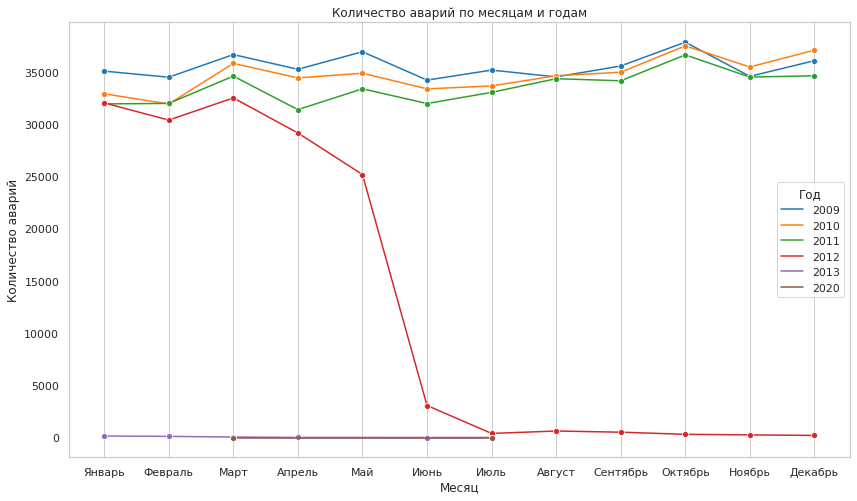

In [ ]:
# стиль
# "whitegrid" - добавляет белую сетку на фон графика
sns.set(style="whitegrid")

# цвета
# tab10 -  это предопределённая цветовая палитра в библиотеке Seaborn, которая содержит 10 различных цветов
palette = sns.color_palette("tab10", n_colors=df['year'].nunique())

# построение
plt.figure(figsize=(14, 8))
sns.lineplot(data=df, x='month', y='accident_count', hue='year', marker='o', palette=palette)

plt.xlabel('Месяц')
plt.ylabel('Количество аварий')
plt.title('Количество аварий по месяцам и годам')
plt.xticks(ticks=range(1, 13), labels=['Январь', 'Февраль', 'Март',
                                       'Апрель', 'Май', 'Июнь',
                                       'Июль', 'Август', 'Сентябрь',
                                       'Октябрь', 'Ноябрь', 'Декабрь'])
plt.legend(title='Год')
plt.grid(axis='y')

plt.show()

За некоторые года (с 2014 по 2019) данные отсутствуют полностью. Данные за 2013 и 2020 год неполные (и мы бы могли предположить, что выгрузка данных произошла в августе 2020 года, однако с учетом наличия 2021 года в столбце `'db_year'` таблицы `'case_ids'` это может не соответствовать действительности).

Поведение графиков для 2009, 2010 и 2011 графиков схоже, а само количество аварий - велико (хотя и снижалось немного из года в год).

В наиболее интересующем нас для дальнейшего исследования 2012 году произошел перелом - в начале года общая динамика напоминала предыдущие годы, хотя и также с характерным снижением, но с мая ситуация резко улучшилась, снизив количество аварий, а к июлю количество ДТП упало с характерных ранее десятков тысяч до менее тысячи в месяц. Причин тому может быть множество.

Например, со знаком `"-"` для компании-заказчика:
- у компании стало меньше автомобилей "выходить на линию" (что могло произойти с учетом того, сколько их было повреждено ранее);
- у компании стало меньше клиентов (например, ввиду плохой репутации, которую могло вызвать такое количество аварий или появления компании-конкурента);
- пропажа большой части данных за период с мая 2012 года.

Со знаком `"+"` для компании-заказчика:
- ужесточение условий допуска водителя к управлению;
- улучшение дорожной инфраструкуры;
- обновление автопарка на более новые и безопасные автомобили;
- ужесточение наказания за ДТП (как со стороны государства в лице, например, ГАИ, так и от самого каршеринга).

В любом случае, необходимо обратить внимание заказчика на данный момент и уточнить причины.

На данных графиках (в рамках годов с "однородным поведением", т.е. 2009-2011) мы можем наблюдать повышение уровней ДТП в марте, мае, июль (небольшое), октябре и декабре.

Данные тенденции можно объяснить межсезоньем в марте и октябре (когда водители привыкают к новым условиям), майскими праздниками (количество водителей с повыенным уровнем алкоголя в крови можжет стать больше) и грозами, ухудшающими погодные условия в мае же; снижением уровня активности и количества поездок в период с июня по сентябрь (когда идет сезон отпусков, и клиенты могут покидать город или страну, а также в принципе сидеть дома, редко из него выбираясь).

Посмотрим на общее количество аварий за весь период.

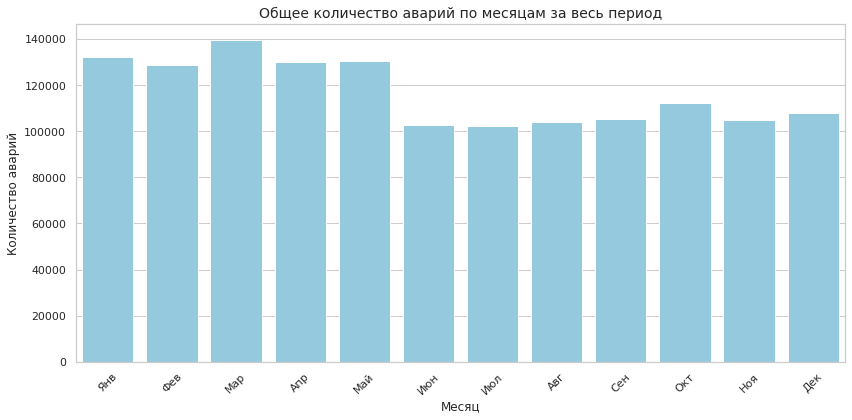

In [ ]:
# устанавливаем стиль графиков
sns.set(style="whitegrid")

# график общего количества аварий по месяцам
plt.figure(figsize=(12, 6))

# группируем по месяцам и суммируем аварии
monthly = df.groupby('month')['accident_count'].sum().reset_index()

# строим столбцовую диаграмму
sns.barplot(x='month', y='accident_count', data=monthly, color='skyblue')

# настройки графика
plt.title('Общее количество аварий по месяцам за весь период', fontsize=14)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Количество аварий', fontsize=12)
# range(12) - позиции меток (0-11 для 12 месяцев)
# rotation=45 - поворот подписей на 45 градусов для лучшей читаемости
plt.xticks(range(12), ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
                        'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'], rotation=45)
plt.tight_layout()
plt.show()

Более "опасный" период идет с января по май (с пиком в марте и минимумом в феврале), в остальное время количество ДТП заметно меньше (с максимумом в октябре и также увеличением в декабре). Что в целом не выглядит правдоподобно: пик в марте еще можно списать на межсезонье (однако ноябрь и декабрь при этом не демонстрируют такого роста, но возможно в климатических условиях заказчика оно приходится на октябрь, что могло бы объяснить пик аварий), но провал в феврале выглядит необычно, как и превосходящий его по количеству ДТП май с потенциально более благоприятными условиями (если, конечно, не виноваты майские грозы и майские же праздники).

Самыми же безопасными можно считать июнь и июль.

Но, как мы помним, данные за некоторые года у нас неполные, плюс резкий спад общего количества в 2012 году (как раз приходящийся на те месяцы, которые выглядят как более безопасные с точки зрения данного графика). Поэтому взглянем на среднее количество аварий по месяцам.

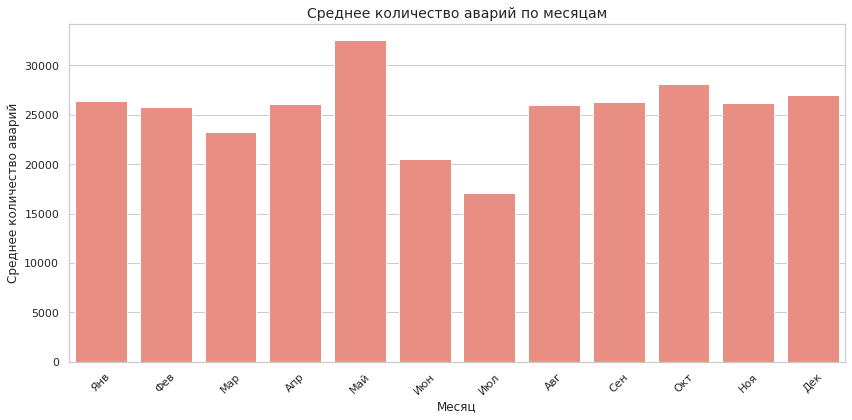

In [ ]:
# график среднего количества аварий по месяцам
plt.figure(figsize=(12, 6))

# группируем по месяцам и считаем среднее
monthly = df.groupby('month')['accident_count'].mean().reset_index()

# Строим столбцовую диаграмму
sns.barplot(x='month', y='accident_count', data=monthly, color='salmon')

# Настройки графика
plt.title('Среднее количество аварий по месяцам', fontsize=14)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Среднее количество аварий', fontsize=12)
plt.xticks(range(12), ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
                       'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'], rotation=45)
plt.tight_layout()
plt.show()

Теперь у нас нет такого яркого разделения на "опасную" и "безопасную" группу, как ранее.

Здесь март уже потерял лидерство, напротив став наиболее безопасным месяцем в своем "бывшем" периоде, а май стал в принципе лидером по уровню ДТП за весь период наблюдений (для объяснения данного феномена можно провести дополнительное исследование). Повышение уровня ДТП в октябре и декабре также сохранились.

Самым безопасным месяцем стал июль, чье среднее количество ДТП заметно меньше чем у его "собрата" по прошлому графику июня (у которого он также ниже, чем у остальных месяцев).

По итогу, при изучении обоих графиков самым опасным месяцем можно признать май, самым безопасным - июль. Однако, ввиду недостаточности данных и резкого изменения их поведения в 2012 году данные утверждения могут оказаться недостоверными,а потому может потребоваться дополнительное исследование после устранения проблем с данными, либо изучения данных только за конкретный период с "однородным поведением". В рамках дальнейшего исследования мы отдельно посмотрим на уровень ДТП по месяцам за 2012 год, когда будем отбирать пригодные для обучения модели признаки.

Также мы могли бы провести исследование по сезонам, но при этом помня, что из-за проблем в данных результаты могут быть недостоверны.

In [ ]:
# 1. Добавим столбец с сезонами

# создаем функцию для определения сезона
def get_season(month):
    if month in [12, 1, 2]:
        return 'Зима'
    elif month in [3, 4, 5]:
        return 'Весна'
    elif month in [6, 7, 8]:
        return 'Лето'
    else:
        return 'Осень'

# добавляем столбец с сезоном
df['season'] = df['month'].apply(get_season)

# упорядочим сезоны в логическом порядке
season_order = ['Зима', 'Весна', 'Лето', 'Осень']
df['season'] = pd.Categorical(df['season'], categories=season_order, ordered=True)

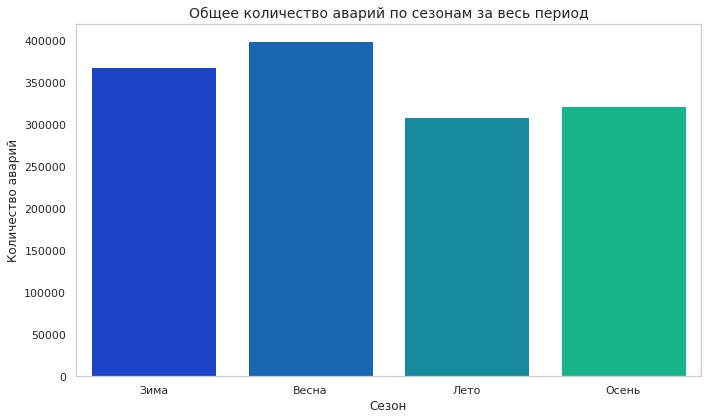

In [ ]:
# 2. График общего количества аварий по сезонам
plt.figure(figsize=(10, 6))

# группируем по сезонам и суммируем аварии
# строим столбчатую диаграмму
sns.barplot(x='season', y='accident_count', data=df.groupby('season')['accident_count'].sum().reset_index(), palette='winter')

plt.title('Общее количество аварий по сезонам за весь период', fontsize=14)
plt.xlabel('Сезон', fontsize=12)
plt.ylabel('Количество аварий', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

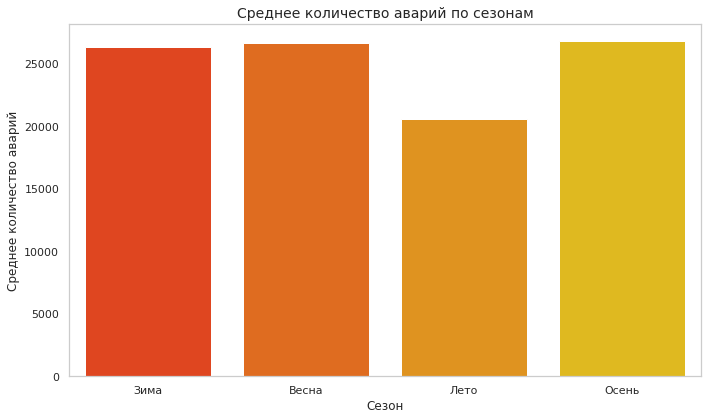

In [ ]:
# 3. График среднего количества аварий по сезонам
plt.figure(figsize=(10, 6))

# группируем по сезонам и считаем среднее
# строим столбчатую диаграмму
sns.barplot(x='season', y='accident_count', data=df.groupby('season')['accident_count'].mean().reset_index(), palette='autumn')

plt.title('Среднее количество аварий по сезонам', fontsize=14)
plt.xlabel('Сезон', fontsize=12)
plt.ylabel('Среднее количество аварий', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Согласно графику с общим количеством ДТП наиболее опасным времением является весна (возможно, ввиду высокого уровня аварийности мая), второе место занимает зима. У графика по среднему количеству ДТП весна и осень не отличаются по уровню ДТП, а зима лишь ненамного ниже по данному показателю. Но оба графика согласны, что самый безопасный период - лето.

**Выводы**

- Обнаружены проблемы в данных: нехватка данных за определенные периоды (например, за годы с 2014 по 2019 отсутствуют полностью, также их не хватает и в иные периоды), а также необычно резкое изменение их поведения с определенного периода (май 2012).
- С учетом сложности изучения подобных проблемных данных самым опасным месяцем можно считать май, самам безопасным - июль. Также лето в целом можно считать наиболее безопасным сезоном.
- Ввиду проблем в данных результаты данного раздела исследования могут оказаться недостоверными. Необходимо устранить проблемы и провести дополнительное исследование. Также после этого возможные причины определенных тенденций можно будет предположить либо установить более достоверно.

### Задачи для рабочей группы

Скоро состоится первое совещание нашей рабочей группы. Чтобы обсуждение было конструктивным, каждый сотрудник должен понимать данные. Для этого мы должны создать подходящие аналитические задачи (не менее шести) и поручить их решение коллегам.

Задачи:
1. Найти зависимость серьезности происшествий в зависимости от погоды (столбцы `'collision_damage'` и `'weather_1'` таблицы `'collisions'`).
2. Найти зависимость трезвости участника от месяца происшествия (столбцы `'party_sobriety'` таблицы `'parties'` и `'collision_date'` таблицы `'collisions'`).
3. Найти самые частые типы участников происшествия в зависимости от освещения (столбцы `'party_type'` таблицы `'parties'` и `'lighting'` таблицы `'collisions'`).
4. Найти зависимость серьезности происшествия от категорий нарушения (столбцы `'collision_damage'` и `'pcf_violation_category'` таблицы `'collisions'`).
5. Найти зависимость виновности участника от состояния дороги (столбцы `'road_surface'` из таблицы `'collisions'` и `'at_fault'` из таблицы `'parties'`).
6. Найти зависимость серьезности происшествий от возраста автомобиля (столбцы `'collision_damage'` из таблицы `'collisions'` и `'vehicle_age'` из таблицы `'vehicles'`).

Теперь мы должны прописать порядок решения для двух из них (с обязательным условием - их решение должно включать в себя связь не менее 2-х таблиц) и реализовать его.

#### Зависимость виновности участника от состояния дороги

Как мы помним, в таблице `'collisions'`у нас было два столбца, характеризующие состояние дороги `'road_surface'` и дорожное состояние `'road_condition_1'`.

Здесь нас интересуют столбцы `'road_surface'` из таблицы `'collisions'` и `'at_fault'` из таблицы `'parties'`. Для лучшей интерпритируемости (оценки) посчитаем не только те происшествия, где виноват участник, но и те, где он не виноват.

Так как в одно происшествие могут попасть несколько участников (т.е., одному `'case_id'` может быть сопоставлено несколько `'id'` из таблицы `'parties'`) мы не можем применять только уникальные значения `'case_id'` для соединения таблиц, и необходимо учесть данную особенность при присоединении.

In [ ]:
# создадим sql-запрос
# COALESCE заменяет NULL на "no info"
query = '''
    SELECT
        COALESCE(road_surface, 'no info') AS road_surface,
        COUNT(CASE WHEN p.at_fault = 1 THEN p.case_id END) AS count_guilty,
        COUNT(CASE WHEN p.at_fault = 0 THEN p.case_id END) AS count_not_guilty
    FROM collisions AS c
    JOIN parties AS p ON c.case_id = p.case_id
    GROUP BY c.road_surface
    ORDER BY count_guilty DESC;
    '''
df = pd.read_sql(query, engine)
df

,road_surface,count_guilty,count_not_guilty
0,dry,1142414,1325625
1,wet,127941,117368
2,no info,10055,15732
3,snowy,6717,4323
4,slippery,1000,1233


Мы можем наблюдать, что больше всего аварий, где участник является виновником, происходит на сухой дороге (но на ней в принципе происходит больше всего аварий, так как и для невиновных данное состояние - самое большое). Аналогичная ситуация и для влажной дороги (которая занимает второе место в данном показателе, хотя и с гораздо меньшими значениями).

Также мы видим, что участники чаще не являются виновниками, чем являются.

Мы уже можем предположить, что состояние дороги не влияет на то, станет участник виновником или нет. Но построим графики для наглядности.

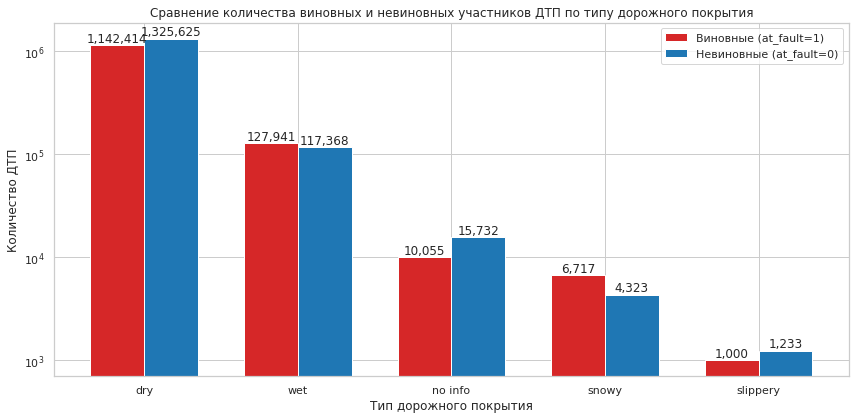

In [ ]:
# строим график для сопостовления количеств
# создаем график
plt.figure(figsize=(12, 6))

# позиции для столбцов
x = range(len(df['road_surface']))
width = 0.35  # ширина столбцов

# столбцы для виновных (at_fault = 1) и невиновных (at_fault = 0)
bars1 = plt.bar(x, df['count_guilty'], width, label='Виновные (at_fault=1)', color='#d62728')
bars2 = plt.bar([p + width for p in x], df['count_not_guilty'], width, label='Невиновные (at_fault=0)', color='#1f77b4')

# настройки графика
plt.xlabel('Тип дорожного покрытия')
plt.ylabel('Количество ДТП')
plt.title('Сравнение количества виновных и невиновных участников ДТП по типу дорожного покрытия')
plt.xticks([p + width/2 for p in x], df['road_surface'])
plt.legend()

# добавляем подписи значений
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height):,}',
                 ha='center', va='bottom')

plt.tight_layout()
plt.yscale('log')  # добавляем эту строку перед plt.show(), так как у нас очень большой разброс данных
plt.show()

Случаев, когда участник виновен, в целом несколько больше, чем когда он невиновен. Но отличия по состоянию дороги заметны лишь для категории с неизвестным состоянием дороги (где участник чаще невиновен, чем виновен).

Попробуем сопоставить процентное соотношение ДТП для разных состояний дороги.

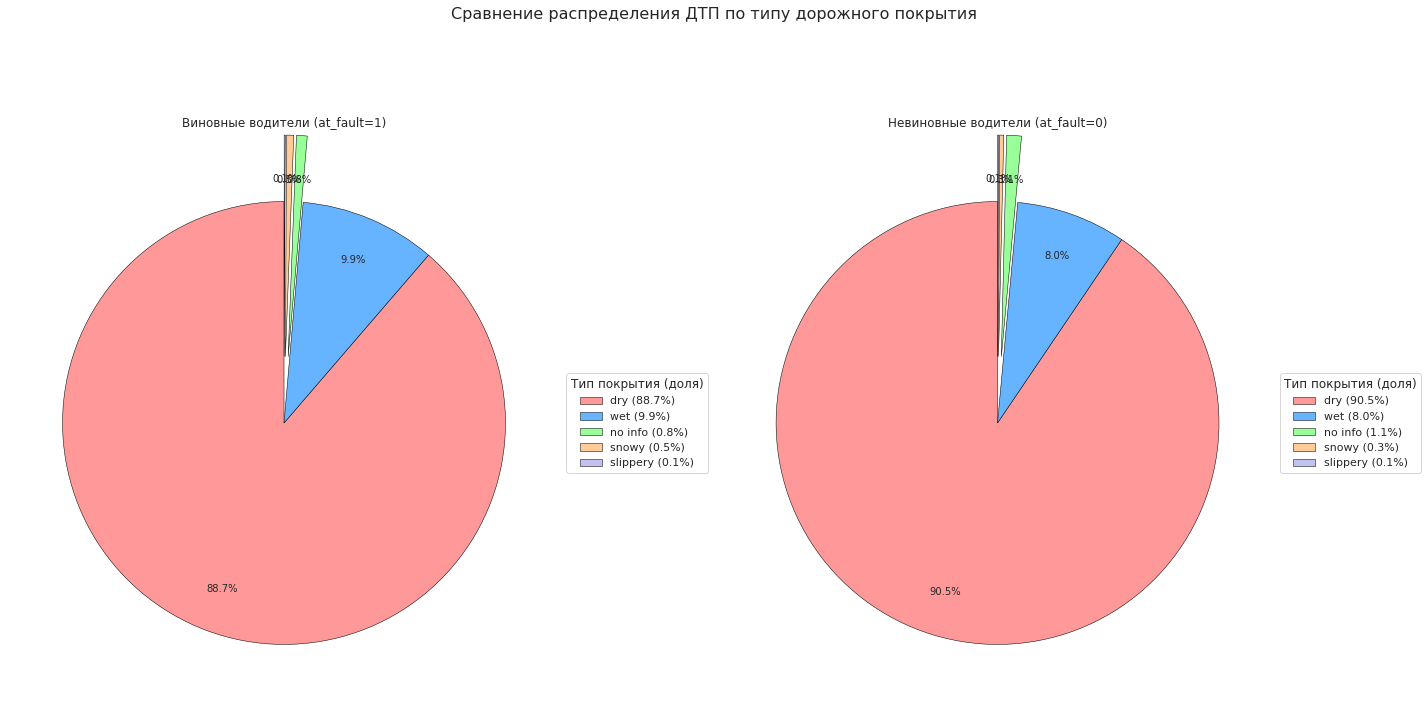

In [ ]:
# строим круговую диаграмму
# совмещенная версия (два графика рядом)
# с вынесением маленьких секторов и легендой
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# настройки вынесения и стиля
explode_factor = 0.3 # вынесение
threshold = 0.05 # определяем, какие доли считать маленькими (менее 5%)

# функция для создания подписей в легенде (категория + процент)
def make_legend_labels(values, labels):
    total = sum(values)
    return [f'{label} ({val/total:.1%})' for label, val in zip(labels, values)]

# --- график для виновных ---
explode_guilty = [explode_factor if (val/sum(df['count_guilty'])) < threshold else 0
                 for val in df['count_guilty']]
wedges1, texts1, autotexts1 = ax1.pie(
    df['count_guilty'],
    startangle=90, # начало отсчета (12 часов)
    explode=explode_guilty, # сильнее вынесенные доли
    colors=['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0'], # цвета
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.5}, # границы секторов
    pctdistance=0.8, # расстояние от центра пирога, на котором будут отображаться проценты
    textprops={'fontsize': 10}, # уменьшаем шрифт, если проценты перекрываются
    autopct='%1.1f%%'  # добавлено для отображения процентов
)

# легенда для виновных
ax1.legend(
    wedges1,
    make_legend_labels(df['count_guilty'], df['road_surface']),
    title="Тип покрытия (доля)",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)
ax1.set_title('Виновные водители (at_fault=1)', pad=20)

# --- график для невиновных ---
explode_not_guilty = [explode_factor if (val/sum(df['count_not_guilty'])) < threshold else 0
                     for val in df['count_not_guilty']]
wedges2, texts2, autotexts2 = ax2.pie(
    df['count_not_guilty'],
    startangle=90,
    explode=explode_not_guilty,
    colors=['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0'],
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.5},
    pctdistance=0.8,
    textprops={'fontsize': 10},
    autopct='%1.1f%%'  # добавлено для отображения процентов
)

# легенда для невиновных
ax2.legend(
    wedges2,
    make_legend_labels(df['count_not_guilty'], df['road_surface']),
    title="Тип покрытия (доля)",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)
ax2.set_title('Невиновные водители (at_fault=0)', pad=20)

plt.suptitle('Сравнение распределения ДТП по типу дорожного покрытия', y=1.05, fontsize=16)
plt.tight_layout()
plt.show()

Как мы можем наблюдать, в процентном соотношении, шанс стать виновником для участников для сухой или с неизвестным состоянием дороги несколько ниже, для скользкой - одинаков, для влажной и снежной выше. Но в целом поведение этих двух групп (виновные и невиновные) схожи для разных состояний, плюс мы помним о проблемах в данных. Поэтому нельзя однозначно утверждать, что данные наблюдения верны в реальности.

Но при этом мы можем с большой долей уверенности утверждать, что наибольшее количество аварий приходится на сухую дорогу. Возможно, сухая дорога характерна для более хорошей погоды, что может способствовать увеличенному спросу на услуги каршеринга и повышенной активности на дорогах в целом (в плохую погоду люди будут склонны перенести дела на более благоприятное время либо воспользоваться услугами такси).

#### Зависимость серьезности происшествий от возраста автомобиля

Здесь нас интересуют столбцы `'collision_damage'` из таблицы `'collisions'` и `'vehicle_age'` из таблицы `'vehicles'`. Здесь также одному происшествию из таблицы `'collisions'` может соответствовать несколько строк из таблицы `'vehicle_age'`.

Также мы помним, что не для всех ДТП была информация об участвовавших в них аавтомобилях, а потому статистика будет неполной (появится группа с неитзвестным возрастом, которая, однако, может дополнить общую картину характерных повреждений).

In [ ]:
# создадим sql-запрос
# предварительно необходимо уточнение значений для формирования кейсов
query = '''
    SELECT v.vehicle_age AS age,
        COUNT(CASE WHEN c.collision_damage = 'fatal' THEN c.case_id END) AS fatal,
        COUNT(CASE WHEN c.collision_damage = 'severe damage' THEN c.case_id END) AS severe_damage,
        COUNT(CASE WHEN c.collision_damage = 'middle damage' THEN c.case_id END) AS middle_damage,
        COUNT(CASE WHEN c.collision_damage = 'small damage' THEN c.case_id END) AS small_damage,
        COUNT(CASE WHEN c.collision_damage = 'scratch' THEN c.case_id END) AS scratch
    FROM collisions AS c
    FULL JOIN vehicles AS v ON c.case_id = v.case_id
    GROUP BY vehicle_age
    ORDER BY age;
    '''
df = pd.read_sql(query, engine)
df

,age,fatal,severe_damage,middle_damage,small_damage,scratch
0,0.00,229,812,5951,22632,10638
1,1.00,241,1134,7658,18938,13336
2,2.00,814,3591,22878,42335,36912
3,3.00,2478,7413,43477,52029,73153
4,4.00,1871,5324,29136,32163,56978
5,5.00,1502,4416,22896,24205,52016
6,6.00,1283,3681,18006,17434,43958
7,7.00,1392,3760,17853,16314,44963
8,8.00,1456,3608,16166,14097,41743
9,9.00,1192,2681,12503,10733,31146


Мы можем заметить, что есть аномальные значения возрастов - 161 год, и таких автомобилей минимум 17. Также для многих автомобилей возраст не известен (о чем мы могли предугадать заранее). Но в целом мы можем сделать вывод, что вероятнее всего каршеринг не использует автомобили старше 20 лет, а также что фатальные повреждения случаются реже остальных, а лидерами в большинстве случаев явлются царапины (иногда пальму первенства в них перехватывают небольшие повреждения). Причем чем старше автомобиль, тем реже встречаются серьезные повреждения (но это может быть связано с в приниципе малым количеством данных автомобилей).

Однако таблица - это хорошо. Но график - лучше и нагляднее. Построим его так, чтобы можно было отследить динамику по возрасту в процентах.

<Figure size 1008x576 with 0 Axes>

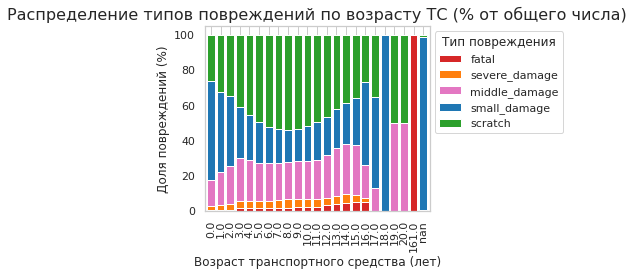

In [ ]:
# Нормализуем данные (переводим в проценты от общего количества по каждой возрастной группе)
df_norm = df.set_index('age')  # устанавливаем возраст как индекс
df_norm = df_norm.div(df_norm.sum(axis=1), axis=0) * 100  # переводим в проценты

# Задаем цвета для каждого типа повреждений
colors = ['#d62728', '#ff7f0e', '#e377c2', '#1f77b4', '#2ca02c']

# строим график
# столбчатая диаграмма с накоплением (stacked bar chart)
plt.figure(figsize=(14, 8)) # задаёт размер фигуры графика в дюймах (ширина, высота)

df_norm.plot(kind='bar', #  указывает, что нужно построить столбчатую диаграмму
             # говорит о том, что столбцы должны быть накоплены друг на друга,
             # то есть каждый следующий столбец строится на предыдущем
             stacked=True,
             # задаёт цвета для каждой категории в диаграмме. переменная colors должна содержать список цветов
             color=colors,
             width=0.8) # устанавливает ширину столбцов на графике
# устанавливаем заголовок и шрифт
plt.title('Распределение типов повреждений по возрасту ТС (% от общего числа)', fontsize=16)
plt.xlabel('Возраст транспортного средства (лет)') # метка для оси X
plt.ylabel('Доля повреждений (%)') # метка для оси Y
# добавляем легенду с указанным заголовком и размещаем её в правом верхнем углу графика
plt.legend(title='Тип повреждения', bbox_to_anchor=(1, 1))
# добавляем сетку по оси Y с пунктирным стилем и прозрачностью 0.4
plt.grid(axis='y', linestyle='--', alpha=0.4)
# автоматически настраиваем расположение элементов графика, чтобы они не перекрывались и лучше вписывались в фигуру
plt.tight_layout()

plt.show();

Можно наблюдать тенденцию, что чем старше автомобиль, тем чаще у него встречаются повреждения более серьезных степеней (доля фатальных и серьезной степени растет). Доля повреждений средней степени растет с 0 до 3 лет, потом сохраняется приблизительно на одном уровне. Доля повреждений небольшой степени с 0 до 8 лет сокращается, уступая свою долю царапинам, а затем, начиная с 9 лет баланс между царапинами и повреждениями малой степени начинает смещаться в пользу повреждений малой степени.

Для автомобилей 18 лет и старше данных мало, что может быть обусловленно малым их количеством в автопарке.

В целом более легкие повреждения (царапины и повреждения малой степени) встречаются чаще, чем остальные, самые редкие из всех - фатальные.

**Выводы**

- Поставлены задачи для рабочей группы и выполнены две из них.
- При исследовании зависимости участника от состояния дороги замечено что:
    * по большому количеству происшествий нет данных о состоянии дороги.
    * в процентном соотношении, шанс стать виновником для участников для сухой или с неизвестным состоянием дороги несколько ниже, для скользкой - одинаков, для влажной и снежной выше. Но в целом поведение этих двух групп (виновные и невиновные) схожи для разных состояний. Возможно, это вызвано тем, что какие-либо условия в принципе способствуют повышению шанса ДТП.
    * наибольшее количество аварий приходится на сухую дорогу.
- При исследовании серьезности происшествия от возраста автомобиля замечено, что:
    * встречаются аномальный возраст в 161 год и неизвестный возраст автомобиля.
    * в данных мало автомобилей 18 лет и старше.
    * чем старше автомобиль, тем чаще у него встречаются повреждения более серьезных степеней (однако среди автомобилей 18 лет старше серьезные и иные повреждения не встречаются, что может быть обусловлено малым количеством таких автомобилей).
    * в целом более легкие повреждения (царапины и повреждения малой степени) встречаются чаще, чем остальные.
    * самые редкие из всех видов повреждений - фатальные.
- С учетом выявленных проблем в данных нельзя однозначно утверждать, что полученные наблюдения верны в реальности.

**Вывод**

Проведен статистический анализ факторов ДТП, в результате которого выявлены проблемы в данных (которые могут мешать правильному анализу), а также некоторые закономерности, оформленные в выводах соответсвующих подразделов.

## Создайние модели для оценки водительского риска

### Первичная подготовка данных

#### Загрузка датасета

Для работы нам нужно выгрузить набор данных, подходящий под требования заказчика:

- тип виновника - car;
- степень повреждений ТС - все кроме scratch;
- дата столкновения - 2012 год.

Для начала выведем первые 10 строк объединенной целиком таблицы, чтобы посмотреть, с чем мы можем работать в будущем.

In [ ]:
# составляем sql-запрос
# используем LIMIT 20 чтобы не грузить лишнее
# FULL - для дополнительного общего ознакомления
query = '''
SELECT *
  FROM parties AS p
       FULL JOIN vehicles AS v ON p.case_id = v.case_id AND p.party_number = v.party_number
       FULL JOIN collisions AS c ON p.case_id = c.case_id
 WHERE p.party_type = 'car'
       AND c.collision_damage != 'scratch'
       AND c.collision_date BETWEEN '2012-01-01' AND '2012-12-31'
 LIMIT 20;
'''
df = pd.read_sql_query(query, con=engine)
df

,id,case_id,party_number,party_type,at_fault,insurance_premium,party_sobriety,party_drug_physical,cellphone_in_use,id,case_id,party_number,vehicle_type,vehicle_transmission,vehicle_age,case_id,county_city_location,county_location,distance,direction,intersection,weather_1,location_type,collision_damage,party_count,primary_collision_factor,pcf_violation_category,type_of_collision,motor_vehicle_involved_with,road_surface,road_condition_1,lighting,control_device,collision_date,collision_time
0,2685660,5615920,4,car,0,NaN,impairment unknown,G,0.00,NaN,None,NaN,None,None,NaN,5615920,1900,los angeles,128.00,north,0,clear,highway,small damage,4,vehicle code violation,speeding,rear end,other motor vehicle,dry,normal,daylight,none,2012-04-20,14:20:00
1,2461328,5484415,1,car,1,24.00,None,None,NaN,NaN,None,NaN,None,None,NaN,5484415,1941,los angeles,0.00,None,1,clear,None,small damage,2,vehicle code violation,automobile right of way,None,None,dry,normal,daylight,None,2012-01-06,08:45:00
2,2466638,5487179,1,car,1,NaN,impairment unknown,G,NaN,NaN,None,NaN,None,None,NaN,5487179,1942,los angeles,5.00,north,0,clear,None,small damage,2,vehicle code violation,speeding,rear end,other motor vehicle,dry,normal,dark with street lights,none,2012-01-21,20:45:00
3,2491017,5500254,1,car,1,40.00,"had been drinking, under influence",None,1.00,NaN,None,NaN,None,None,NaN,5500254,1942,los angeles,60.00,south,0,clear,None,small damage,3,vehicle code violation,dui,head-on,parked motor vehicle,dry,normal,dark with street lights,functioning,2012-02-06,02:15:00
4,2497457,5503632,1,car,1,72.00,had not been drinking,None,0.00,NaN,None,NaN,None,None,NaN,5503632,1976,los angeles,900.00,south,0,clear,highway,small damage,2,vehicle code violation,speeding,rear end,other motor vehicle,dry,normal,daylight,none,2012-01-20,15:10:00
5,2543680,5528723,1,car,1,NaN,None,None,NaN,NaN,None,NaN,None,None,NaN,5528723,1942,los angeles,270.00,east,0,clear,None,small damage,2,vehicle code violation,unsafe starting or backing,sideswipe,other motor vehicle,dry,normal,daylight,none,2012-02-24,10:20:00
6,2544029,5528909,1,car,1,17.00,had not been drinking,None,NaN,NaN,None,NaN,None,None,NaN,5528909,4214,santa barbara,0.00,None,1,clear,None,small damage,2,vehicle code violation,automobile right of way,sideswipe,other motor vehicle,dry,normal,dark with street lights,functioning,2012-02-28,20:20:00
7,2545324,5529600,1,car,1,53.00,had not been drinking,None,0.00,NaN,None,NaN,None,None,NaN,5529600,3025,orange,561.00,west,0,clear,None,small damage,1,vehicle code violation,speeding,hit object,fixed object,dry,normal,dark with street lights,none,2012-02-23,00:27:00
8,2546047,5529997,1,car,1,21.00,had not been drinking,None,0.00,"1,401,827.00",5529997,1.00,sedan,auto,2.00,5529997,3017,orange,460.00,north,0,raining,highway,small damage,1,vehicle code violation,improper turning,hit object,fixed object,wet,normal,daylight,none,2012-02-27,17:00:00
9,2546538,5530241,1,car,0,31.00,had not been drinking,None,NaN,NaN,None,NaN,None,None,NaN,5530241,1905,los angeles,50.00,north,0,clear,None,small damage,2,unknown,unknown,broadside,other motor vehicle,dry,normal,daylight,none,2012-02-29,13:51:00


Тут мы тоже можем понаблюдать проблемы в данных,  в том числе на примере ДТП с `'case_id'` равном 5474571, по которому представлено несколько участников (с номерами 4 и 6), информация об одном из них (одном из автомобилей, с номером 4) присутствует, а для другого - нет.

Также, прежде чем выгружать остальную для работы, попробуем проанализировать, какие признаки могут нам пригодиться (чтобы избежать лишних загрузок). Отбирать будем те, которые влияют на возможность возникновения аварии.

| имя столбца | краткое описание | возможное влияние | вердикт |
|-------------|-------------|-------------|-------------|
| id   | уникальный номер    | не влияет    |  удалить    |
| case_id     | номер случая    | не влияет    | удалить    |
| party_number    | номер участника    | не влияет    |  удалить    |
| party_type    | тип участника    | брали только машины, не влияет    | удалить	    |
| at_fault    | виновность    | целевой признак   |  оставить    |
| insurance_premium    | страховая премия    | хотя страховые компании при вычислении данной суммы и учитывают факторы риска ДТП, прямое влияние на виновность маловероятно (лишь косвенное)    | удалить    |
| party_sobriety    | трезвость    | влияет (изменяет внимательности и скорость реакции), *однако согласно информации заказчиика, данный показатель перед поездкой не измеряется и потому не может быть использован в модели. Однако, он может косвенно влият на другие (например, на дни недели)*   |  *провести EDA (для дополнения портрета виновника), затем удалить* <s>оставить</s>    |
| party_drug_physical     | состояние участника    | влияет, но может меняться в процессе, к тому же проблематично установить заранее  |  удалить     |
| cellphone_in_use   | наличие возможности разговора по громкой связи    | может влиять (наличие может снижать риск ДТП)    |  оставить    |
| vehicle_type    | тип кузова    | может влиять    | оставить    |
| vehicle_transmission    | тип трансмиссии    | может влиять на управляемость   | оставить    |
| vehicle_age     | возраст авто    | влияет    |  оставить    |
| county_location    | регион (имя)   | может влиять на шанс ДТП, проще интерпретируется, чем county_city_location   | ставить одно из двух    |
| county_city_location    | регион (номер)    | дублирует county_location, но хуже для восприятия (хоть и лучше с точки зрения наличия предварительной кодировки)   |  оставить одно из двух    |
| distance    | расстояние до главной дороги    | косвенно может, но заранее неизвестно    | удалить    |
| direction    | направление по сторонам света    | может косвенно (в определенное врямя суток), однако оно меняется в процессе поездки, плюс могут быть "гибридные варианты" (вроде "юго-запад", которых тут нет)   |  удалить  |
| intersection    | перекрёсток ли    | наличие на маршруте и их количество может влиять на шанс ДТП, на перекрестке больше автомобилей, но влияние на вину может быть косвенное, в зависимости, например, от характера перекрестка и направления движения; к тому же мы не знаем заранее, где произойдет ДТП - до подъезда к перекрестку, на нем, за ним   | удалить    |
| weather_1    | погода    | может влиять на шанс ДТП  (влияет на видимость, сцепление с дорогой)  |  оставить    |
| location_type    | тип дороги  ("какая ее функциональная часть")  | может влиять на шанс ДТП, однако, так как данный параметр не характеризует тип, как автомагистраль или придворовую территорию (разный скоростной режим, разные факторы риска- например, на автомагистрали больше двигающихся с большой скоростью автомобилей и меньше препятствий, во дворе - скорость движения ниже, но стоит учитывать бегающих детей и стоящие автомобилей, часто приводящих к сущению и без того узкой дороги), а как функциональную часть, мы не можем значть заранее, в какой ее части произойдет ДТП   |   удалить    |
| collision_damage    | урон    | заранее неизвестен    |  удалить    |
| party_count    | количество участников   | может быть связан, но заранее неизвестен    | удалить     |
| pcf_violation_category    | категория нарушения    | может быть связан, но заранее неизвестен    | удалить    |
| primary_collision_factor     | главный фактор ДТП    | может быть связан, но заранее неизвестен    |  удалить    |
| type_of_collision    | тип столкновения    | может быть связан, но заранее неизвестен    |  удалить    |
| motor_vehicle_involved_with    | дополнительные участники ДТП    | может косвенно влиять (на некоторых маршрутах больше пешеходных переходов), но заранее неизвестен    | удалить    |
| road_surface    | состояние дороги ("погодное")   | может влиять    | оставить    |
| road_condition_1     | дорожное состояние ("качественно-ремонтное")  | может влиять (может приводить ухудшению передвижения)   | оставить    |
| lighting    | освещенность    | может влиять (влияет на видимость)   | оставить    |
| control_device    | устройство управление    | может влиять  его наличие может облегчать управление и водитель будет меньше отвлекаться  | оставить    |
| collision_date    | дата ДТП    | может влиять на шанс ДТП также месяц может оказывать влияние на погодные условия, а день недели - на состояние участников ДТП, что может влиять как на шанс аварии, так и на вероятность виновности  |  оставить, но сократить до месяца (один признак), и до дня недели (второй признак)   |
| collision_time    | время ДТП    | нахождение в пути в опредленное время может влиять на шанс ДТП, но мы знаем заранее только время посадки  | оставить оставить, но разбить на периоды|

Также мы можем предположить, что когда сталкивались несколько автомобилей, один из которых был виновником, а другой - нет, основная часть условий (погода, освещенность, состояние дороги, время суток и т.д) у них совпадало. Но могло отличаться направление движения, участники (например, состояние водителя) и характеристики автомобилей-участников. А наличие более двух автомобилей-участников в общем картине повышает риск попадания в аварию в данных условия и снижает риск стать участником ДТП, что может искажать картину.

Мы не можем знать заранее время ДТП, но время посадки и время ДТП скорее всего будут относиться к одному и тому же времени суток (утро, день, вечер, ночь), так как каршэринг редко берут на большой период времени (долгие и длинные поездки).

Однако не все, что влияет на шансы попасть в ДТП, может влиять на шансы стать виновником. И не все факторы мы можем знать заранее, до начала поездки или до наступления ДТП. Например, `'party_sobriety'` (трезвость) согласно информации заказчика, перед поездкой не измеряется и потому не может быть использован в модели. Однако, данный признак может косвенно влиять на другие (например, быть связан с днями дни недели), поэтому в модель включить мы не сможем, но провести дополнительное EDA еще и по этому признаку может быть полезным.

Возможно, от части показателей можно будут избавиться после дополнительного исследования (ведь мы уже могли наблюдать на примере полных данных, что состояние дороги `'road_surface'` не слишком сказывается на виновности или невиновности участника в рамках всех данных).

Хотя по условиям заказчика мы выбрали только тип участников `'car'`, второй стороной-участницей ДТП может быть не только автомобиль (фильтрации по данному условию в требованиях заказчика не было), поэтому пока сохраним отобранные выше столбцы.

Помня о том, что не для всех автомобилей есть данные, то, чтобы не вносить в них искажения при заполнении пропусков (которых, вспоминая предварительный анализ, у нас будет очень много), а работать с максимально полными данными, будем использовать метод INNER JOIN (использующися по-умолчанию), вместо FULL JOIN (что добавит строк с пропусками в некоторых столбцах на три четверти датасета).

In [ ]:
# составляем sql-запрос по результатам анализа
# устанавливаем понедельник первым днем, воскресенье становится седьмым
query = '''

SELECT p.at_fault,
    p.party_sobriety,
    p.cellphone_in_use,
    v.vehicle_type,
    v.vehicle_transmission,
    v.vehicle_age,
    c.county_location,
    c.county_city_location,
    c.weather_1 AS weather,
    c.road_surface,
    c.road_condition_1 AS road_condition,
    c.lighting,
    c.control_device,
    EXTRACT(MONTH FROM c.collision_date) AS month,
    EXTRACT(ISODOW FROM c.collision_date) AS day_of_week,
    CASE
        WHEN EXTRACT(HOUR FROM c.collision_time) BETWEEN 6 AND 11 THEN 'morning'
        WHEN EXTRACT(HOUR FROM c.collision_time) BETWEEN 12 AND 17 THEN 'day'
        WHEN EXTRACT(HOUR FROM c.collision_time) BETWEEN 18 AND 22 THEN 'evening'
        ELSE 'night'
        END AS time_of_day
    FROM parties AS p
           JOIN vehicles AS v ON p.case_id = v.case_id AND p.party_number = v.party_number
           JOIN collisions AS c ON p.case_id = c.case_id
     WHERE p.party_type = 'car'
           AND c.collision_damage != 'scratch'
           AND c.collision_date BETWEEN '2012-01-01' AND '2012-12-31'

'''
# сохраняем в датафрейм
dtp = pd.read_sql_query(query, con=engine)
dtp.head() # смотрим первые строки

,at_fault,party_sobriety,cellphone_in_use,vehicle_type,vehicle_transmission,vehicle_age,county_location,county_city_location,weather,road_surface,road_condition,lighting,control_device,month,day_of_week,time_of_day
0,1,impairment unknown,0.00,sedan,manual,3.00,san diego,3711,clear,dry,normal,dark with street lights,none,1.00,5.00,night
1,0,had not been drinking,0.00,sedan,manual,1.00,humboldt,1200,clear,dry,normal,daylight,none,1.00,6.00,day
2,0,had not been drinking,0.00,sedan,manual,7.00,los angeles,1900,clear,dry,normal,daylight,none,1.00,4.00,day
3,0,had not been drinking,0.00,sedan,auto,4.00,los angeles,1942,raining,wet,normal,daylight,none,4.00,5.00,evening
4,1,"had been drinking, impairment unknown",0.00,sedan,manual,2.00,los angeles,1941,cloudy,dry,normal,dark with street lights,none,5.00,4.00,night


Загрузка прошла успешно. Можно провести предварительное ознакомление с данными.

In [ ]:
# функция для краткого обзора и описания
def first_discr(data, titl):

  print(color.BLUE + color.BOLD + f"\n === Размер датасета {titl} данных:===\n" + color.END + f"    {data.shape}\n")

  print(color.BLUE + color.BOLD + f"\n === Общая информация о {titl} данных: ===\n" + color.END)
  data.info()

  return

In [ ]:
# Вызов функции discr_num и ее вывод
first_discr(dtp,'отобранных')


 === Размер датасета отобранных данных:===
    (56248, 16)


 === Общая информация о отобранных данных: ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56248 entries, 0 to 56247
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   at_fault              56248 non-null  int64  
 1   party_sobriety        55376 non-null  object 
 2   cellphone_in_use      51777 non-null  float64
 3   vehicle_type          56248 non-null  object 
 4   vehicle_transmission  55389 non-null  object 
 5   vehicle_age           54554 non-null  float64
 6   county_location       56248 non-null  object 
 7   county_city_location  56248 non-null  object 
 8   weather               56080 non-null  object 
 9   road_surface          55900 non-null  object 
 10  road_condition        55999 non-null  object 
 11  lighting              56094 non-null  object 
 12  control_device        56033 non-null  object 
 13  month      

Типы данных не везде соответствуют содержимому. Также в данных имеются пропуски, с которыми потом будет необходимо работать.

Также взглянем на баланс классов.

In [ ]:
# считаем виновников
len(dtp.query('at_fault == 1'))

28373

In [ ]:
# считаем невиновных
len(dtp.query('at_fault == 0'))

27875

Виновных и невиновных у нас достаточно близкое количество, что хорошо для будущей работы с моделью.

И посмотрим сразу же на количество уникальных значений для столбцов с географическими районами, чтобы сразу избавиться от лишнего.

К тому же, мы сразу могли наблюдать, что одному значению "los angeles" в столбце `'county_location'` соотвествовало нескольео номеров (1900, 1942 и 1953) в столбце `'county_city_location'`, что предварительно может значить, что `'county_location'` более крупная единица, чем `'county_city_location'`.

In [ ]:
# считаем
len(dtp['county_location'].unique())

58

In [ ]:
# считаем
len(dtp['county_city_location'].unique())

496

Да, так и есть. А значит мы можем безболезненно удалить столбец `'county_city_location'`, а для `'county_location'` в будущем придумать варианты укрупнения.

In [ ]:
# удалим столбец
dtp = dtp.drop('county_city_location', axis =1)
dtp.columns # проверка

Index(['at_fault', 'party_sobriety', 'cellphone_in_use', 'vehicle_type',
       'vehicle_transmission', 'vehicle_age', 'county_location', 'weather',
       'road_surface', 'road_condition', 'lighting', 'control_device', 'month',
       'day_of_week', 'time_of_day'],
      dtype='object')

**Выводы**

- Предварительные признаки отобраны с обоснованием.
- Загружены подходящие под требования заказчика данные с учетом отобранных ранее признаковю
- Удален один из взаимодублирующих признаков (более проблемный).
- Проведено предварительное изучение, которое установило:
    * типы данных не везде соответствуют содержимому;
    * в данных имеются пропуски;
    * количество виновников ДТП в датасете близко к таковому для невиновных.

#### Типы данных

Теперь посмотрим, можно ли исправить типы данных.

In [ ]:
# вспомним типы данных
dtp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56248 entries, 0 to 56247
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   at_fault              56248 non-null  int64  
 1   party_sobriety        55376 non-null  object 
 2   cellphone_in_use      51777 non-null  float64
 3   vehicle_type          56248 non-null  object 
 4   vehicle_transmission  55389 non-null  object 
 5   vehicle_age           54554 non-null  float64
 6   county_location       56248 non-null  object 
 7   weather               56080 non-null  object 
 8   road_surface          55900 non-null  object 
 9   road_condition        55999 non-null  object 
 10  lighting              56094 non-null  object 
 11  control_device        56033 non-null  object 
 12  month                 56248 non-null  float64
 13  day_of_week           56248 non-null  float64
 14  time_of_day           56248 non-null  object 
dtypes: float64(4), int6

Теоретически, столбцам `'at_fault'` и `'cellphone_in_use'` можно задать булев тип. Также столбец `'cellphone_in_use'` можно было бы привести к типу int, но ввиду пропусков (а NAN имеют тип float), это проблематично, поэтому не будем его трогать. А столбец `'at_fault'` все равно может кодироваться перед обучением, поэтому дополнительное изменение типа не имеет острой необходимости.

Столбцу `'vehicle_age'`больше подошел бы тип int, но ввиду пропусков исправление также проблематично. Оставим, как есть.

А вот столбцы `'month'` и `'day_of_week'` пропусков не имеют, и их можно привести в тип int. Сделаем это.

In [ ]:
# меняем тип
dtp[['month', 'day_of_week']] = dtp[['month', 'day_of_week']].apply(lambda x: x.astype(int))

In [ ]:
# проверяем
dtp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56248 entries, 0 to 56247
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   at_fault              56248 non-null  int64  
 1   party_sobriety        55376 non-null  object 
 2   cellphone_in_use      51777 non-null  float64
 3   vehicle_type          56248 non-null  object 
 4   vehicle_transmission  55389 non-null  object 
 5   vehicle_age           54554 non-null  float64
 6   county_location       56248 non-null  object 
 7   weather               56080 non-null  object 
 8   road_surface          55900 non-null  object 
 9   road_condition        55999 non-null  object 
 10  lighting              56094 non-null  object 
 11  control_device        56033 non-null  object 
 12  month                 56248 non-null  int64  
 13  day_of_week           56248 non-null  int64  
 14  time_of_day           56248 non-null  object 
dtypes: float64(2), int6

**Выводы**

Мы проанализировали возможность изменения типов данных и применили преобразование, где это было необходимо и возможно.

#### Пропуски и предварительный анализ

Как мы помним, у нас были пропуски. Посмотрим на них внимательнее.

In [ ]:
# функция для изучения пропусков
def pass_miss(data, titl):

  #print(color.BLUE + color.BOLD + f"\n === Общая информация о {titl} данных: ===\n" + color.END)
  #data.info()

  # считаем пропуски
  # Находим количество и долю пропусков в каждом столбце
    empty_qty = []
    empty_part = []
    for col in data.columns:
        empty_qty.append(data[col].isna().sum())
        empty_part.append(round(data[col].isna().sum() / data.shape[0] * 100, 2))

    # Сохраняем результаты в словаре
    results = {
        'Количество': empty_qty,
        'Доля, %': empty_part
    }

    # Выводим на экран таблицу с результатами
    print(color.BLUE + color.BOLD + f"Количество и доля пропусков в {titl}:"+ color.END)
    display(pd.DataFrame(results, index=data.columns))
    print()

    # визуализация пропусков
    # с помощью библиотеки seaborn
    #print(color.BLUE + color.BOLD + f"\n === Визуализация пропусков в {titl} данных: ===" + color.END + '\n')
    #plt.figure(figsize=(16,10))
    #sns.heatmap(data.isna())
    #plt.show()

    # с помощью библиотеки missingno
    print(color.BLUE + color.BOLD + f"\n === Визуализация пропусков в {titl} данных: ===" + color.END + '\n')
    msno.matrix(data, labels=True)
    pass  # чтоб не было лишнего текста при выводе

    return

Количество и доля пропусков в отобранных:


,Количество,"Доля, %"
at_fault,0,0.00
party_sobriety,872,1.55
cellphone_in_use,4471,7.95
vehicle_type,0,0.00
vehicle_transmission,859,1.53
vehicle_age,1694,3.01
county_location,0,0.00
weather,168,0.30
road_surface,348,0.62
road_condition,249,0.44




 === Визуализация пропусков в отобранных данных: ===



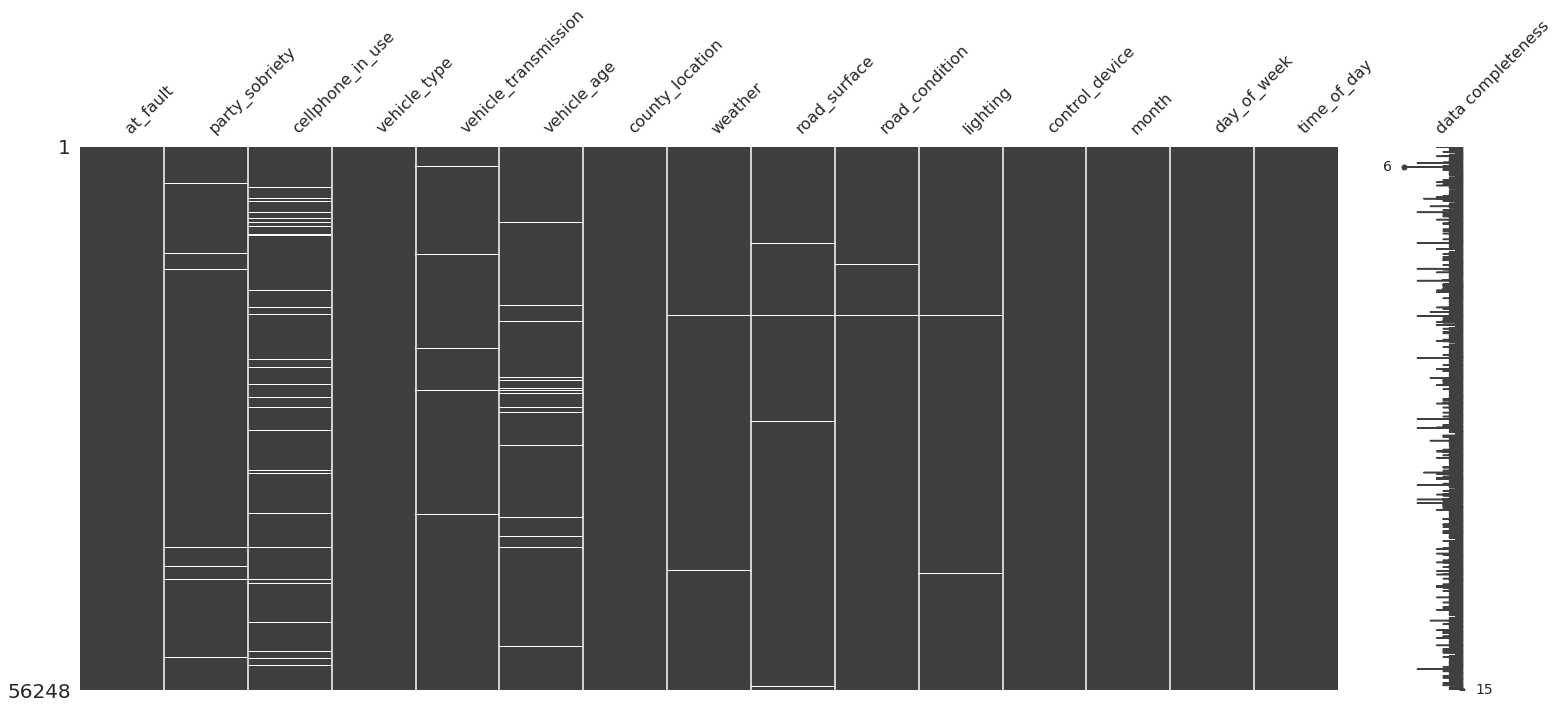

In [ ]:
# применяем функцию на наших данных
pass_miss(dtp, 'отобранных')

Структура пропусков не имеет четких закономерностей по-горизонтали, основные проблемы находятся в определенных столбцах.

In [ ]:
# смотрим распределение по наличию телефонов
dtp['cellphone_in_use'].value_counts()

0.00    50723
1.00     1054
Name: cellphone_in_use, dtype: int64

Подавляющее количество автомобилей не имеет возможности громкой связи. Значит пропуски можно будет заполнить нолем. Но нужно ли? Особенно с учетом большой доли пропусков в данном столбце.

Также посмотрим исходное распределение по виновности.

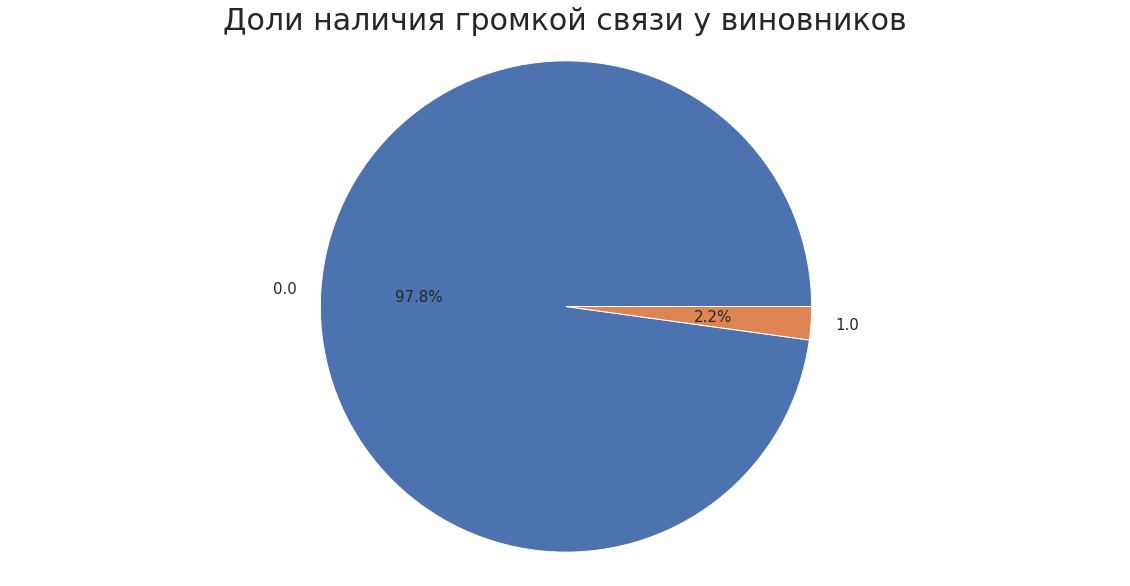

In [ ]:
# визуализируем для виновников
dtp.query('at_fault == 1')['cellphone_in_use'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли наличия громкой связи у виновников', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

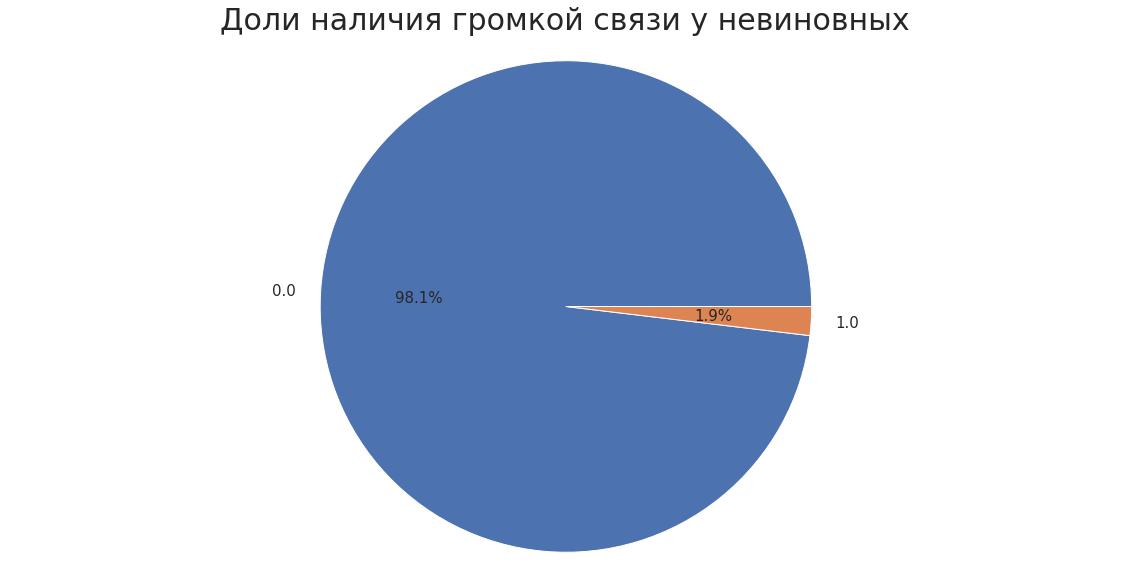

In [ ]:
# визуализируем для невиновных
dtp.query('at_fault == 0')['cellphone_in_use'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли наличия громкой связи у невиновных', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Рапределение также близко (но его наличие немного снижает риск виновности), но с учетом доли пропусков в данных и того, что большинство автомобилей не имеют данных устройств, также удалим этот столбец.

In [ ]:
# удалим столбец
dtp = dtp.drop('cellphone_in_use', axis =1)
dtp.columns # проверка

Index(['at_fault', 'party_sobriety', 'vehicle_type', 'vehicle_transmission',
       'vehicle_age', 'county_location', 'weather', 'road_surface',
       'road_condition', 'lighting', 'control_device', 'month', 'day_of_week',
       'time_of_day'],
      dtype='object')

Часть столбцов мы удалили. Снова взглянем на оставшиеся.

Количество и доля пропусков в очищенных от малоинформативных столбцов:


,Количество,"Доля, %"
at_fault,0,0.00
party_sobriety,872,1.55
vehicle_type,0,0.00
vehicle_transmission,859,1.53
vehicle_age,1694,3.01
county_location,0,0.00
weather,168,0.30
road_surface,348,0.62
road_condition,249,0.44
lighting,154,0.27




 === Визуализация пропусков в очищенных от малоинформативных столбцов данных: ===



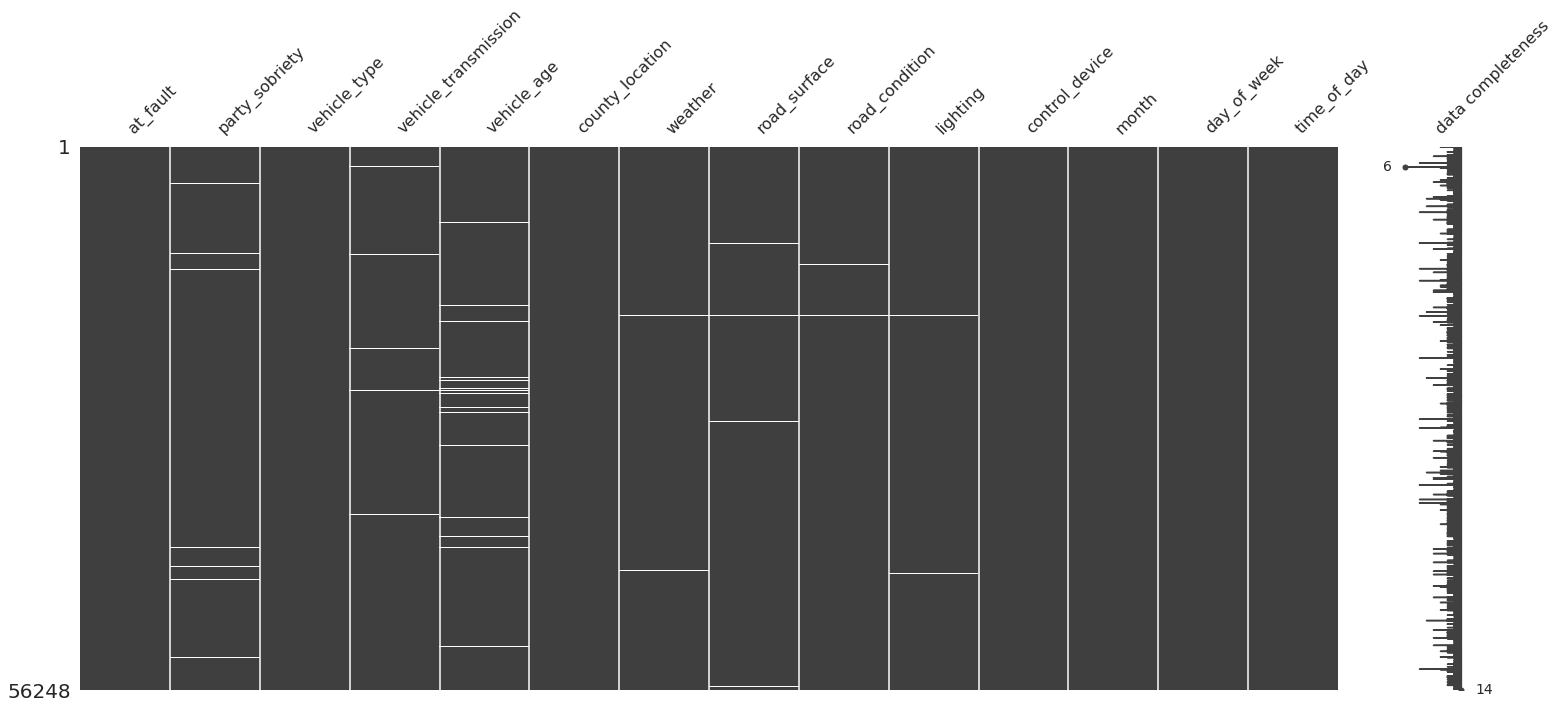

In [ ]:
# применяем функцию на наших данных
pass_miss(dtp, 'очищенных от малоинформативных столбцов')

Признаков стало меньше, зато и доля пропусков у них едва превышает 3% (у `'vehicle_age'`), а значит можно пробовать заполнять их чем-либо вместо удаления, не опасаясь исказить данные.

Мы можем наблюдать, что в некоторых оставшихся строках отсутствуют данные сразу по нескольким столбцам. Возможно, от них тоже можно избавиться безопасно.

In [ ]:
# считаем количество строк, у которых содержатся пропуски более чем в 4 столбцах
len(dtp[dtp.isna().sum(axis=1) >4])

20

In [ ]:
# выводим эти строки
dtp[dtp.isna().sum(axis=1) >4]

,at_fault,party_sobriety,vehicle_type,vehicle_transmission,vehicle_age,county_location,weather,road_surface,road_condition,lighting,control_device,month,day_of_week,time_of_day
1670,0,None,sedan,manual,6.00,sacramento,None,None,None,None,None,2,6,morning
2096,0,None,sedan,None,NaN,los angeles,None,None,None,None,None,3,7,day
5377,1,None,coupe,manual,3.00,santa clara,None,None,None,daylight,None,4,7,day
6172,0,had not been drinking,sedan,auto,7.00,ventura,None,None,None,None,None,1,7,evening
6787,0,None,sedan,manual,4.00,los angeles,None,None,None,None,None,2,7,night
9965,0,None,coupe,manual,6.00,los angeles,None,None,None,None,None,2,3,night
12621,0,None,coupe,manual,3.00,los angeles,None,None,None,None,None,4,6,night
13859,0,None,sedan,manual,4.00,san bernardino,None,None,None,None,None,1,1,day
17111,0,had not been drinking,sedan,auto,3.00,san mateo,None,None,None,None,None,3,2,morning
17492,0,None,coupe,auto,9.00,orange,None,None,None,None,None,4,4,evening


Основные проблемы тут у столбцов, описывающих условия ДТП (погода, состояние дороги в обоих вариантах, освещение) и трезвость участника.

Ввиду небольшого их количества, избавимся от данных строк.

In [ ]:
# пересохраняем датасет без указанныхстрок
dtp = dtp[~(dtp.isna().sum(axis=1) >4)]
dtp.head() #проверка

,at_fault,party_sobriety,vehicle_type,vehicle_transmission,vehicle_age,county_location,weather,road_surface,road_condition,lighting,control_device,month,day_of_week,time_of_day
0,1,impairment unknown,sedan,manual,3.00,san diego,clear,dry,normal,dark with street lights,none,1,5,night
1,0,had not been drinking,sedan,manual,1.00,humboldt,clear,dry,normal,daylight,none,1,6,day
2,0,had not been drinking,sedan,manual,7.00,los angeles,clear,dry,normal,daylight,none,1,4,day
3,0,had not been drinking,sedan,auto,4.00,los angeles,raining,wet,normal,daylight,none,4,5,evening
4,1,"had been drinking, impairment unknown",sedan,manual,2.00,los angeles,cloudy,dry,normal,dark with street lights,none,5,4,night


In [ ]:
# сбросим индекс без сохранения старого
dtp = dtp.reset_index(drop=True)

In [ ]:
# смотрим пропуска и типы данных
dtp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56228 entries, 0 to 56227
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   at_fault              56228 non-null  int64  
 1   party_sobriety        55372 non-null  object 
 2   vehicle_type          56228 non-null  object 
 3   vehicle_transmission  55370 non-null  object 
 4   vehicle_age           54535 non-null  float64
 5   county_location       56228 non-null  object 
 6   weather               56080 non-null  object 
 7   road_surface          55900 non-null  object 
 8   road_condition        55999 non-null  object 
 9   lighting              56093 non-null  object 
 10  control_device        56032 non-null  object 
 11  month                 56228 non-null  int64  
 12  day_of_week           56228 non-null  int64  
 13  time_of_day           56228 non-null  object 
dtypes: float64(1), int64(3), object(10)
memory usage: 6.0+ MB


На этом приостановим работу с пропусками и вернемся к ней позже.

**Выводы**

Мы изучили структуру пропусков с целью определиться с тактикой работы с ними. В результате часть из них (с большой долей пропусков и/или малоинформативные) были удалены. Заполнение оставшихся отложено до получения дополнительной информации.

Проведенное в процессе исследование (для известных данных) показало, что:
- для большей части участников (как виновных, так и нет) состояние неизвестно ("G"), а для многих невиновных - не оценивалось ("not applicate").
- Большая часть автомобилей не имеет устройств громкой связи; данных недостаточно для достоверного утверждения, но можно предположить, что его наличие снижает шанс стать виновником ДТП.

#### Работа с дубликатами и списки признаков

Посмотрим для начала на явные дубликаты. Их большое количество может привести к переобучению модели, поэтому стоит учесть данный момент на будущее.

In [ ]:
# посчитаем дубликаты
print(color.BLUE + color.BOLD +f"Количество явных дубликатов: "+ color.END + f"{dtp.duplicated().sum()}")
print(color.BLUE + color.BOLD +f"Процент явных дубликатов: "+ color.END + f"{dtp.duplicated().sum()/len(dtp)*100:.2f} %")

Количество явных дубликатов: 4904
Процент явных дубликатов: 8.72 %


Явные дубликаты после нашей предварительной подготовки составляют почти 9%. Но мы не можем считать их истинными дубликатами, так как в исходной базе данных все ДТП имели уникальные `'case_id'`, а после предварительной подготовки осталось мало признаков, чтобы различасть их между собой. Поэтому избавляться от них мы не должны (удаление реально разных объектов приведет к искажению стуктуры данных), но их наличие в таком количестве стоит иметь ввиду так это как может привести к утечке данных.

Теперь поищем скрытые.

Но предварительно сгруппируем признаки по типам для будущего удобства в работе. Часть числовых на самом деле категориальные, но пока используем данное разбиение для удобства исследования, исправив уже перед работой с моделью.

In [ ]:
# вспоминаем, что у нас осталось
dtp.columns

Index(['at_fault', 'party_sobriety', 'vehicle_type', 'vehicle_transmission',
       'vehicle_age', 'county_location', 'weather', 'road_surface',
       'road_condition', 'lighting', 'control_device', 'month', 'day_of_week',
       'time_of_day'],
      dtype='object')

In [ ]:
# целевой
target = 'at_fault'

In [ ]:
# создаем список числовых столбцов
num_col_names = ['vehicle_age', 'month', 'day_of_week']

In [ ]:
# создаем список категориальных столбцов
cat_col_names = ['party_sobriety', 'vehicle_type', 'vehicle_transmission',
                 'county_location', 'weather', 'road_surface', 'road_condition',
                 'lighting', 'control_device','time_of_day']

In [ ]:
# функция для подсчета и вывода уникальных значений:
def uniq(data, col_name):
    for col in col_name:
        print(color.BLUE + color.BOLD + f"Количество уникальных значений в столбце {col}: "
              + color.END + f"{len(data[col].unique())}") # считаем
        try:
            print(color.BLUE + color.BOLD + f"Уникальные значения столбца {col}: "
               + color.END + '\n' + f"{data[col].sort_values().unique()}\n") # смотрим с сортировкой
        except:
            print(color.BLUE + color.BOLD + f"Уникальные значения столбца {col}: "
               + color.END + '\n' + f"{data[col].unique()}\n") # смотрим без сортировки

In [ ]:
# применяем функцию uniq
uniq(dtp, cat_col_names)

Количество уникальных значений в столбце party_sobriety: 7
Уникальные значения столбца party_sobriety: 
['had been drinking, impairment unknown'
 'had been drinking, not under influence'
 'had been drinking, under influence' 'had not been drinking'
 'impairment unknown' 'not applicable' None]

Количество уникальных значений в столбце vehicle_type: 3
Уникальные значения столбца vehicle_type: 
['coupe' 'other' 'sedan']

Количество уникальных значений в столбце vehicle_transmission: 3
Уникальные значения столбца vehicle_transmission: 
['auto' 'manual' None]

Количество уникальных значений в столбце county_location: 58
Уникальные значения столбца county_location: 
['alameda' 'alpine' 'amador' 'butte' 'calaveras' 'colusa' 'contra costa'
 'del norte' 'el dorado' 'fresno' 'glenn' 'humboldt' 'imperial' 'inyo'
 'kern' 'kings' 'lake' 'lassen' 'los angeles' 'madera' 'marin' 'mariposa'
 'mendocino' 'merced' 'modoc' 'mono' 'monterey' 'napa' 'nevada' 'orange'
 'placer' 'plumas' 'riverside' 'sacramen

Мы снова можем наблюдать расхождение в написании значений с столбцах в предварительном описании БД и теми, что в реальности (например, для столбца `'lighting'`).

Везде (кроме `'county_location'` и `'vehicle_type'`) присутствуют пропуски Nan или None, при этом количество вариантов в столбцах небольшое и скрытые дубликаты отсутствуют (за исключением столбца `'control_device'`). В зависимости от структуры данных столбцов пропуски можно будет заметить или значенем заглушкой, или самым частым.

В столбце `'vehicle_type'` пропусков нет и значений немного, причем конкретных типов (не считая тип "other") кузова попало только два из четырех, которых мы могли найти в описании к таблице. Возможно, автомобили, иформация по которым не сохранилась, относились к типам "minivan" или "hatchback". Или такие автомобили покинули автопарк? Это мы не узнаем, но на это стоит обратить внимание заказчика.

Столбец `'county_location'` не имеет пропусков, однако он слишком разнообразен. Поэтому потенциально лучше применить группировку вариантов признака между собой. Например, оставив несколько наиболее популярных, а остальные объединив в группу "иные".

В столбце `'control_device'` обнаружен скрытый дубликат "none", обозначающий (согласно описанию данных) отсутствие устройсва управления, и None (пропуск), который обозначает, что данная информация не указана (т.е. "none" и None имеют разное значение м второе на первое заменять может быть не корректно)

Также дополнительно необходимо изучить и остальные столбцы на предмет возможности укрупнений между собой (на случай, если какие-либо признаки занимают небольшую долю).

Но все это сделаем после проведения исследовательского анализа.

**Выводы**

- Обнаружено около 2.5% явных дубликатов, которые однако не могут считаться истинными.
- Скрытых дубликатов не обнаружено.
- В столбце `'county_location'` обнаружено большое количество уникальных вариантов признака, поэтому, возможно, будет необходимо найти возможность укрупнить признаки в группу.

## Анализ признаков

#### Исследовательский анализ (общий и портрет виновника)

Перед этим мы в основном изучали категориальные признаки. К ним мы еще вернемся, а пока взглянем на числовые.

In [ ]:
# общее числовое описание
dtp[num_col_names].describe()

,vehicle_age,month,day_of_week
count,"54,535.00","56,228.00","56,228.00"
mean,4.86,3.23,4.16
std,3.23,1.81,1.97
min,0.00,1.00,1.00
25%,3.00,2.00,2.00
50%,4.00,3.00,4.00
75%,7.00,4.00,6.00
max,161.00,12.00,7.00


Здесь мы снова встречаем аномальные возраста. Для месяцев и дней недели данные выглядят адекватно.

In [ ]:
# вглянем на аномальные строки
dtp[dtp['vehicle_age'] == 161]

,at_fault,party_sobriety,vehicle_type,vehicle_transmission,vehicle_age,county_location,weather,road_surface,road_condition,lighting,control_device,month,day_of_week,time_of_day
27802,1,had not been drinking,sedan,manual,161.00,los angeles,clear,dry,normal,daylight,none,6,3,morning
31267,0,had not been drinking,sedan,manual,161.00,los angeles,clear,dry,normal,dusk or dawn,functioning,12,3,night


Таких строк всего две, поэтому можно спокойно их удалить. Но сделаем это после разделения на выборки и только в тренировочной, так как тестовая должна имитировать реальные данные, в которой могут встречаться аномалии разного рода.

Так как наш столбец числовой, то было бы логичнее заменить его средним значением или медианой. Но это может оказаться не совсем корректным, ведь значения возраста представлены дискретными числами. Поэтому необходимо провести исследование. А чтобы его не искажали ранее обнаруженные аномалии, то исключим их из рассмотрения.

In [ ]:
# смотрим общее числовое описание возраста
dtp[dtp['vehicle_age'] !=161]['vehicle_age'].describe()

count   54,533.00
mean         4.85
std          3.09
min          0.00
25%          3.00
50%          4.00
75%          7.00
max         19.00
Name: vehicle_age, dtype: float64

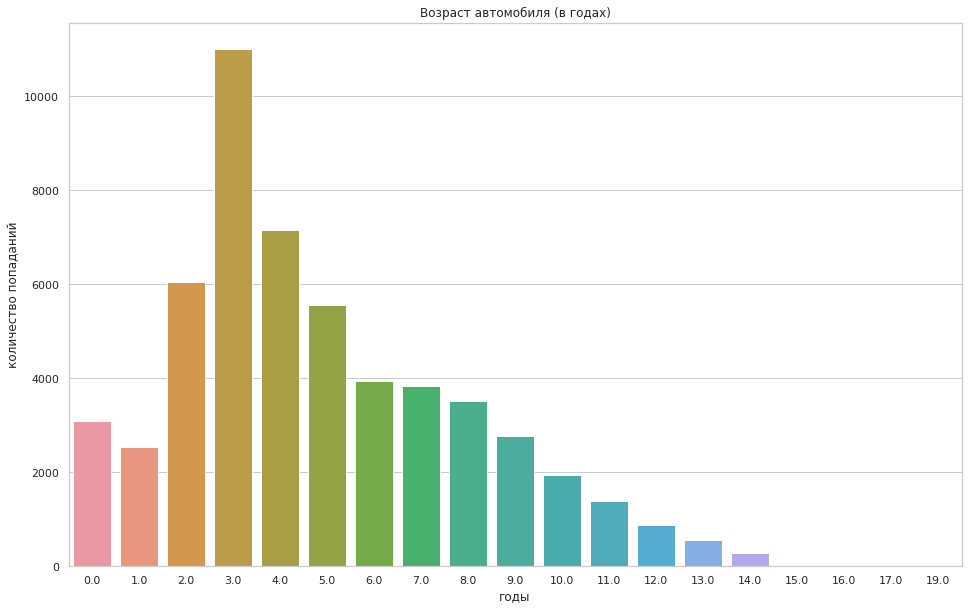

In [ ]:
# график для дискретного признака (на каждое уникальные значение признака строит свою корзину)
plt.figure(figsize=(16,10))

sns.countplot(x=dtp[dtp['vehicle_age'] !=161]['vehicle_age'])

plt.title('Возраст автомобиля (в годах)')
plt.xlabel('годы')
plt.ylabel('количество попаданий')

plt.show()

In [ ]:
# смотрим распределение по количествам
# сортируем от меньшего к большему
# цена стало их индексом

dtp[dtp['vehicle_age'] !=161]['vehicle_age'].value_counts().reset_index().sort_values(by='index')

,index,vehicle_age
7,0.00,3087
9,1.00,2545
2,2.00,6048
0,3.00,11007
1,4.00,7153
3,5.00,5564
4,6.00,3938
5,7.00,3835
6,8.00,3508
8,9.00,2768


В целом, у нас автомобилей более молодых больше, чем возрастных, и больше всего - трехлетних. Распределение можно назвать почти нормальным, лишь с некоторым провалом на одном году. Возможно, в тот год было закуплено меньше автомобилей, чем в предыдущие несколько или следующий (либо их партия оказалось более безопасной, чем остальные, и потому годовалые автомобили реже попадали в ДТП и статистику).

Ввиду чего будет вполне корректно заменить пропуски медианой, что мы и сделаем, но уже после разделения на тренировочную и тестовую выборку. Но предварительно посчитаем количество пропусков на будущее.

In [ ]:
# считаем исходное количество пропусков
print(color.BLUE + color.BOLD + f"Количество пропусков в столбце 'vehicle_age': "
              + color.END + f"{dtp['vehicle_age'].isna().sum()}")

Количество пропусков в столбце 'vehicle_age': 1693


Вглянем на данный столбец в разрезе интересующих групп чуть позже, когда будем составлять портрет виновника.

Составим портрет виновника на основании имеющихся у нас данных.

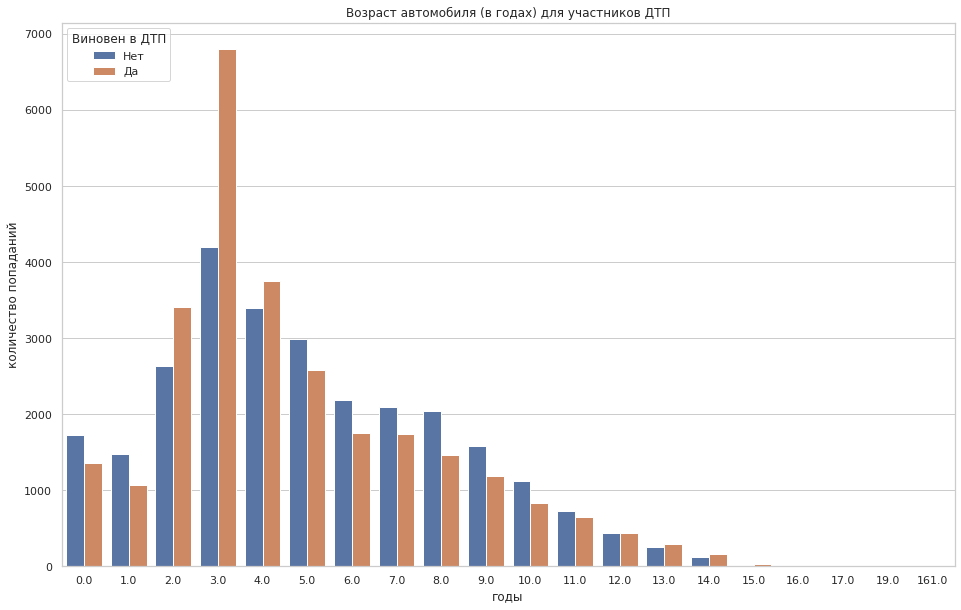

In [ ]:
# возраст автомобиля
# общий график для наглядности
plt.figure(figsize=(16,10))

# Создаем общий график с разделением по признаку at_fault
sns.countplot(x='vehicle_age', hue='at_fault', data=dtp)

plt.title('Возраст автомобиля (в годах) для участников ДТП')
plt.xlabel('годы')
plt.ylabel('количество попаданий')

# Добавляем легенду для пояснения цветов
plt.legend(title='Виновен в ДТП', labels=['Нет', 'Да'])

plt.show()

Чаще всего виновниками ДТП становятся автомобили с двух до четырех лет включительно. Самые "опасные" - трехлетние. Но возможно, их просто больше всего в автопарке (лучше бы уточнить этот момент у заказчика).

Теперь перейдем к месяцам. Статистику по ним мы уже наблюдали ранее, но можем взглянуть еще раз.

In [ ]:
# смотрим общее числовое описание месяцев
dtp['month'].describe()

count   56,228.00
mean         3.23
std          1.81
min          1.00
25%          2.00
50%          3.00
75%          4.00
max         12.00
Name: month, dtype: float64

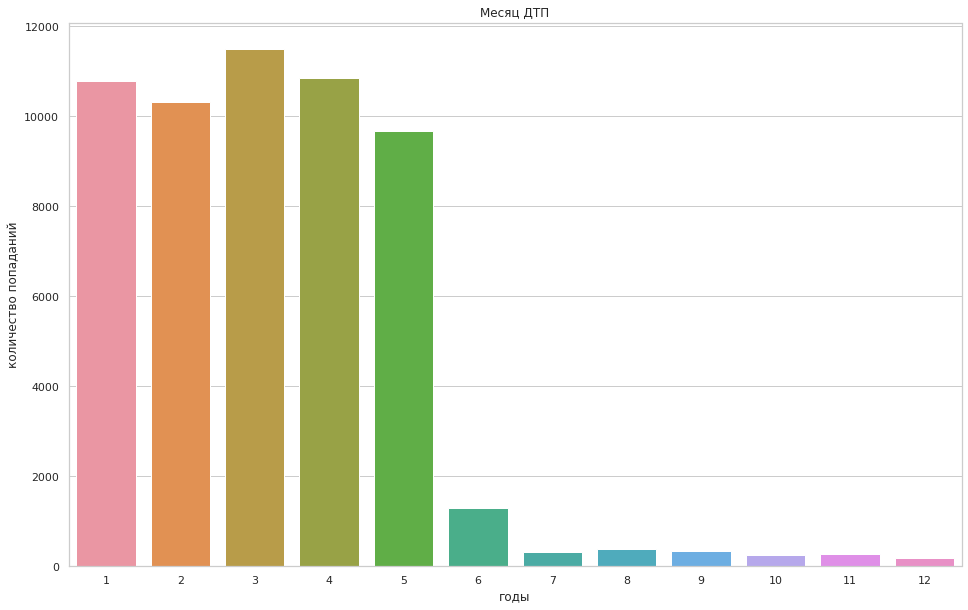

In [ ]:
# график для дискретного признака (на каждое уникальные значение признака строит свою корзину)
plt.figure(figsize=(16,10))

sns.countplot(x=dtp['month'])

plt.title('Месяц ДТП')
plt.xlabel('годы')
plt.ylabel('количество попаданий')

plt.show()

Здесь мы наблюдаем то же, что наблюдали ранее, проводя статистический анализ ДТП по месяцам: большое количество ДТП до мая включительно, а затем - резкое их падение в июне, и сильное сокрашение в оставшиеся месяцы. То, что хорошо бы знать причину этого, мы уже упоминали, как и то, что самостоятельно это не представляется возможным.

Посмотрим в разрезе целевого признака.

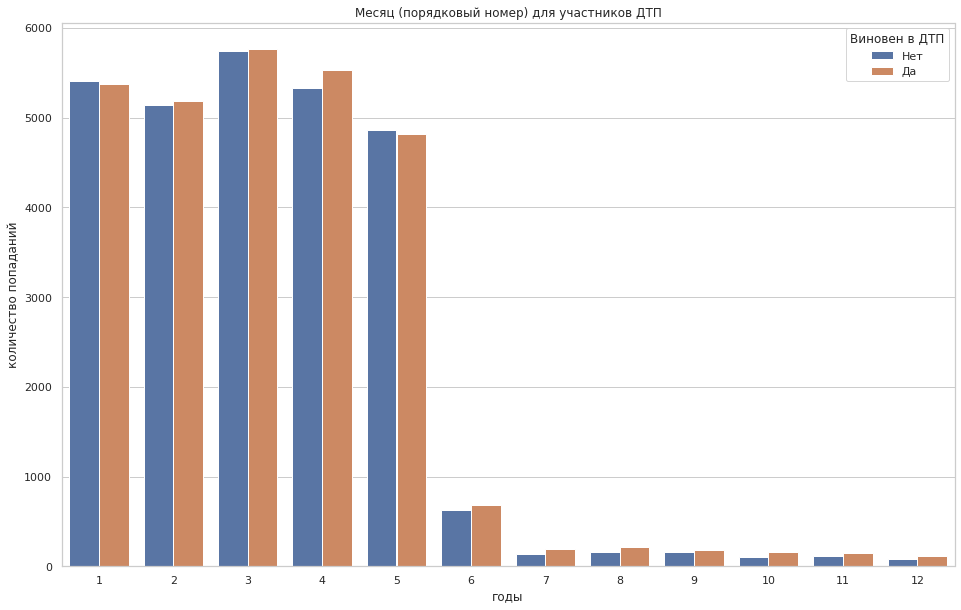

In [ ]:
# месяц аварии
# общий график для наглядности
plt.figure(figsize=(16,10))

# Создаем общий график с разделением по признаку at_fault
sns.countplot(x='month', hue='at_fault', data=dtp)

plt.title('Месяц (порядковый номер) для участников ДТП')
plt.xlabel('годы')
plt.ylabel('количество попаданий')

# Добавляем легенду для пояснения цветов
plt.legend(title='Виновен в ДТП', labels=['Нет', 'Да'])

plt.show()

Общая динамика двух групп похожа. Но доля виновников больше в апреле, а также в месяцы "затишья" (с июля по декабрь). Возможно, в тот период стало меньше ДТП с участием двух и более автомобилей?

In [ ]:
# смотрим общее числовое описание дней недели
dtp['day_of_week'].describe()

count   56,228.00
mean         4.16
std          1.97
min          1.00
25%          2.00
50%          4.00
75%          6.00
max          7.00
Name: day_of_week, dtype: float64

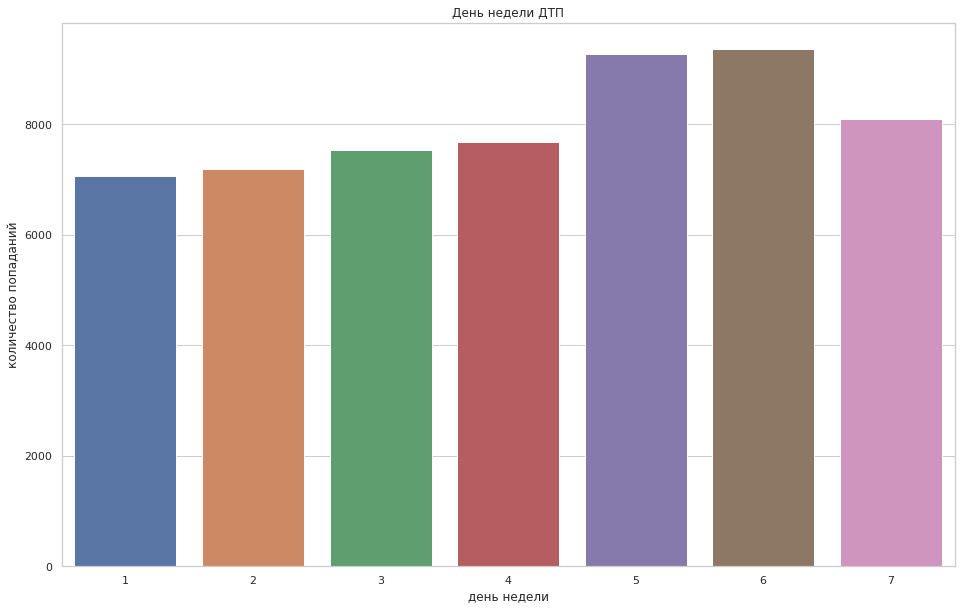

In [ ]:
# график для дискретного признака (на каждое уникальные значение признака строит свою корзину)
plt.figure(figsize=(16,10))

sns.countplot(x=dtp['day_of_week'])

plt.title('День недели ДТП')
plt.xlabel('день недели')
plt.ylabel('количество попаданий')

plt.show()

С учетом того, что наши данные представляют собой в некотором роде кольцо, распределение можно считать нормальным. Также мы видим, что наибольшее количество ДТП происходит в пятницу и субботу, и также много (хоть и ниже ранее указанных дней) - в воскресенье. Возможно, это связано с состоянием усталости либо употреблением алкоголя в данные дни (с вечера пятницы и до утра воскресенья, а в само воскресенье алкоголь мог не успеть выветриться), плюс в пятницу у некоторых организаций сокращенный день, потому сам трафик может возрасти.

Наиболее низкий уровень ДТП - в понедельник. Возожно ввиду того, что в выходные удается отдохнуть (меньше усталости), и к данному моменту алкоголь у употреблявших уже выводится из организма. Плюс, у некоторых организаций понедельник является выходным днем, что может приводит к снижению общего уровня активности.

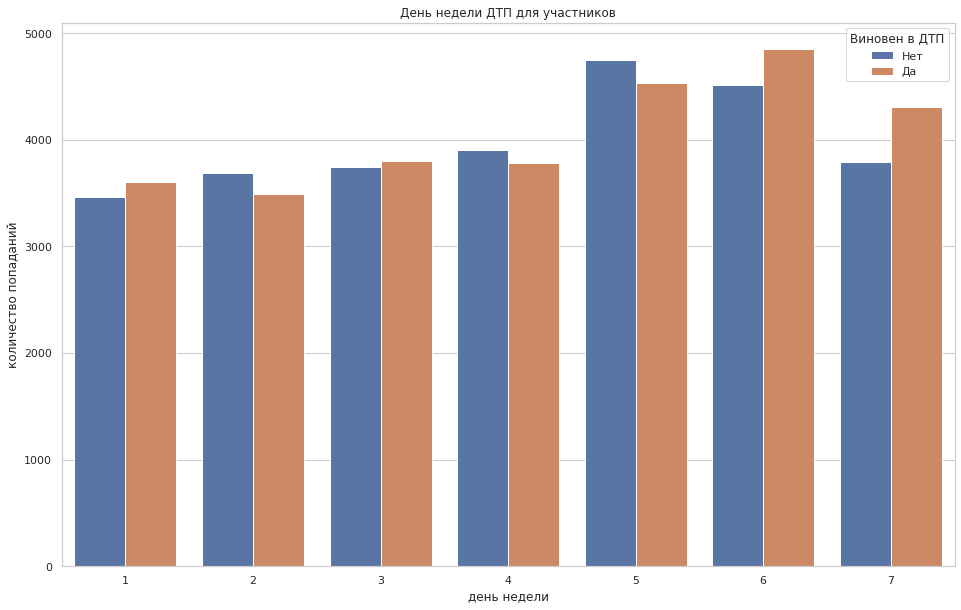

In [ ]:
# день недели
# общий график для наглядности
plt.figure(figsize=(16,10))

# Создаем общий график с разделением по признаку at_fault
sns.countplot(x='day_of_week', hue='at_fault', data=dtp)

plt.title('День недели ДТП для участников')
plt.xlabel('день недели')
plt.ylabel('количество попаданий')

# Добавляем легенду для пояснения цветов
plt.legend(title='Виновен в ДТП', labels=['Нет', 'Да'])

plt.show()

Здесь мы можем наблюдать, что в разные дни вероятности стать виновником разные. Саиый контраст представляют собой близкие по общему количеству, но разные по структуре виновности пятница (когда шансы стать виновником выше, возможно ввиду накопления недельной усталости либо употребления алкоголя) и суббота (когда стать виновником шансов меньше, возможно, что состояние учатника уже улучшается к этому моменту, что может быть также применимо и к воскресенью).

Посмотрим, если связь у виновности, алкогольного состояния и дня недели.

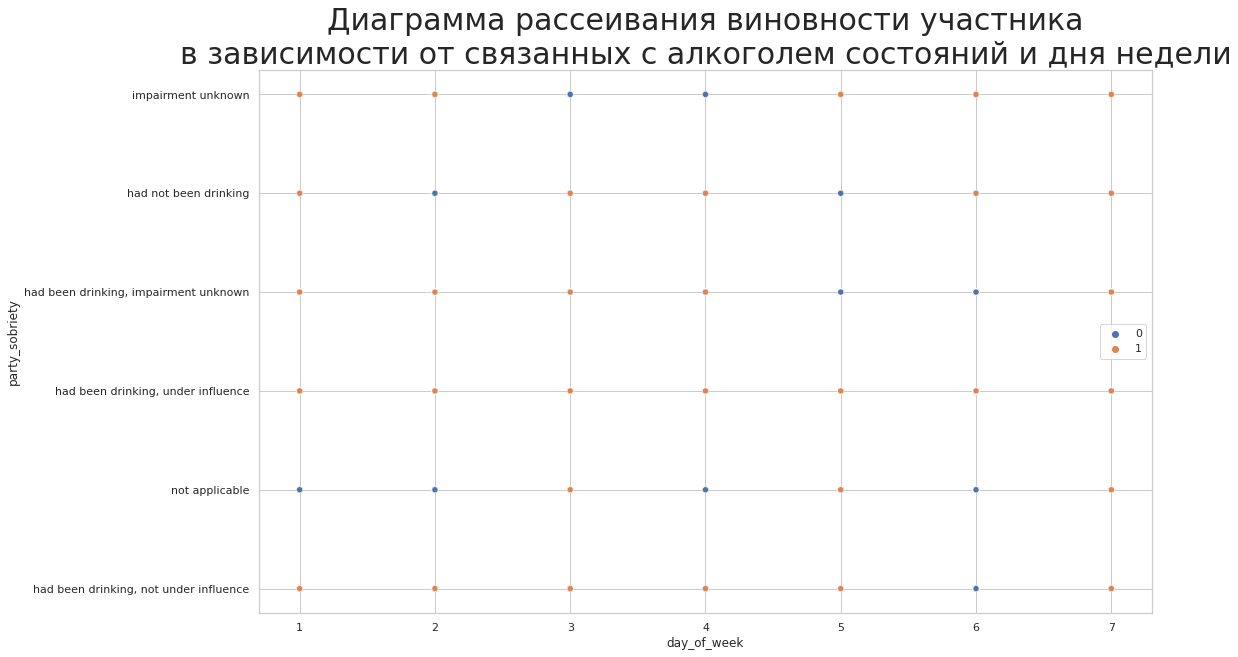

In [ ]:
# диаграмма рассеяния, вариант 1
plt.figure(figsize=(16,10))

sns.scatterplot(data=dtp, hue='at_fault', x='day_of_week' , y= 'party_sobriety')
plt.legend(loc='best')
plt.title('Диаграмма рассеивания виновности участника\n\
в зависимости от связанных с алкоголем состояний и дня недели', fontsize=30)

plt.show()

В понедельник похоже вина не слишком зависит о состояний, связанных с разными состояниями трезвости - встречаются разные типы этих состояний (даже "не обследован" и "не пил", которые в остальные дни исключительно невиновные).

В пятницу "естественное состояние" для виновников - "был пьян, под влиянием", что мы и предполагали. В субботу к ним добавились "был пьян, не под влиянием" и "был пьян, ухудшение неизвестно" плюс "ухудшение неизвестно" - то есть алкоголь понемногу "выветривается" из виновников. В воскресенье картина аналогичная.

То есть мы можем заявить о наличии зависимости между состояними, связанными  алкоголем, для дней с пятницы по воскресенье включительно. То есть, хотя он сам не может быть включен в модель, но его косвенное влияние будет присутвовать.

Теперь переключимся на полностью категориальные данные. Для начала дополним картину по уровням трезвости участников.

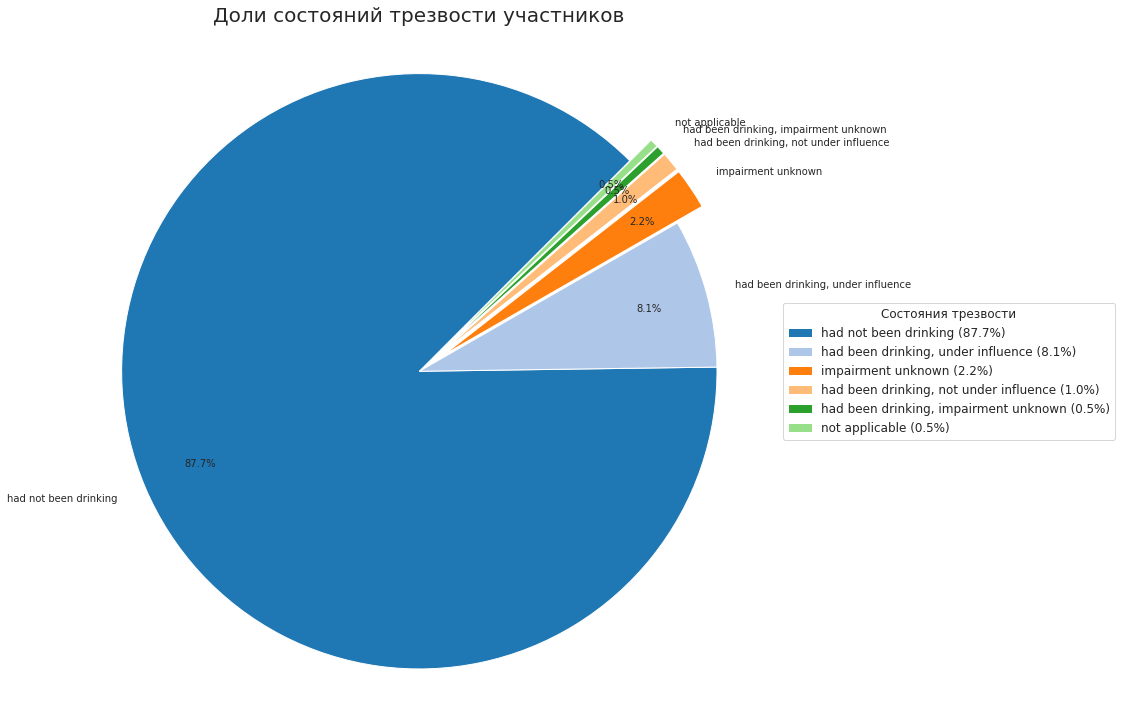

In [ ]:
# Пирог с дополнительными настройками
# Данные
values = dtp['party_sobriety'].value_counts()
labels = values.index

# Настройки
threshold = 0.05  # Порог для выноса (5%)
explode = [0.1 if v/sum(values) < threshold else 0 for v in values]  # Вынос малых
colors = plt.cm.tab20.colors[:len(values)]  # Цвета из палитры

# Построение
fig, ax = plt.subplots(figsize=(15, 10))
wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    autopct='%.1f%%',# добавлено для отображения процентов
    pctdistance=0.8, # расстояние от центра пирога, на котором будут отображаться проценты
    explode=explode, # вынесение долей
    colors=colors, # цвета
    startangle=45, # начало отсчета (15 часов)
    textprops={'fontsize': 10}, # уменьшаем шрифт, если проценты перекрываются
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}  # Границы долек/секторов
)

# Легенда с процентами
percent = [f'{100*value/sum(values):.1f}%' for value in values]
ax.legend(
    wedges,
    [f'{l} ({p})' for l, p in zip(labels, percent)],
    title="Состояния трезвости",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=12
)

plt.title('Доли состояний трезвости участников', fontsize=20, pad=20)
plt.axis('equal')
plt.tight_layout()  # Чтобы легенда не обрезалась
plt.show()

Мы можем наблюдать, что основная часть (почти 88%) участников были трезвыми. Лишь 8% из них были пьяны и находились под влиянием алкоголя. Остальные состояния занимают от около двух и менее процентов.

Пока мы не можем утвеждать о связи виновности и состояния трезвости. Поэтому взглянем на данные в разрезе целевого признака.

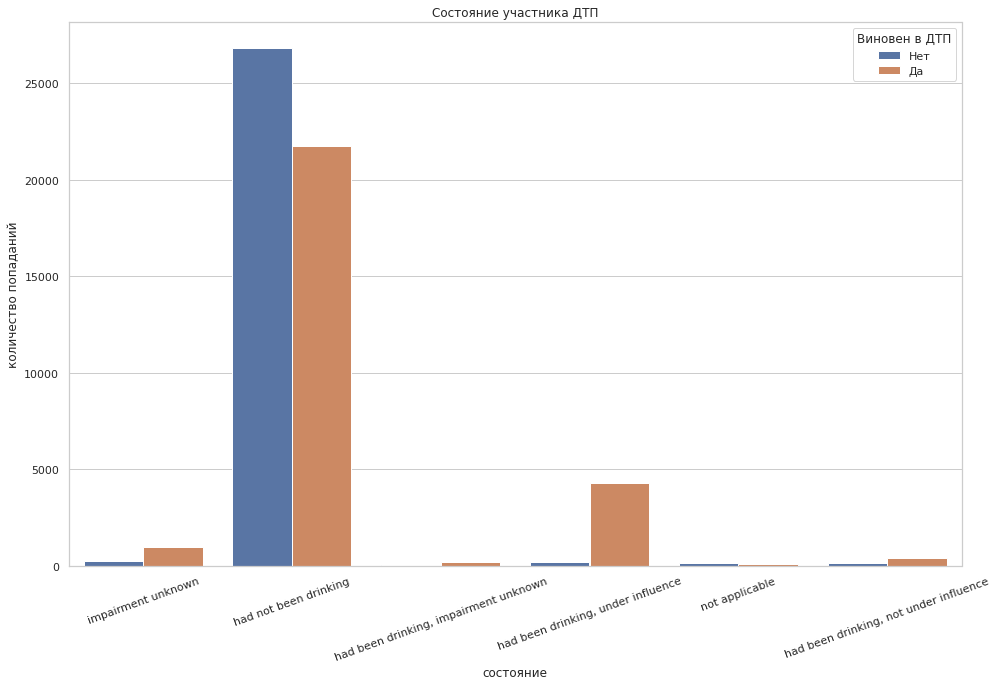

In [ ]:
# состояние участника
# общий график для наглядности
plt.figure(figsize=(16,10))

# Создаем общий график с разделением по признаку at_fault
sns.countplot(x=dtp['party_sobriety'], hue='at_fault', data=dtp)

plt.title('Состояние участника ДТП')
plt.xlabel('состояние')
plt.ylabel('количество попаданий')

# Добавляем легенду для пояснения цветов
plt.legend(title='Виновен в ДТП', labels=['Нет', 'Да'])

# наклоняем надписи на оси x
plt.xticks(rotation=20)

plt.show()

Трезвые участники реже становились виновниками. Доля необследованных близка. В целом, состояния связанные с алкоголем (различных степеней) дают больше шансов стать виновником. Но, по условиям заказчика, мы не сможем использовать данный признак в обучении, поэтому перед работой с моделью придется от него избавиться.

Теперь вернемся к остальным категориальным столбцам. Однако вручную перебирать каждый несколько неудобно. Попробуем немного упростить данный процесс.

In [ ]:
# вспоним названия столбцов и где еще остались пропуски
dtp.isna().sum()

at_fault                   0
party_sobriety           856
vehicle_type               0
vehicle_transmission     858
vehicle_age             1693
county_location            0
weather                  148
road_surface             328
road_condition           229
lighting                 135
control_device           196
month                      0
day_of_week                0
time_of_day                0
dtype: int64

Сначала взглянем в общем виде.

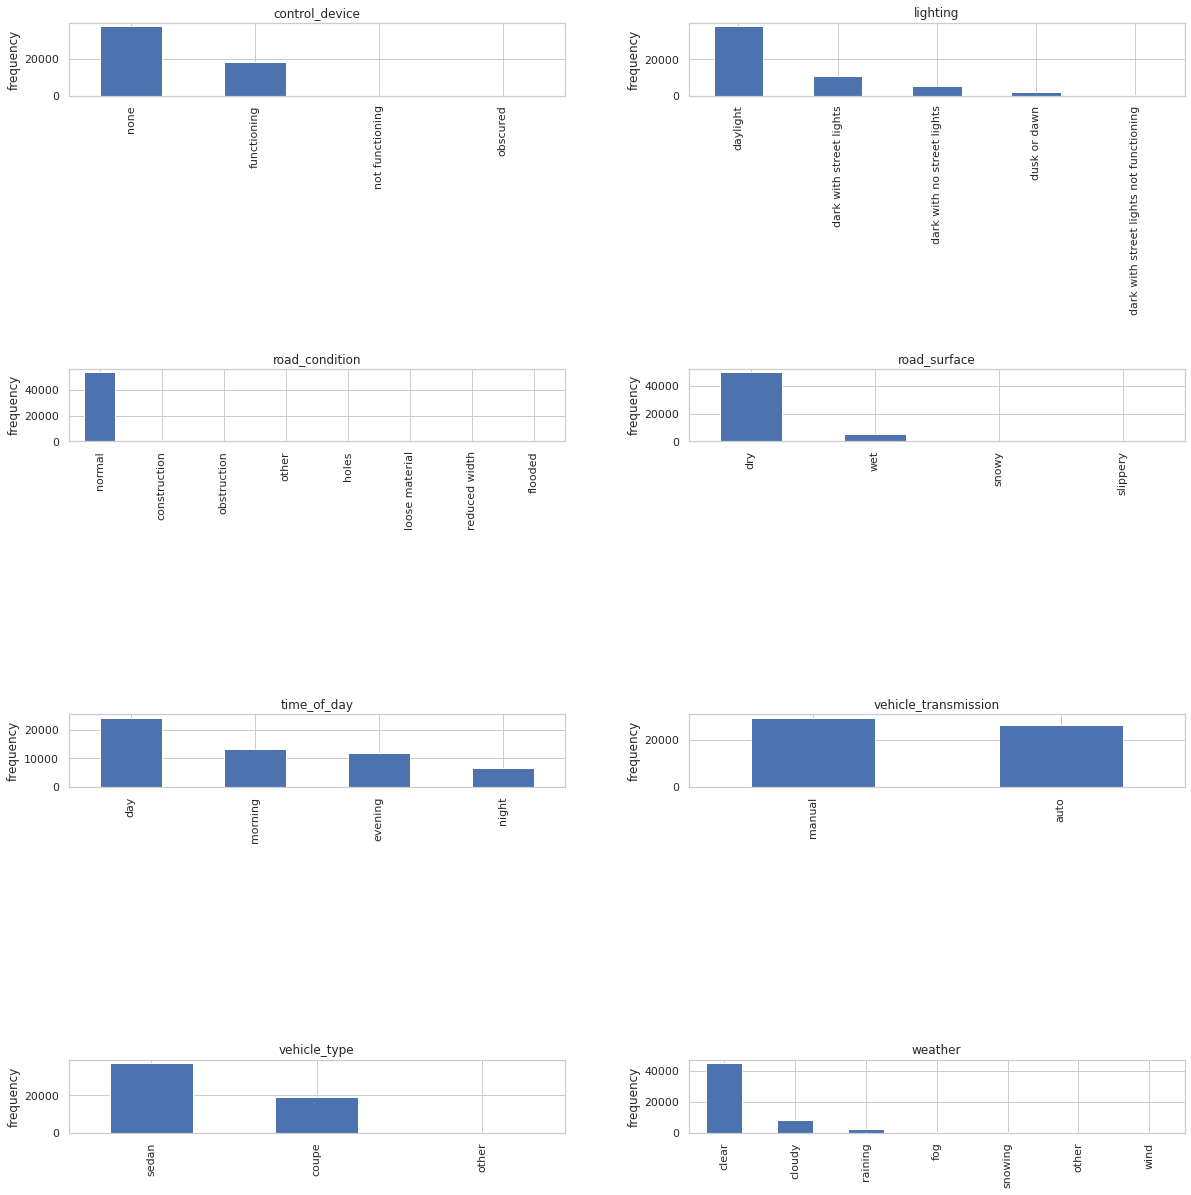

In [ ]:
# общая картина
# создание графиков в зависимости от автоматически определяемого типа
fig = plt.figure(figsize=(20, 84))
plt.subplots_adjust(wspace=0.25, hspace=3.75)

# исключим те столбцы, которые мы уже изучили и столбы с большим количеством уникальных значений
for i, col in enumerate(dtp.columns.difference(['at_fault', 'party_sobriety', 'vehicle_age',
                                                'month', 'day_of_week', 'county_location'])):
    ax = fig.add_subplot(14, 2, i + 1)

    # Отобразим количественные и категориальные переменные соответствующими методами
    if pd.api.types.is_numeric_dtype(dtp[col]):
        dtp[col].plot(kind='hist', edgecolor='black')
    else:
        dtp[col].value_counts().plot(kind='bar')

    ax.set_title(col)
    ax.set_ylabel('frequency')
    ax.grid(visible=True)

И в разрезе групп.

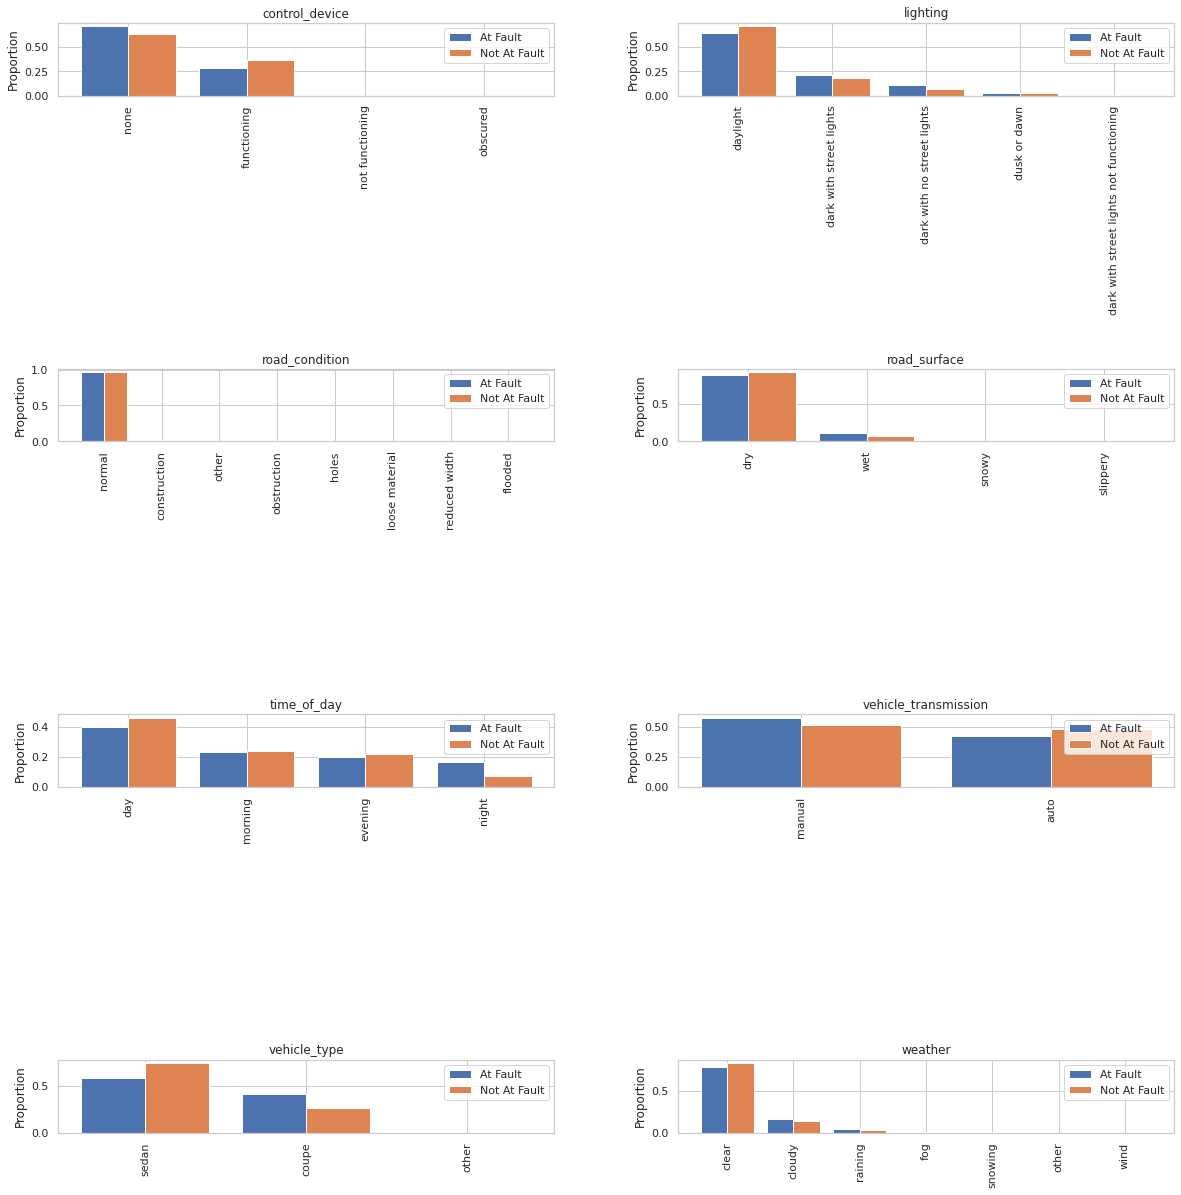

In [ ]:
# создание графиков в зависимости от автоматически определяемого типа
# в разрезе групп
fig = plt.figure(figsize=(20, 84))
plt.subplots_adjust(wspace=0.25, hspace=3.75)

# исключим те столбцы, которые мы уже изучили
for i, col in enumerate(dtp.columns.difference(['at_fault', 'party_sobriety', 'vehicle_age',
                                                'month', 'day_of_week', 'county_location'])):
    ax = fig.add_subplot(14, 2, i + 1)

    # Отобразим количественные и категориальные переменные соответствующими методами
    if pd.api.types.is_numeric_dtype(dtp[col]):
        # Для числовых данных - гистограммы
        dtp.query('at_fault == 1')[col].plot(kind='hist', edgecolor='black', alpha=0.5, label='At Fault', density=True)
        dtp.query('at_fault == 0')[col].plot(kind='hist', edgecolor='black', alpha=0.5, label='Not At Fault', density=True)
    else:
        # Для категориальных данных - bar plot
        fault_counts = dtp.query('at_fault == 1')[col].value_counts(normalize=True)
        no_fault_counts = dtp.query('at_fault == 0')[col].value_counts(normalize=True)

        width = 0.4  # Ширина столбцов
        x = np.arange(len(fault_counts))

        ax.bar(x - width/2, fault_counts, width=width, label='At Fault')
        ax.bar(x + width/2, no_fault_counts, width=width, label='Not At Fault')

        ax.set_xticks(x)
        ax.set_xticklabels(fault_counts.index, rotation=90)  # Вращение подписей на 90 градусов

    ax.set_title(col)
    ax.set_ylabel('Proportion')  # Изменили на Proportion, так как используем нормализацию
    ax.grid(visible=True)
    ax.legend()  # Добавляем легенду для различения групп

plt.show()

По распределению общих количеств для столбца `'control_device'` мы видим две крупные группы - "нет" (характерно для большинства автомобилей) и "функционирует", остальные занимают лишь малую долю. При распределении по группам мы можем увидеть, что групп "нет" чаще становится виновниками, чем группа "функционирует".

С учетом этих наблюдений, а также логического содержимого категорий, можно заполнить пропуски (которые обозначают тут "неизвестно") значением "нет", а после укрупнить в одну группу состояния, отличные от "функционирует" ("не функционирует", "нет", "затемнено") как ему противоположные.

Большинство ДТП приходится на день, меньше всего случается ночью. А вот шансов стать виновником ночью выше всего, а днем же минимальная. Это может быть связано с с состоянием участника (сонливость, усталость), а также ухудшением видимости ночью.

На всякий случай проверим связь с уровнем трезвости участника.

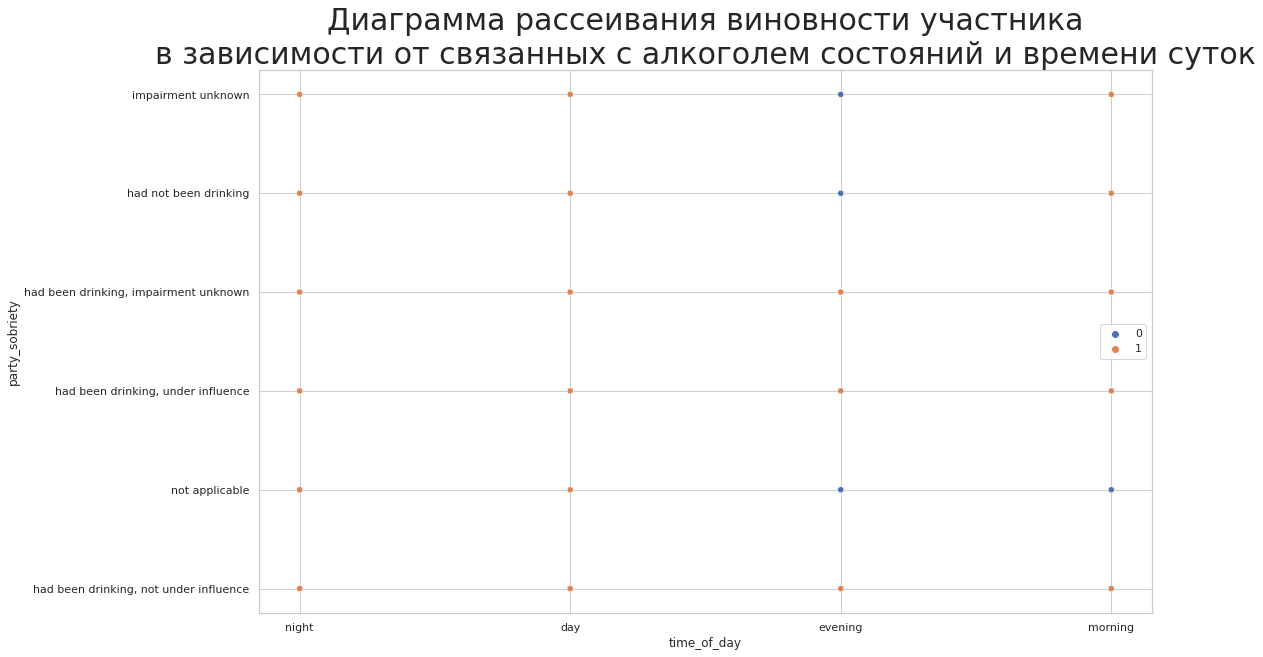

In [ ]:
# диаграмма рассеяния, вариант 1
plt.figure(figsize=(16,10))

sns.scatterplot(data=dtp, hue='at_fault', x='time_of_day' , y= 'party_sobriety')
plt.legend(loc='best')
plt.title('Диаграмма рассеивания виновности участника\n\
в зависимости от связанных с алкоголем состояний и времени суток', fontsize=30)

plt.show()

А вот связь между виновностью, состоянием трезвости и временем суток установить проблематично. Лишь те, кто не оценивался, часто не являются виновниками в любое время суток (видимо, поэтому в том числе их и не обследовали - не было нужды).

Большинство ДТП (столбец `'lighting'`) происходило при дневном свете (что вполне логично, так как днем люди более активно передвигаются, и по количеству ДТП день лидирует среди частей суток). Причем шанс стать виновником ДТП в темноте в целом выше (что также логично - хуже видимость, плюс может подключаться усталость, если дело происходит ночью), но при риске темноты они примерно равны.

In [ ]:
# посмотрим распределение по количеству
dtp['lighting'].value_counts()

daylight                                   38063
dark with street lights                    11017
dark with no street lights                  5109
dusk or dawn                                1769
dark with street lights not functioning      135
Name: lighting, dtype: int64

С учетом распределений, возможно правильнее будет заполнить пропуски значением "дневной свет" как более популярным, а остальные варианты объединить в одну категорий "темнота или риск темноты" (хотя при риске шансы приблизительно равны, нам важнее предотвратить авирию, поэтому перестрахуемся таким образом).

Но для начала посмотрим чуть внимательнее в разрезе групп.

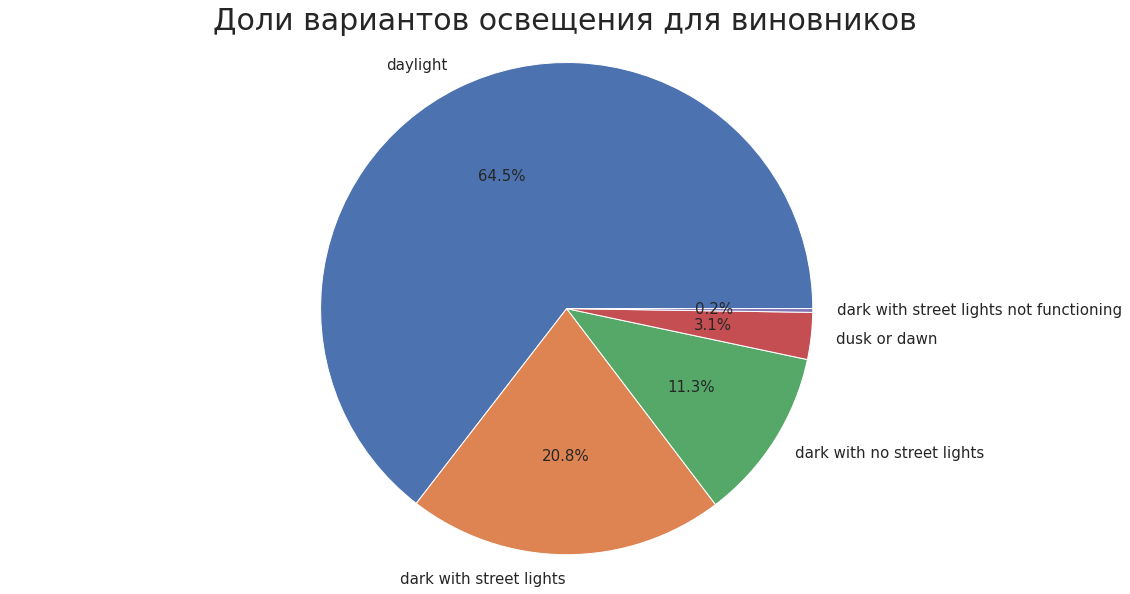

In [ ]:
# визуализируем трезвость участников
# виновники
dtp.query('at_fault == 1')['lighting'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли вариантов освещения для виновников', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

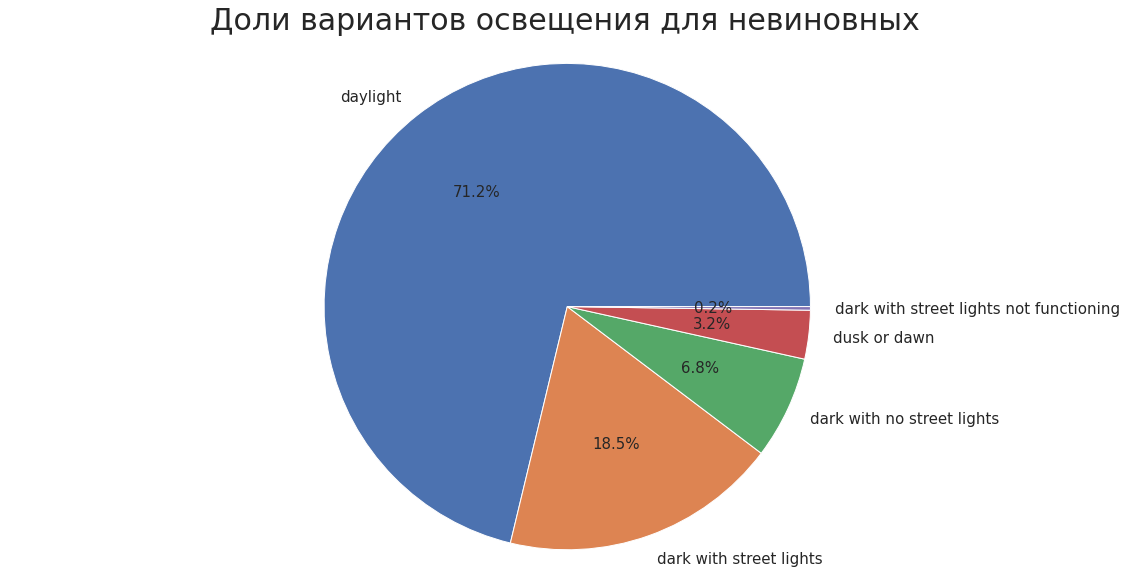

In [ ]:
# визуализируем трезвость участников
# невиновные
dtp.query('at_fault == 0')['lighting'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли вариантов освещения для невиновных', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Нет, бинарное деление тут не подойдет, с учетом разности процентов у некоторых состояний.

Можно заполнить пропуски "дневное освещение", а состояние "темнота без фонарей" и "темнота с неработающими фонарями" объединить.

В большинстве случаев для состояния дороги `'road_condition'` характерно значение "нормально", в разрезе по группам различий не обнаружено. Поэтому данный столбец возможно удалить.

Посмотрим на другое состояние дороги (`'road_surface'`) в разрезе групп. Мы его наблюдали ранее в разрезе всего периода, и там он аказался не очень информативным. Вдруг тут будет иначе?

Сначала мы также видим, что шансы попасть в ДТП выше на сухой дороге, чем на мокрой (что может объясняться повышенной активность на дорогах в хорошую погоду).

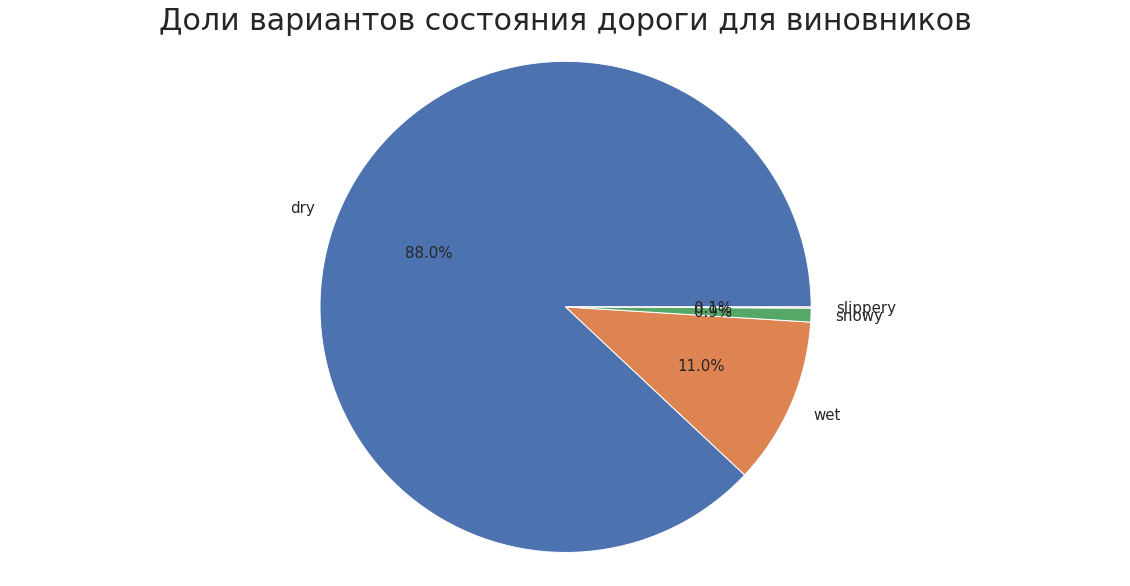

In [ ]:
# визуализируем состояние дороги
# виновники
dtp.query('at_fault == 1')['road_surface'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли вариантов состояния дороги для виновников', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

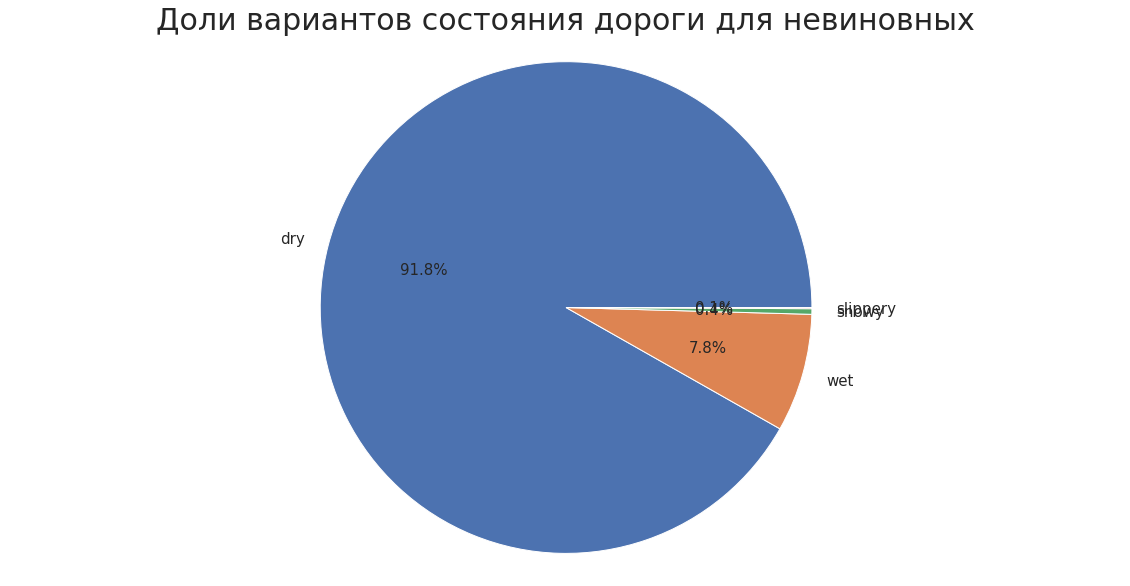

In [ ]:
# визуализируем состояние дороги
# невиновниые
dtp.query('at_fault == 0')['road_surface'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли вариантов состояния дороги для невиновных', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Здесь мы уже более четко наблюдаем, что влажная дорога повышает шанс стать виновником ДТП (например, не справившись с управлением).

Здесь мы объединим два малых состояния в одно "другие", и этим же значением заполним пропуски.

Чаще всего у автомобилей ручная коробка передач (cтолбец `'vehicle_transmission'`), с ней же виновником ДТП шансы стать выше. Так что пропуски мы заполним значением "ручная" (введение значения-заглушки ввиду малого количества пропусков не слишком рационально), а вот о информативности данного столбца будем судить после матрицы.

По долям участия в ДТП чаще попадают автомобили с типом кузова (столбец `'vehicle_type'`) "седан", с ними же шанс стать виновником выше. Второе место занимают "купе", и у них стать виновником шанс ниже. Группа "другие" крайне малочисленна.

Самым частым состоянием погоды (`'weather'`) является "ясно", что может объясняться повышенной активностью дорожного движения в хорошую погоду. В этом же состоянии шансы стать виновником ДТП ниже, чем в двух других популярных вариантах "облачно" и "дождь".

In [ ]:
# сгруппируем по состояниям
dtp['weather'].value_counts()

clear      45092
cloudy      8427
raining     2178
fog          181
snowing      157
other         34
wind          11
Name: weather, dtype: int64

Остальные состояния составляют крайне малое количество случаев, поэтому их можно объединить в одну группу "другие" (тем более, что остальные состояния также можно назвать неблагополучными, усложняющими условия вождения, в отличие от "ясно"). В эту же группу (чтобы не создавать значение-заглушку "неизвестно") поместим и пропуски.

Теперь произведем указанные выше мероприятия с данными. Начнем с устройств управления.

In [ ]:
# заменяем пропуски для устройств управления
dtp['control_device'] = dtp['control_device'].fillna("none")
# проверка на оставшиеся пропуска
dtp['control_device'].isna().sum()

0

In [ ]:
# вспоминаем варианты значений
dtp['control_device'].unique()

array(['none', 'functioning', 'not functioning', 'obscured'], dtype=object)

In [ ]:
# укрупнение
try:
    dtp['control_device'] = dtp['control_device'].replace(['none',
                                                           'obscured',
                                                          'not functioning'], 'not')
except:
    print('Замена не выполнена')

Данные сгруппированы. Перейдем к освещению.

In [ ]:
# заменяем пропуски для освещения
dtp['lighting'] = dtp['lighting'].fillna("daylight")
# проверка на оставшиеся пропуска
dtp['lighting'].isna().sum()

0

In [ ]:
# укрупнение
try:
    dtp['lighting'] = dtp['lighting'].replace(['dark with no street lights',
                                                'dark with street lights not functioning'],
                                              'dark without lights')
except:
    print('Замена не выполнена')

In [ ]:
# проверка
dtp['lighting'].unique()

array(['dark with street lights', 'daylight', 'dark without lights',
       'dusk or dawn'], dtype=object)

Удалим малоинформативный столбец.

In [ ]:
# удаляем состояние дороги
dtp = dtp.drop('road_condition', axis=1)

Поработаем с содержимым другого варианта состояния дороги.

In [ ]:
# заменяем пропуски для погодного состояния дороги
dtp['road_surface'] = dtp['road_surface'].fillna("other")
# проверка на оставшиеся пропуска
dtp['road_surface'].isna().sum()

0

In [ ]:
# укрупнение
try:
    dtp['road_surface'] = dtp['road_surface'].replace(['slippery',
                                                'snowy'],
                                              'other')
except:
    print('Замена не выполнена')

Перейдем к коробке передач.

In [ ]:
# заменяем пропуски для коробки передач
dtp['vehicle_transmission'] = dtp['vehicle_transmission'].fillna("manual")
# проверка на оставшиеся пропуска
dtp['vehicle_transmission'].isna().sum()

0

Теперь откорректируем погоду.

In [ ]:
# заменяем пропуски для устройств управления
dtp['weather'] = dtp['weather'].fillna("other")
# проверка на оставшиеся пропуска
dtp['weather'].isna().sum()

0

In [ ]:
# укрупнение
try:
    dtp['weather'] = dtp['weather'].replace(['snowing',
                                                'fog',
                                            'wind'],
                                              'other')
except:
    print('Замена не выполнена')

И теперь взглянем на наши населенные пункты. Как мы помним, их у нас большое разнообразие, поэтому прежде чем строить график, подсчитаем количество ДТП в каждом и выведем первые 20.

In [ ]:
# смотрим самые популярные города
dtp['county_location'].value_counts().head(20).reset_index()

,index,county_location
0,los angeles,16229
1,orange,5362
2,san diego,3740
3,san bernardino,3648
4,riverside,3312
5,sacramento,2184
6,alameda,1876
7,santa clara,1843
8,ventura,1463
9,kern,1415


Уже в 11-м по активности городе количество ДТП составляет чуть выше тысячи. Поэтому объединим оставшиеся, начиная от 12 и далее в группу другие, прежде чем смотреть.

In [ ]:
# укрупнение городов (берем первые 11)
# на всякий случай - в новый столбец
try:
    dtp['county_location_group'] = dtp['county_location'].\
    where(dtp['county_location'].isin(dtp['county_location'].value_counts().head(11).index), 'other')
except:
    print('Замена не выполнена')

In [ ]:
# проверка
dtp['county_location_group'].unique()

array(['san diego', 'other', 'los angeles', 'santa clara', 'orange',
       'alameda', 'kern', 'riverside', 'sacramento', 'san bernardino',
       'ventura', 'fresno'], dtype=object)

In [ ]:
# смотрим новое распределение
dtp['county_location_group'].value_counts()

los angeles       16229
other             14083
orange             5362
san diego          3740
san bernardino     3648
riverside          3312
sacramento         2184
alameda            1876
santa clara        1843
ventura            1463
kern               1415
fresno             1073
Name: county_location_group, dtype: int64

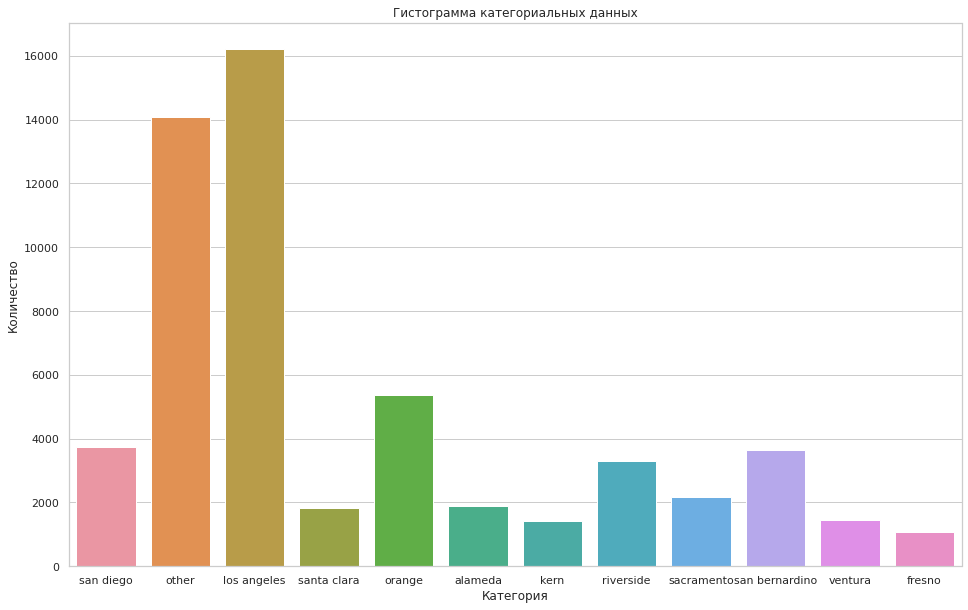

In [ ]:
# строим общий график для регионов
plt.figure(figsize=(16,10))

sns.countplot(data=dtp, x='county_location_group')

plt.title('Гистограмма категориальных данных')
plt.xlabel('Категория')
plt.ylabel('Количество')

plt.show()

Группа "other" теперь занимает второе место - что не удивительно, с учетом того, сколько городов с небольшим количеством ДТП она в себя вобрала. Возможно, это приведет к искажению данных, поэтому дополнительно взглянем на это столбец позже, в матрице корреляции, прежде чем принимать решение о его сохранении или удалении.

Теперь посмотрим на регионы по степени виновности.

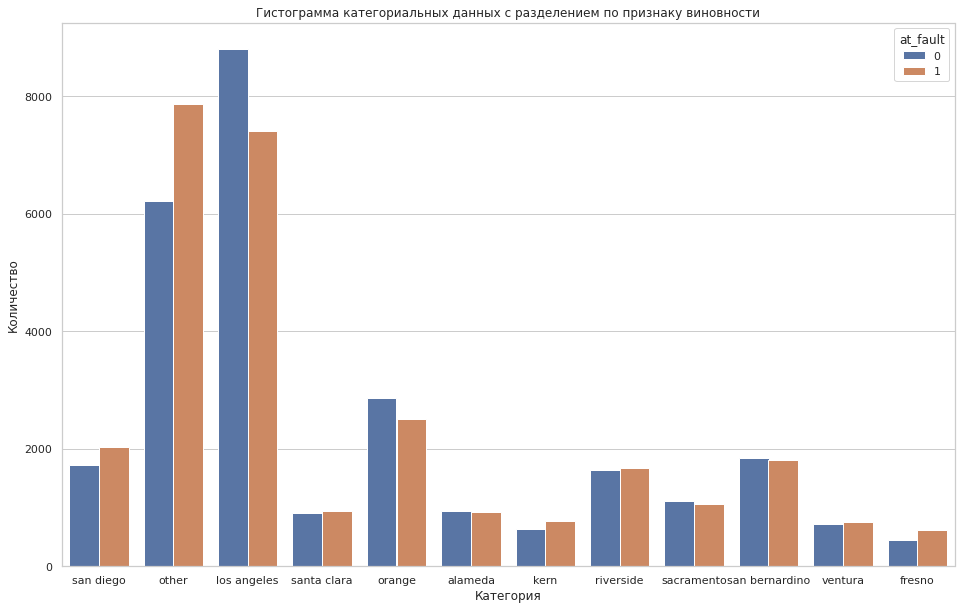

In [ ]:
# строим график для регионов в разрезе виновности
plt.figure(figsize=(16,10))

sns.countplot(data=dtp, x='county_location_group', hue='at_fault')

plt.title('Гистограмма категориальных данных с разделением по признаку виновности')
plt.xlabel('Категория')
plt.ylabel('Количество')

plt.show()

Мы можем наблюдать разное соотношение виновных и невиновных в разных городах. Больше всего виновников (по количеству, не проценту случаев) - в "других городах" (впитавших в себя разнообразие небльших городов - возможно, там хуже дорожная инфраструктура), меньший - в Лос Анжелесе. А в Аламенде шансы стать виновным и невиновным в ДТП приблизительно равны.

Теперь же, согласно требованию заказчика, удалим ответственный за трезвость признак.

In [ ]:
# удаляем
dtp = dtp.drop('party_sobriety', axis=1)

Посмотрим, что у нас получилось теперь, после всех преобразований.

In [ ]:
# смотрим пропуски и типы данных
dtp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56228 entries, 0 to 56227
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   at_fault               56228 non-null  int64  
 1   vehicle_type           56228 non-null  object 
 2   vehicle_transmission   56228 non-null  object 
 3   vehicle_age            54535 non-null  float64
 4   county_location        56228 non-null  object 
 5   weather                56228 non-null  object 
 6   road_surface           56228 non-null  object 
 7   lighting               56228 non-null  object 
 8   control_device         56228 non-null  object 
 9   month                  56228 non-null  int64  
 10  day_of_week            56228 non-null  int64  
 11  time_of_day            56228 non-null  object 
 12  county_location_group  56228 non-null  object 
dtypes: float64(1), int64(3), object(9)
memory usage: 5.6+ MB


In [ ]:
cat_col_names

['party_sobriety',
 'vehicle_type',
 'vehicle_transmission',
 'county_location',
 'weather',
 'road_surface',
 'road_condition',
 'lighting',
 'control_device',
 'time_of_day']

In [ ]:
# исправим список категориальных столбцов
# добавим новый ("без равно")
cat_col_names.append('county_location_group')
# удалим лишние
cat_col_names.remove('county_location')
cat_col_names.remove('road_condition')
cat_col_names.remove('party_sobriety')
cat_col_names # проверяем

['vehicle_type',
 'vehicle_transmission',
 'weather',
 'road_surface',
 'lighting',
 'control_device',
 'time_of_day',
 'county_location_group']

In [ ]:
# применяем функцию uniq, чтобы посмотреть на уникальные значения
uniq(dtp, cat_col_names)

Количество уникальных значений в столбце vehicle_type: 3
Уникальные значения столбца vehicle_type: 
['coupe' 'other' 'sedan']

Количество уникальных значений в столбце vehicle_transmission: 2
Уникальные значения столбца vehicle_transmission: 
['auto' 'manual']

Количество уникальных значений в столбце weather: 4
Уникальные значения столбца weather: 
['clear' 'cloudy' 'other' 'raining']

Количество уникальных значений в столбце road_surface: 3
Уникальные значения столбца road_surface: 
['dry' 'other' 'wet']

Количество уникальных значений в столбце lighting: 4
Уникальные значения столбца lighting: 
['dark with street lights' 'dark without lights' 'daylight' 'dusk or dawn']

Количество уникальных значений в столбце control_device: 2
Уникальные значения столбца control_device: 
['functioning' 'not']

Количество уникальных значений в столбце time_of_day: 4
Уникальные значения столбца time_of_day: 
['day' 'evening' 'morning' 'night']

Количество уникальных значений в столбце county_location

Мы избавились от малоинформативного столбца, заполнили пропуски, сгруппировали данные (уменьшив количество уникальных вариантов значений) и привели в порядок их типы данных.

Теперь можно построить матрицу корреляции, чтобы отобрать наиболее подходящие для построения модели.

**Выводы**

Был произведен исследовательский анализ. Он установил, что:
- в целом, у нас автомобилей более молодых больше, чем возрастных, и больше всего - трехлетних (это может быть из-за структуры автопарка, которая нам неизвестна);
- большое количество ДТП до мая включительно, а затем - резкое их падение в июне, и сильное сокрашение в оставшиеся месяцы (что мы могли наблюдать ранее);
- наибольшее количество ДТП происходит в пятницу и субботу, и также много (хоть и ниже ранее указанных дней) - в воскресенье. Возможно, это связано с состоянием усталости либо употреблением алкоголя в данные дни (с вечера пятницы и до утра воскресенья, а в само воскресенье алкоголь мог не успеть выветриться). Плюс в пятницу у некоторых организаций сокращенный день, потому сам трафик может возрасти.
- наиболее низкий уровень ДТП - в понедельник, возможно что после выходных меньше усталости и к данному моменту алкоголь у употреблявших уже выводится из организма. Плюс, у некоторых организаций понедельник является выходным днем, что может приводит к снижению общего уровня активности.
- большинство ДТП приходится на день, меньше всего случается ночью.
-  что основная часть (почти 88%) участников были трезвыми. Лишь 8% из них были пьяны и находились под влиянием алкоголя. Остальные состояния занимают от около двух и менее процентов.
- состояния, связанные с алкогольным опьянением, повышают вероятность стать виновником ДТП.
- чаще всего устройства управления у автомобилей отсутствуют.
- шансы попасть в ДТП при дневном свете выше (возможно, ввиду более активного трафика).
- самые активные города - Лос Анжелес и Оранж (возможно, ввиду повышенной активности дорожного движения в них), причем вероятность стать виновником в них ниже, чем стать.
- наиболее характерное состояния дороги для столбца `'road_condition'` является "нормально".
- больше всего ДТП происходит на сухой дороге (возможно ввиду более активного трафика в хорошую погоду или климатических условий), второе место занимает влажная (ввиду ухудшения условий вождения или климатичесиких условий - хорошая погода случается чаще).
- по долям участия в ДТП чаще попадают автомобили с типом кузова (столбец `'vehicle_type'`) "седан", второе место занимают "купе", группа "другие" крайне малочисленна. Либо такова структура автопарка, либо как-то связано с качеством определенных автомобилей.
- самая популярная погода для ДТП - "ясно" (что может объясняться повышенной активностью дорожного движения в хорошую погоду), также популярны "облачно" и "дождь" (ввиду ухудшений условий и, возможно, климатических условий). Остальные варианты занимают малую долю (возможно ввиду климатических условий).

Причины указанного поведения некоторых столбцов требуют дополнительного уточнения и/или изучения, но уже не в рамках данного исследования.

Также были произведены удаление и замены пропусков в данных различным образом на основании полученной в результате исследования информации, удалены малоинформативные столбцы.

Дополнительно мы изучили данные в разрезе целевого признака и дополнили портрет виновника:
- чаще всего виновниками ДТП становятся автомобили с двух до четырех лет включительно, а самые "опасные" - трехлетние (возможно, связано со структурой автопарка);
- в разные дни вероятности стать виновником разные. Самый контраст представляют собой близкие по общему количеству, но разные по структуре виновности пятница (когда шансы стать виновником выше) и суббота (когда стать виновником шансов меньше), возможно ввиду разного состояния участников (пятничное повышение - ввиду накопления недельной усталости либо употребления алкоголя; а субботнее снижение объясняется улучшением состония участника к этому моменту, что может быть также применимо и к воскресенью).
- состояния, связанные с употреблением алкоголя, повышают вероятность стать виновником ДТП (например, ухудшение реакций).
- шансы стать виновником в понедельник не зависят от состояний трезвости. В дни же с пятницу по субботу связанные с употреблением алкоголя состояния повышают этот шанс (причем вариантов разнообразия связанных с употреблением алкоголя в субботу и воскресенье у виновников выше, чем в пятницу).
- шансы стать виновником ночью выше всего, а днем же минимальная. Это может быть связано с с состоянием участника (сонливость, усталость), а также ухудшением видимости ночью.
- связь между виновностью, состоянием трезвости и временем суток установить проблематично. Лишь те, кто не оценивался, чаще не являются виновниками в любое время суток.
- наличие устройства управления снижает риск стать виновником ДТП (возможно, его наличие упрощает управление и ускоряет реакцию).
- стать виновником ДТП в Сан Диего и "других" выше, чем в Лос Анжелесе и Оранже (возможно, особенности дорожной структуры или климатических условий). А в Аламенде шансы стать виновным и невиновным в ДТП приблизительно равны. Больше всего виновников (по количеству) - в "других городах" (впитавших в себя разнообразие небольших городов - возможно, там хуже дорожная инфраструктура).
- шансы стать виновником ДТП в темноте различного рода и при риске темноты выше, чем при дневном свете (возможно, ввиду ухудшение условий вождения).
- состояние дороги из столбца `'road_condition'` не выявило влияние на виновность в ДТП.
- на влажной дороге шансов стать виновником ДТП больше (возможно, ввиду ухудшение условий вождения).
- автомобили с кузовом "седан" чаще становятся виновниками ДТП, чем "купе" (возможно, связано со структурой автопарка).
- шансы стать виновником ДТП в облачную или дождливую погоду выше, чем в ясную (возможно, ввиду ухудшение условий вождения).

Причины указанного поведения некоторых столбцов требуют дополнительного уточнения и/или изучения, но уже не в рамках данного исследования.

#### Матрица корреляции

Теперь, когда мы поработали с данными, можно посмотреть на мтрицу корреляции.

Так как неприрывные признаки у нас отсутствуют (а часть выраженных числами на самом деле - категории), то задавать нам в данном параметре нечего.

Столбец с географическими признаками пратически не показывают связи с остальными (особенно - с интересующим нас целевыми), самая высокая из которых - между собой (что логично), и умереная - с состоянием дороги.

В принципе, у нас не так много данных, которые дают между собой хорошую зависимость, а уж с интересующим нас признаком она не поднимается выше 0.19. Что говорит о том, что модели будет очень сложно научиться правильно предсказывать результат.

Ввиду этого также не будем удалять оставшиеся признаки (за исключением дублирующего). Исходный столбец с локациями большинстве случаев дает лучшую корреляцию с остальныи столбцами, но содержит очень много значений, поэтому в работу брать его не будем.

Удалим данный признак.

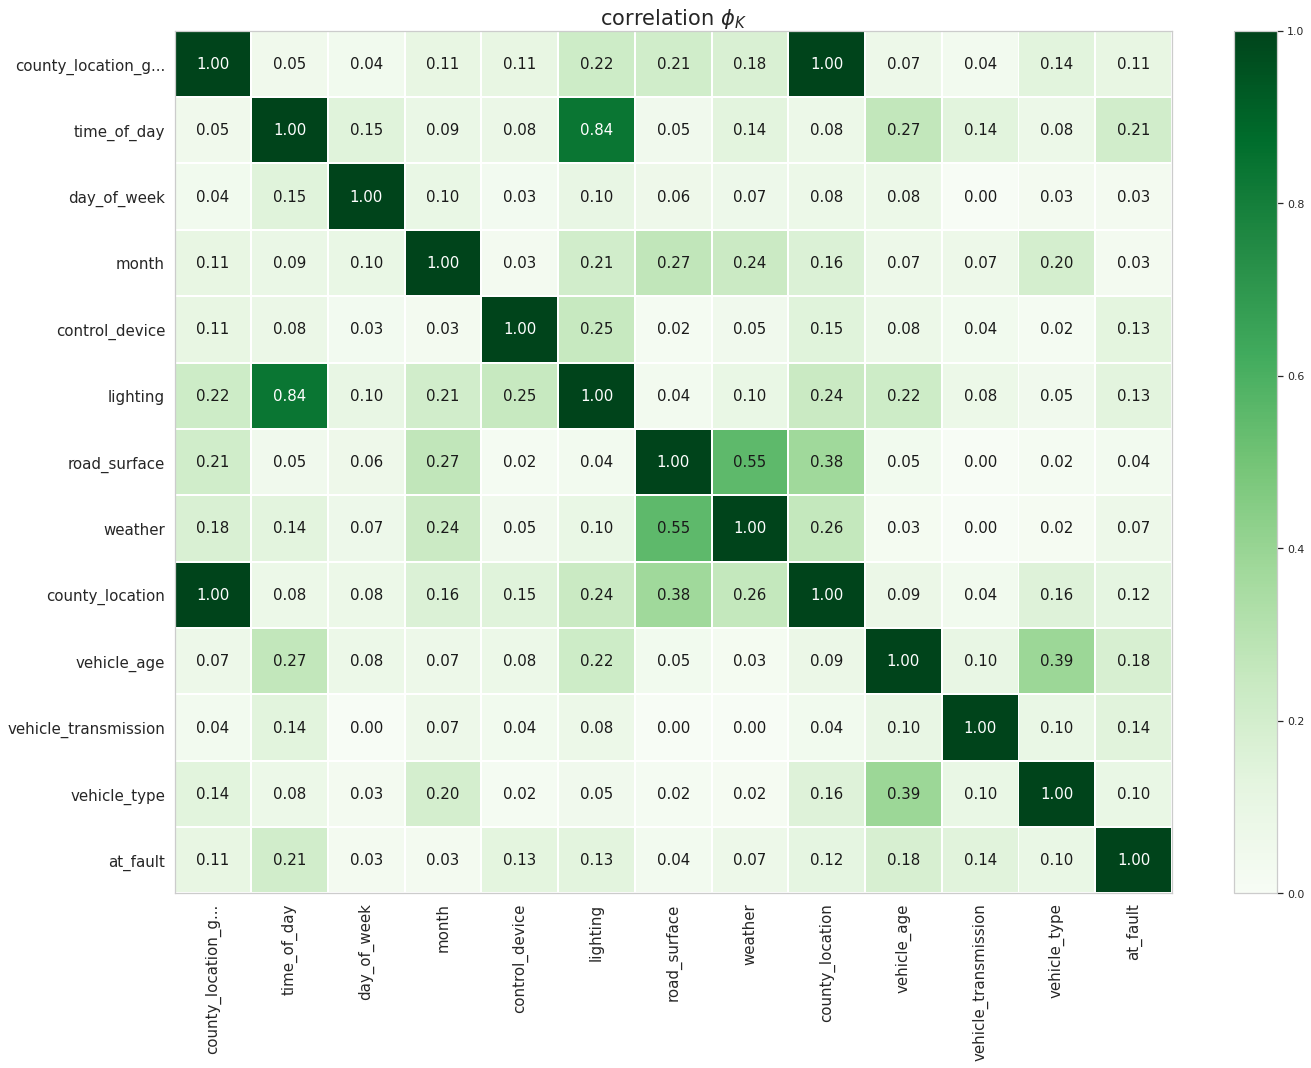

In [ ]:
# неприрывные значения - исправленное
interval_cols = []

# считаем корреляции
phik_overview = dtp.phik_matrix(interval_cols=interval_cols)

# матрица корреляции 2
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
)

Столбец с географическими признаками практически везде показывают слабые связи различной степени с остальными, самая высокая из которых - между собой (что логично), и умереная - с "погодного варианта" дорожного состояния (возможно, климатические особенности).

Мы можем заметить высокую корреляцию между временем суток и освещением (что логично). Также заметная связь у погоды и "погодного варианта" дорожного состояния.

В принципе, у нас не так много данных, которые дают между собой хорошую зависимость, а уж с интересующим нас признаком она не поднимается выше 0.21 для части суток. Что говорит о том, что модели будет очень сложно научиться правильно предсказывать результат.

Ввиду этого также не будем удалять оставшиеся признаки (за исключением дублирующего). Исходный столбец с локациями большинстве случаев дает лучшую корреляцию с остальныи столбцами, но содержит очень много значений, поэтому в работу брать его не будем.

Удалим данный признак.

In [ ]:
# удаляем
dtp = dtp.drop('county_location', axis = 1)
dtp.columns

Index(['at_fault', 'vehicle_type', 'vehicle_transmission', 'vehicle_age',
       'weather', 'road_surface', 'lighting', 'control_device', 'month',
       'day_of_week', 'time_of_day', 'county_location_group'],
      dtype='object')

**Выводы**

- Матрица корреляция выявила в большинстве случаев слабые взаимосвязи между признаками или вовсе их отсутствие.
- Самая тесная связь между признаками - у освещенности и времени суток.
- Также заметная связь у погоды и "погодного варианта" дорожного состояния.
- Связь признаков с целевым также невелика (максимум составил 0.21 для времени суток).

## Работа с моделями

Согласно условиям проекта, мы должны cмоделировать не менее 3-х типов моделей с перебором гиперпараметров. Так как у нас низкая корреляция между признаками и большое их разнообразие даже после упорядочивания, есть соблазн отказаться от линейных моделей в пользу моделей, основанных на деревьях решений. Но в качестве эксперимента все-таки попробуем.

Модели, которые мы будем использовать:
- LogisticRegression;
- RandomForestClassifier;
- LGBMClassifier;
- CatBoost.

Каждая из моделей требует свои условия подготовки данных, что удобнее всего будет делать через пайплайн.

### Выбор метрики

Прежде чем работать с моделями, нам необходимо определиться, какую метрику стоит использовать.

В данном случае, перед нами - задача классификации (мы должны определить, станит участник виновником, или нет). Здесь нас могут ожидать несколько видов ошибок, которые могу нас заинтересовать:
- ошибочное отнесение класса 1 в класс 0 (ошибка второго рода, она же ложноотрицательный результат). Такаие ошибки приводят к непредотвращенной аварии, которая может принести как вред здоровью участников, так и финансовому вреду и прочим издержкам в репутации (например, если компания, которая будет рекламировать себя как та, что использует высокие технологии для того, чтобы обезопасить своих клиентов, будет часто упускать такие случаи).
- ошибочное отнесение класса 0 в класс 1 (ошибка первого рода, она же ложноположительный результат). Такие ошибки могут привести к тому, что повысится процент ошибочных отказов, что может снизить количество клиентов.

Так как ошибки второго рода выглядят более весомыми с точки зрения "цены ошибки", выберем главной метрикой качества F1-меру (F1-score). Она которая учитывает как точность, так и полноту модели, рассчитываясь как гармоническое среднее между точностью (precision) и полнотой (recall). В свою очередь точность (precision) показывает, насколько модель точна в предсказании положительного класса, а полнота (recall) отражает способность модели находить все положительные случаи.

Но также можно использовать взятую из библиотеки scikit-learn функцию classification_report для генерации отчёта по классификации, который включает такие метрики, как точность (precision), полнота (recall), F1-мера и поддержка (количество экземпляров каждого класса) для каждого класса. Также она выводит weighted avg, который в контексте функции classification_report из библиотеки scikit-learn обозначает взвешенное среднее значение метрик (таких как точность, полнота, F1-мера) по всем классам.

Взвешенное среднее (weighted avg) в свою очередь учитывает размер каждого класса в тестовом наборе данных, что позволяет получить более точное представление о производительности модели на всём наборе данных, особенно в случае несбалансированных классов.

Метрика support в контексте описываемой функции обозначает количество экземпляров каждого класса в тестовом наборе данных. Эта метрика показывает, сколько объектов было использовано для вычисления метрик точности, полноты и F1-меры для каждого класса. Она помогает понять, насколько сбалансирован набор данных по отношению к различным классам, и может быть полезен для интерпретации значений других метрик, особенно в случае несбалансированных данных. Например, если для какого-то класса значение support значительно меньше, чем для других, это может указывать на то, что модель может быть менее надёжной при классификации объектов этого класса.

Таким образом мы сможем дополнительно посмотреть и прочие характеристики качества моделей.

**Выводы**

Лучше всего нашим запросам отвечает метрика f1, на нее мы и будем ориентироваться при обучении моделей.

### Разбиение на выборки и дообработка

Для начала освежим наши списки признаков.

In [ ]:
# вспоминаем оставшиеся признаки и наличие пропусков
dtp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56228 entries, 0 to 56227
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   at_fault               56228 non-null  int64  
 1   vehicle_type           56228 non-null  object 
 2   vehicle_transmission   56228 non-null  object 
 3   vehicle_age            54535 non-null  float64
 4   weather                56228 non-null  object 
 5   road_surface           56228 non-null  object 
 6   lighting               56228 non-null  object 
 7   control_device         56228 non-null  object 
 8   month                  56228 non-null  int64  
 9   day_of_week            56228 non-null  int64  
 10  time_of_day            56228 non-null  object 
 11  county_location_group  56228 non-null  object 
dtypes: float64(1), int64(3), object(8)
memory usage: 5.1+ MB


In [ ]:
# вспоминаем целевой
target

'at_fault'

In [ ]:
# смотрим списки признаков - числовые
num_col_names

['vehicle_age', 'month', 'day_of_week']

На самом деле числовой у нас тут только возраст автомобиля. Остальные же на самом деле - категориальные, хоть и выражены числами.

Исправим это.

In [ ]:
# пересоздаем список числовых
num_col_names = ['vehicle_age']
num_col_names

['vehicle_age']

In [ ]:
# смотрим списки признаков - категориальные
cat_col_names

['vehicle_type',
 'vehicle_transmission',
 'weather',
 'road_surface',
 'lighting',
 'control_device',
 'time_of_day',
 'county_location_group']

In [ ]:
# обновляем список
# вариант 1 - пересоздание, чтобы не упустить признаки
cat_col_names = dtp.drop(num_col_names + [target], axis=1).columns.tolist()
cat_col_names

['vehicle_type',
 'vehicle_transmission',
 'weather',
 'road_surface',
 'lighting',
 'control_device',
 'month',
 'day_of_week',
 'time_of_day',
 'county_location_group']

Также изменим типы данных столбцов (кроме возраста авто, так как в нем-пропуски).

In [ ]:
# меняем
dtp = dtp.astype({
    **{_:'int' for _ in num_col_names if _ != 'vehicle_age'}, # исключаем
    **{_:'category' for _ in cat_col_names}
})

In [ ]:
# проверяем
dtp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56228 entries, 0 to 56227
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   at_fault               56228 non-null  int64   
 1   vehicle_type           56228 non-null  category
 2   vehicle_transmission   56228 non-null  category
 3   vehicle_age            54535 non-null  float64 
 4   weather                56228 non-null  category
 5   road_surface           56228 non-null  category
 6   lighting               56228 non-null  category
 7   control_device         56228 non-null  category
 8   month                  56228 non-null  category
 9   day_of_week            56228 non-null  category
 10  time_of_day            56228 non-null  category
 11  county_location_group  56228 non-null  category
dtypes: category(10), float64(1), int64(1)
memory usage: 1.4 MB


Останется лишь удалить аномалии и заполнить пропуски уже после разбиения.

CatBoost не требует дополнительной подготовки данных сверх того, что мы уже провели. LightGBM - зависит от того, к какому типу данных (`object` или `category`) относятся столбцы с категориальными данными, но в целом в кодировании тоже не слишком нуждается. А вот для RandomForestClassifier точно понадобится перевод категориальных данных в числовые значения (можно через ORD, так как деревья не чувствительны к порядку чисел, главное - перевести категории  в числа, которые модель уже сможет понимать). Для LogisticRegression потребуется также масштабировние числовых, а вот категориальные придется кодировать через OHE.

Прежде, чем провести кодирование, следует разбить наши данные на выборки. Так как мы будем использовать кросс-валидацию, нам будет достаточно тренировочной и тестовой.

Ввиду того, что разные модели имеют разные требования к категориальным данным (одни могут справится с ними без кодирования, другие - нет), но нам потребуется несколько "комплектов" выборок (с кодировкой и без). Чтобы все модели работали с одними и теми же данными, произведем одно разбиение, а вот дальше будем использовать пайплайны.

In [ ]:
# функция подготовки данных перед подбором моделей и их параметров
# вариант 1 (модифицированный)
def data_preprocessing(data, target_name):

    # Перемешивание объектов
    # для их лучшего распределения в выборках
    data = shuffle(data, random_state=RANDOM_STATE)

    # Разделение датафреймов на целевую и нецелевую выборку
    features = data.drop([target_name], axis=1)
    target = data[target_name]

    # Разделение целевой и нецелевой выборки
    # на обучающие и тестовые выборки
    X_train,  X_test, y_train, y_test = train_test_split(
        features,
        target,
        shuffle = True, # перемешивание, больше нужно для задач классификации
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=data[target_name] # стратификация по указанному признаку
    )

    return X_train, X_test, y_train, y_test

In [ ]:
# Разделение обучающего датафрейма на целевую и тестовую выборку
X_train, X_test, y_train, y_test = data_preprocessing(dtp, target)

In [ ]:
# проверка разбиения по количеству
print(color.BLUE + color.BOLD + f"Размер X_train: "\
      + color.END + f"{X_train.shape}")
print(color.BLUE + color.BOLD + f"Размер X_test: "\
      + color.END + f"{X_test.shape}")
print(color.BLUE + color.BOLD + f"Размер y_train: "\
      + color.END + f"{y_train.shape}")
print(color.BLUE + color.BOLD + f"Размер y_test: "\
      + color.END + f"{y_test.shape}")

Размер X_train: (42171, 11)
Размер X_test: (14057, 11)
Размер y_train: (42171,)
Размер y_test: (14057,)


In [ ]:
# проверка разбиения по долям
print(color.BLUE + color.BOLD + f'Доля тренировочных признаков: '\
      + color.END + f'{X_train.shape[0]/df.shape[0]:.2f}')
print(color.BLUE + color.BOLD + f'Доля тренировочных целей: '\
      + color.END + f'{y_train.shape[0]/df.shape[0]:.2f}')
print(color.BLUE + color.BOLD + f'Доля тестовых признаков: '\
      + color.END + f'{X_test.shape[0]/df.shape[0]:.2f}')
print(color.BLUE + color.BOLD + f'Доля тестовых целей: '\
      + color.END + f'{y_test.shape[0]/df.shape[0]:.2f}')
print(color.BLUE + color.BOLD + f'Доля положительных целей на тренировочных данных: '\
     + color.END + f'{y_train.astype("int").mean():.2f}')
print(color.BLUE + color.BOLD + f'Доля положительных целей на тестовых данных: '\
      + color.END + f'{y_test.astype("int").mean():.2f}')

Доля тренировочных признаков: 2108.55
Доля тренировочных целей: 2108.55
Доля тестовых признаков: 702.85
Доля тестовых целей: 702.85
Доля положительных целей на тренировочных данных: 0.50
Доля положительных целей на тестовых данных: 0.50


Разбиение прошло равномерно.

Теперь вернемся к нашим аномалиям и пропускам в столбце с возрастом авто.

In [ ]:
# выведем максимальное значение возраста
X_train['vehicle_age'].max()

161.0

In [ ]:
# пересохраняем выборку без указанных строк
# без сброса индексов, чтобы не испортить соответствие целевому признаку
X_train = X_train[X_train['vehicle_age'] != 161]
X_train['vehicle_age'].max() #проверка

19.0

In [ ]:
# новый размер выборки
X_train.shape

(42169, 11)

Теперь нужно исключить удаленные строки из целевого признака.

In [ ]:
# перезаписываем целевой признак без удаленных строк
# сохранив строки только совпадающие с оставшимися у тренировочных данных индексами
y_train = y_train.loc[X_train.index]
y_train.shape  # новый размер

(42169,)

Размеры тренировочной выборки и ее целевого признака совпали.

Перейдем к пропускам

In [ ]:
# смотрим содержимое тренировочной выборки
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 42169 entries, 47677 to 33868
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   vehicle_type           42169 non-null  category
 1   vehicle_transmission   42169 non-null  category
 2   vehicle_age            40907 non-null  float64 
 3   weather                42169 non-null  category
 4   road_surface           42169 non-null  category
 5   lighting               42169 non-null  category
 6   control_device         42169 non-null  category
 7   month                  42169 non-null  category
 8   day_of_week            42169 non-null  category
 9   time_of_day            42169 non-null  category
 10  county_location_group  42169 non-null  category
dtypes: category(10), float64(1)
memory usage: 1.0 MB


У нас остались пропуска также лишь в возрасте. Заполним их медианой.

In [ ]:
# считаем исходное количество пропусков
print(color.BLUE + color.BOLD + f"Количество пропусков в столбце 'vehicle_age': "
              + color.END + f"{X_train['vehicle_age'].isna().sum()}")

Количество пропусков в столбце 'vehicle_age': 1262


In [ ]:
# заменяем пропуска на медиану с перезаписью "на месте"
X_train['vehicle_age'].fillna(X_train['vehicle_age'].median(), inplace=True)
# проверка на оставшиеся пропуска
X_train['vehicle_age'].isna().sum()

0

In [ ]:
# меняем тип
X_train['vehicle_age'] = X_train['vehicle_age'].astype(int)
X_train['vehicle_age'].dtype

dtype('int64')

Теперь заполним пропуски тестовой выборки медианой тренировочной.

In [ ]:
# повторяем на тестовых, беря медиану тренировочных
# считаем исходное количество пропусков
print(color.BLUE + color.BOLD + f"Количество пропусков в столбце 'vehicle_age': "
              + color.END + f"{X_test['vehicle_age'].isna().sum()}")

Количество пропусков в столбце 'vehicle_age': 431


In [ ]:
# заменяем пропуска на медиану с перезаписью "на месте"
X_test['vehicle_age'].fillna(X_train['vehicle_age'].median(), inplace=True)
# проверка на оставшиеся пропуска
X_test['vehicle_age'].isna().sum()

0

In [ ]:
# меняем тип
X_test['vehicle_age'] = X_test['vehicle_age'].astype(int)
X_test['vehicle_age'].dtype

dtype('int64')

**Выводы**

- Мы освежили списки наших параметров и разбили данные на выборки.
- Закончили работу с пропусками и аномалиями для возраста авто.

### **DummyClassifier**

In [ ]:
# создаем словарь для автоматического наполнения
models_dict = {}

In [ ]:
%%time
model_dc = DummyClassifier(strategy='most_frequent')
model_dc.fit(X_train, y_train)  # тренируем

CPU times: user 1.95 ms, sys: 175 µs, total: 2.12 ms
Wall time: 1.79 ms


DummyClassifier(strategy='most_frequent')

In [ ]:
# делаем предсказания и вычисляем F1-score
prediction_dc = model_dc.predict(X_train)
f1_dc = f1_score(y_train, prediction_dc)

In [ ]:
# Добавляем в словарь
models_dict['Dummy Classifier'] = {
    'params': {'strategy': 'most_frequent'},
    'f1_score': round(f1_dc, 4)
}
round(f1_dc, 4) #визуализация метрики

0.6707

In [ ]:
# проверяем словарь
pd.DataFrame.from_dict(models_dict, orient = 'index')

,params,f1_score
Dummy Classifier,{'strategy': 'most_frequent'},0.67


**Вывод**

Мы обучили базовую модель для будущего сравнения, ее метрика f1 составила всего 0.67

### **LogisticRegression**

Работа с данной моделью тебует больше всего подготовки: и кодирование, и масштабирование. Сделать это удобнее через пайплайн. Для этого создадим трансформер для различных столбцов: так как модель у нас линейная, то к категориальным применим OHE, а к числовым - StandardScaler.

А саму модель со всеми настройками и подготовками можно упаковать в функцию. Так как сама по себе модель логистической классификации - не лучший выбор, применим GridSearchCV, чтобы с большим шансом (хоть и за большее время) найти лучшие параметры.

In [ ]:
# функция с моделью логистической регрессии
# вместе с подготовкой данных и перебором параметров
# с сохранением лучшей модели, ее параметров и метрики в свой словарь

def Logistic_Regression(X_train, y_train):

    # Подготовка признаков для линейной классификации
    # преобразуем данные согласно их типу
    linear_transformer = make_column_transformer(
        (
            OneHotEncoder(
                # кодирует категориальные переменные в тип данных uint8,
                # который представляет собой 8-битное целое число без знака
                # используется для оптимизации хранения массивов закодированных через OHE категориальных переменных
                dtype='uint8',
                drop='first', # избегаем дамми-ловушки
                handle_unknown='ignore', # неизвестные значения игнорируем
                # и чтобы результаты кодирования можно было визуально увидеть - не сохраняем его в sparce-формате
                sparse_output=False # _output для версии sklearn 1.5.2
            ), make_column_selector(dtype_include=['category', 'object']) # выбираемые типы данных
        ),
        (
            StandardScaler(),
            make_column_selector(dtype_include='number') # выбираемые типы данных
        ),
        remainder='passthrough' # пропустить неизвестные значения
    )

    # Создание пайплайна
    pipe_lr = make_pipeline(
        linear_transformer, # трансформатор данных
        LogisticRegression( # модель
            # автоматически вычисляет веса классов обратно пропорциональными их частотам в обучающей выборке
            # в текущей задаче может быть не обязательно
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1 # все ядра
        )
    )

    # Определение сетки гиперпараметров
    param_grid = [
        # во избежание ошибок совместимости с регуляризацией в обучении пришлось разделить прописывать для каждой
        {
        'logisticregression__penalty': ['l1', 'l2'],# тип регуляризации (L1 или L2)
        'logisticregression__C': [0.01, 0.1, 1], # обратная сила регуляризации
        'logisticregression__solver': ['liblinear'], # алгоритм оптимизации,
         'logisticregression__max_iter': [25, 50] # максимальное количество итераций
    },
    {
        'logisticregression__penalty': [None, 'l1', 'l2'],
        'logisticregression__C': [0.01, 0.1, 1],
        'logisticregression__solver': ['saga'],
        'logisticregression__max_iter': [25, 50] # максимальное количество итераций
    }

    ]

    # Создание GridSearchCV
    grid_search = GridSearchCV(
        estimator=pipe_lr,  # Используем только пайплайн
        param_grid=param_grid, # параметры
        cv=5, # количество фолдов
        scoring='f1', # метрика
        refit=True, # переобучить лучшую модель на всех данных
        #verbose=0, # отключаем вывод
        verbose=1 , # не отключаем вывод
        n_jobs=-1 # все ядра
    )

    # Обучение модели
    grid_search.fit(X_train, y_train)

    # Получение лучшей модели
    # Получение результатов
    best_model = grid_search.best_estimator_
    best_f1 = grid_search.best_score_
    best_params = grid_search.best_params_

    print(color.BLUE + color.BOLD + f"\n Лучшая F1-мера на кросс-валидации: "\
     + color.END + f"{best_f1:.4f}")
    print(color.BLUE + color.BOLD + f"Лучшие параметры: "\
     + color.END + f"{grid_search.best_params_}\n")

      # Возвращаем словарь с моделью и дополнительной информацией
    return {
        'model': best_model,
        'best_score': best_f1,
        'best_params': best_params,
        'grid_search': grid_search  # если нужно сохранить объект GridSearchCV
    }

In [ ]:
# тренируем модель
# Вызов функции и сохранение результатов
%time result_lc = Logistic_Regression(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the co


 Лучшая F1-мера на кросс-валидации: 0.5883
Лучшие параметры: {'logisticregression__C': 0.01, 'logisticregression__max_iter': 25, 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'saga'}

CPU times: user 1min 51s, sys: 12 s, total: 2min 3s
Wall time: 2min 3s


Модель получена и сохранена. И метрика у нее хуже, чем у базовой.

Пополним наш словарь

In [ ]:
# Добавляем в словарь
models_dict['LogisticRegression'] = {
    'params': result_lc['best_params'],
    'f1_score': round(result_lc['best_score'], 4)
}

In [ ]:
# проверяем словарь
pd.DataFrame.from_dict(models_dict, orient = 'index')

,params,f1_score
Dummy Classifier,{'strategy': 'most_frequent'},0.67
LogisticRegression,"{'logisticregression__C': 0.01, 'logisticregression__max_iter': 25, 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'saga'}",0.59


**Вывод**

Мы обучили модель Линейной классификации. Ее результат оказался неидеален, и хуже, чем у базовой, метрика f1 составив всего 0.58.

### **RandomForestClassifier**

Также произведем обучение через функцию.

При создании трансформера для различных столбцов учтем, что так как у нас модель на основе принципа дерева решений, то к категориальным применим ORD, числовые же преобразовывать уже не требуется.

In [ ]:
# функция с моделью случайного леса
# вместе с подготовкой данных и перебором параметров
# с сохранением лучшей модели, ее параметров и метрики в свой словарь

def Random_Forest_Classifier(X_train, y_train):

    # Подготовка признаков для дерева решений
    # преобразуем данные согласно их типу
    ensemble_transformer = make_column_transformer(
    (
        OrdinalEncoder(
            dtype='int16', #  кодирует категориальные переменные в 16-битные целые числа
            handle_unknown='use_encoded_value', # определяет, как обрабатывать неизвестные категории
            unknown_value=-1 # присваивает значение -1 неизвестным категориям
        ), make_column_selector(dtype_include=['category', 'object']) # типы, к которым применяем
    ),
    remainder='passthrough' # пропустить неизвестные значения
    )

    # Создание пайплайна
    pipe_rf = make_pipeline(
    ensemble_transformer,
    RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1, # все ядра
         # автоматически вычисляет веса классов обратно пропорциональными их частотам в обучающей выборке
        # в текущей задаче может быть не обязательно, но лучше подстаховаться, так дисбаланс все же есть
        class_weight='balanced',
        verbose=0 # отключаем вывод информации
    )
    )


    """
    n_estimators: Количество деревьев в лесу.
    Большее значение может улучшить точность, но увеличит время обучения.
    """

    # Сетка гиперпараметров
    param_grid_rf = {
        'randomforestclassifier__n_estimators': [10, 25, 50],            # количество деревьев в лесу
        'randomforestclassifier__criterion': ['gini', 'entropy'], # критерий для разбиения (индекс Джини или энтропия)
        'randomforestclassifier__max_depth': [10, 25, 50],     # максимальная глубина дерева
        'randomforestclassifier__min_samples_split': [5, 10],         # минимальное число примеров для разбиения узла
        'randomforestclassifier__min_samples_leaf': [2, 4],           # минимальное число примеров в листе
        # сколько признаков будет рассматриваться при разбиении узла в дереве
        #'randomforestclassifier__max_features': ['sqrt', 'log2']
    }

    # Создание экземпляра GridSearchCV для Случайного леса
    grid_search_rf = GridSearchCV(
                    estimator=pipe_rf,  # Используем только пайплайн
                    param_grid=param_grid_rf, # параметры
                    cv=5, # количество фолдов, сократили для ускорения
                    scoring='f1', # метрика
                    refit=True, # переобучить лучшую модель на всех данных
                    #verbose=0, # отключаем вывод
                    verbose=1 , # не отключаем вывод
                    n_jobs=-1 # все ядра
                        )

    # Обучение на обучающей выборке с перебором всех комбинаций гиперпараметров
    grid_search_rf.fit(X_train, y_train)

    # Получение лучшей модели Случайного леса с оптимальными гиперпараметрами
    best_model_rf = grid_search_rf.best_estimator_

    # Ее параметры
    best_params = grid_search_rf.best_params_

    # Лучшая оценка (метрика f1) на валидационных данных
    best_f1 = grid_search_rf.best_score_

    print(color.BLUE + color.BOLD + f"\n Лучшая оценка на валидационных данных (F1-мера): "\
          + color.END + f"{best_f1:.4f}")
    print(color.BLUE + color.BOLD + f"Лучшие параметры: "\
     + color.END + f"{best_params}\n")

      # Возвращаем словарь с моделью и дополнительной информацией
    return {
        'model': best_model_rf,
        'best_score': best_f1,
        'best_params': best_params,
        'grid_search': grid_search_rf  # если нужно сохранить объект GridSearchCV
    }

In [ ]:
# тренируем модель
# Вызов функции и сохранение результатов
%time result_rf = Random_Forest_Classifier(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits

 Лучшая оценка на валидационных данных (F1-мера): 0.5891
Лучшие параметры: {'randomforestclassifier__criterion': 'entropy', 'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_leaf': 2, 'randomforestclassifier__min_samples_split': 10, 'randomforestclassifier__n_estimators': 50}

CPU times: user 4min 4s, sys: 175 ms, total: 4min 4s
Wall time: 4min 6s


Модель получена и сохранена. И метрика у нее тоже хуже, чем у базовой.

Пополним наш словарь

In [ ]:
# Добавляем в словарь
models_dict['RandomForestClassifier'] = {
    'params': result_rf['best_params'],
    'f1_score': round(result_rf['best_score'], 4)
}

In [ ]:
# проверяем словарь
pd.DataFrame.from_dict(models_dict, orient = 'index')

,params,f1_score
Dummy Classifier,{'strategy': 'most_frequent'},0.67
LogisticRegression,"{'logisticregression__C': 0.01, 'logisticregression__max_iter': 25, 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'saga'}",0.59
RandomForestClassifier,"{'randomforestclassifier__criterion': 'entropy', 'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_leaf': 2, 'randomforestclassifier__min_samples_split': 10, 'randomforestclassifier__n_estimators': 50}",0.59


**Вывод**

Мы обучили модель Случайного леса. Ее результат оказался практически такой же, как у Линейной регресии (метрика f1 составила 0.5860 против 0.5861), и также хуже, чем у базовой.

### **LGBMClassifier**

Для данной модели используем ту же подготовку признаков, что и для предыдущей.

In [ ]:
# функция с моделью LGBMClassifier
# вместе с подготовкой данных и перебором параметров
# с сохранением лучшей модели, ее параметров и метрики в свой словарь

def LGBM_Classifier(X_train, y_train):

    # Подготовка признаков для дерева решений
    # преобразуем данные согласно их типу
    ensemble_transformer = make_column_transformer(
    (
        OrdinalEncoder(
            dtype='int16', #  кодирует категориальные переменные в 16-битные целые числа
            handle_unknown='use_encoded_value', # определяет, как обрабатывать неизвестные категории
            unknown_value=-1 # присваивает значение -1 неизвестным категориям
        ), make_column_selector(dtype_include=['category', 'object']) # типы, к которым применяем
    ),
    remainder='passthrough' # пропустить неизвестные значения
    )

    # Создание пайплайна
    pipe_lbbm = make_pipeline(
    ensemble_transformer,
    LGBMClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1, # все ядра
         # автоматически вычисляет веса классов обратно пропорциональными их частотам в обучающей выборке
        # в текущей задаче может быть не обязательно, но лучше подстраховаться, так дисбаланс все же есть
        class_weight='balanced',
        verbose=0 # отключаем вывод информации
    )
    )


    """
    n_estimators: Количество деревьев в лесу.
    Большее значение может улучшить точность, но увеличит время обучения.
    """

    # Сетка гиперпараметров
    param_grid_lbbm = {
        'lgbmclassifier__n_estimators': [10, 25, 50, 75],            # количество деревьев в лесу
        # наличиствует некоторая несогласованность между глублиной и количеством листьев
        'lgbmclassifier__max_depth':[-1, 10, 20],     # максимальная глубина дерева, -1 - значит, что не задана
        #'lgbmclassifier__num_leaves':[10, 31], # количество листьев, в lbbm по-умолчанию 31
        'lgbmclassifier__num_leaves':[10, 31, 63], # количество листьев, в lbbm по-умолчанию 31
        'lgbmclassifier__learning_rate':[0.1, 0.5] # скорость обучения
    }

    # Создание экземпляра GridSearchCV для LGBM
    grid_search_lbbm = GridSearchCV(
                    estimator=pipe_lbbm,  # Используем только пайплайн
                    param_grid=param_grid_lbbm, # параметры
                    #cv=10, # количество фолдов
                    cv=5, # количество фолдов, сократили для ускорения
                    scoring='f1', # метрика
                    refit=True, # переобучить лучшую модель на всех данных
                    verbose=0, # отключаем вывод
                    # verbose=-1, # отключаем вывод совсем для новых версий lbbm, тут не работает
                    #verbose=1 , # не отключаем вывод
                    n_jobs=-1 # все ядра
                        )

    # Обучение на обучающей выборке с перебором всех комбинаций гиперпараметров
    grid_search_lbbm.fit(X_train, y_train)

    # Получение лучшей модели LGBM с оптимальными гиперпараметрами
    best_model_lbbm = grid_search_lbbm.best_estimator_

    # Лучшая оценка (метрика f1) на валидационных данных
    best_f1 = grid_search_lbbm.best_score_
    print(color.BLUE + color.BOLD + f"\n Лучшая оценка на валидационных данных (F1-мера): "\
          + color.END + f"{best_f1:.4f}")
    print(color.BLUE + color.BOLD + f"Лучшие параметры: "\
     + color.END + f"{grid_search_lbbm.best_params_}\n")


     # Возвращаем словарь с моделью и дополнительной информацией
    return {
        'model': best_model_lbbm,
        'best_score': best_f1,
        'best_params': grid_search_lbbm.best_params_,
        'grid_search': grid_search_lbbm # если нужно сохранить объект GridSearchCV
    }

In [ ]:
# тренируем модель
# Вызов функции и сохранение результатов
%time result_lbbm = LGBM_Classifier(X_train, y_train)

[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001244 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001206 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001229 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001368 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing

Модель получена и сохранена. И метрика у нее тоже хуже, чем у базовой Но уже лучше, чем у двух предыдущих.

Пополним наш словарь

In [ ]:
# Добавляем в словарь
models_dict['LGBMClassifier'] = {
    'params': result_lbbm['best_params'],
    'f1_score': round(result_lbbm['best_score'], 4)
}

In [ ]:
# проверяем словарь
pd.DataFrame.from_dict(models_dict, orient = 'index')

,params,f1_score
Dummy Classifier,{'strategy': 'most_frequent'},0.67
LogisticRegression,"{'logisticregression__C': 0.01, 'logisticregression__max_iter': 25, 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'saga'}",0.59
RandomForestClassifier,"{'randomforestclassifier__criterion': 'entropy', 'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_leaf': 2, 'randomforestclassifier__min_samples_split': 10, 'randomforestclassifier__n_estimators': 50}",0.59
LGBMClassifier,"{'lgbmclassifier__learning_rate': 0.5, 'lgbmclassifier__max_depth': -1, 'lgbmclassifier__n_estimators': 10, 'lgbmclassifier__num_leaves': 10}",0.60


**Вывод**

Мы обучили модель LGBMClassifier, чья f1-метрика составила 0.5927.

### **CatBoostClassifier**

Эта модель не требует особой подготовки данных, поэтому обойдемся без пайплайнов. Но необходимо укзать явно категориальные признаки (особенно, в нашем случае, когда часть категориальных признаков изначально закодирована числами).

In [ ]:
# функция с моделью CatBoostClassifier
# вместе с подготовкой данных и перебором параметров

def CatBoost_Classifier(X_train, y_train, cat_col_names):

    # инициализация модели
    model_cb = CatBoostClassifier(random_state=RANDOM_STATE,
                                 cat_features = cat_col_names,
                                 verbose=0,
                                 thread_count =-1 # использовать все ядра
                                 )

    # задаем сетку гиперпараметров
    param_grid_cb = {
        'iterations': [10, 25, 50], # количество деревьев
        #'max_depth': [-1, 10, 20], # часть вариантов не обучалось, вероятно из-за -1
        'max_depth': [10, 16], # максимальная глубина, избрано на 16, так как иначе продалжались ошибки
        'learning_rate': [0.5, 0.7, 0.9] # скорость обучения
        }

    # Создание экземпляра GridSearchCV для CatBoost
    grid_search_cb = GridSearchCV(
                estimator=model_cb,
                param_grid=param_grid_cb,
                cv=3, # количество фолдов, сократили для ускорения
                scoring='f1', # метрика
                refit=True, # переобучить лучшую модель на всех данных
                verbose=0, # отключаем вывод
                n_jobs=-1 # все ядра
                    )

    # Обучение на обучающей выборке с перебором всех комбинаций гиперпараметров
    grid_search_cb.fit(X_train, y_train)

    # Получение лучшей модели CatBoost с оптимальными гиперпараметрами
    best_model_cb = grid_search_cb.best_estimator_

    # Лучшая оценка (метрика f1) на валидационных данных
    best_f1 = grid_search_cb.best_score_
    print(color.BLUE + color.BOLD + f"\n Лучшая оценка на валидационных данных (F1-мера): "\
          + color.END + f"{best_f1:.4f}")
    print(color.BLUE + color.BOLD + f"Лучшие параметры: "\
     + color.END + f"{grid_search_cb.best_params_}\n")

    # Добавляем информацию о модели в переданный словарь
    models_dict['CatBoostClassifier'] = {
        'model': best_model_cb,
        'params': grid_search_cb.best_params_,
        'f1_score': best_f1
    }

    # Возвращаем словарь с моделью и дополнительной информацией
    return {
        'model': best_model_cb,
        'best_score': best_f1,
        'best_params': grid_search_cb.best_params_,
        'grid_search': grid_search_cb # если нужно сохранить объект GridSearchCV
    }

In [ ]:
#вариант со словарем
%time result_cb = CatBoost_Classifier(X_train, y_train, cat_col_names)


 Лучшая оценка на валидационных данных (F1-мера): 0.6002
Лучшие параметры: {'iterations': 10, 'learning_rate': 0.9, 'max_depth': 10}

CPU times: user 5min 57s, sys: 904 ms, total: 5min 58s
Wall time: 6min 30s


Модель получена и сохранена. И метрика у нее тоже хуже, чем у базовой Но уже лучше, чем у двух предыдущих.

Пополним наш словарь

In [ ]:
# Добавляем в словарь
models_dict['CatBoostClassifier'] = {
    'params': result_cb['best_params'],
    'f1_score': round(result_cb['best_score'], 4)
}

In [ ]:
# проверяем словарь
pd.DataFrame.from_dict(models_dict, orient = 'index')

,params,f1_score
Dummy Classifier,{'strategy': 'most_frequent'},0.67
LogisticRegression,"{'logisticregression__C': 0.01, 'logisticregression__max_iter': 25, 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'saga'}",0.59
RandomForestClassifier,"{'randomforestclassifier__criterion': 'entropy', 'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_leaf': 2, 'randomforestclassifier__min_samples_split': 10, 'randomforestclassifier__n_estimators': 50}",0.59
LGBMClassifier,"{'lgbmclassifier__learning_rate': 0.5, 'lgbmclassifier__max_depth': -1, 'lgbmclassifier__n_estimators': 10, 'lgbmclassifier__num_leaves': 10}",0.60
CatBoostClassifier,"{'iterations': 10, 'learning_rate': 0.9, 'max_depth': 10}",0.60


**Вывод**

Мы обучили модель CatBoostClassifier чья метрика f1 составила 0.5938.

### **Сравнение метрик моделей**

Выведем названия моделей и их метрики с сортировкой по убыванию метрик.

In [ ]:
# Вывод моделей и их метрик с сортировкой по убыванию метрикис сортировкой
# вариант 3, словарь целиком
pd.DataFrame.from_dict(models_dict, orient='index').sort_values(by='f1_score', ascending=False)

,params,f1_score
Dummy Classifier,{'strategy': 'most_frequent'},0.67
CatBoostClassifier,"{'iterations': 10, 'learning_rate': 0.9, 'max_depth': 10}",0.60
LGBMClassifier,"{'lgbmclassifier__learning_rate': 0.5, 'lgbmclassifier__max_depth': -1, 'lgbmclassifier__n_estimators': 10, 'lgbmclassifier__num_leaves': 10}",0.60
RandomForestClassifier,"{'randomforestclassifier__criterion': 'entropy', 'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_leaf': 2, 'randomforestclassifier__min_samples_split': 10, 'randomforestclassifier__n_estimators': 50}",0.59
LogisticRegression,"{'logisticregression__C': 0.01, 'logisticregression__max_iter': 25, 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'saga'}",0.59


Мы можем заметить, что лучшей моделью осталась базовая. Лучшей же из остальных, с небольшим отрывом, стала CatBoostClassifier. Ее мы и будем изучать.

Возможно, причиной низкого качества моделей могли стать как и недостаточно хорошо подобранные параметры перебора, так и проблемы в данных (что более вероятно, с учетом того, что все модели давали близкие параметры качества).

**Выводы**

Мы создали и обучили одну базовую и четыре вида моделей для сравнения.

Их метрики на тренировочных данных составили:
- Dummy Classifier (most frequent) - 0.6707;
- LogisticRegression - 0.5861;
- RandomForestClassifier - 0.5860;
- LGBMClassifier - 0.5927;
- CatBoostClassifier - 0.5938.

Лучшей моделью осталась базовая. Лучшей же из остальных с небольшим отрывом, стала CatBoostClassifier. Худшей из всех, неожиданно стал RandomForestClassifier, правда, ненамного уступая LogisticRegression.

Возможно, причиной низкого качества моделей могли стать как и недостаточно хорошо подобранные параметры перебора, так и проблемы в данных (что более вероятно, с учетом того, что все модели давали близкие параметры качества).

## **Проведите анализ важности факторов ДТП**

Лучшей моделью на тренировочных данных стала CatBoostClassifier с f1-метрикой  0.6083. Она ненамного превзошла своего конкурента LGBMClassifier с f1-метрикой 0.6080, но гораздо лояльнее относится к подготовке данных, что может быть полезно в будущем.

Прежде чем ее изучить, необходимо получить предсказание на тестовых данных.

In [ ]:
# извлекаем модель из словаря
best_model_cb = result_cb['model']

In [ ]:
# получаем предсказание
prediction_cb = best_model_cb.predict(X_test)

In [ ]:
# строим матрицу и кривую

def display_model_performance(y_true, y_pred, y_scores, model_name):
    """
    Визуализирует матрицу ошибок и кривую Precision-Recall с русскоязычными подписями
    """
    # Создаем фигуру с двумя subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # 1. Матрица ошибок
    cm = confusion_matrix(y_true, y_pred)
    cmd = ConfusionMatrixDisplay(cm, display_labels=['0', '1'])
    cmd.plot(cmap='Blues', ax=ax1, values_format='d')  # Только числа, синяя цветовая схема
    # подписи
    ax1.set_title(f'Матрица ошибок для {model_name}', pad=20)
    ax1.set_xlabel('Предсказанный класс', labelpad=10)
    ax1.set_ylabel('Истинный класс', labelpad=10)
    ax1.xaxis.set_ticklabels(['Отрицательный', 'Положительный'])
    ax1.yaxis.set_ticklabels(['Отрицательный', 'Положительный'])

    # 2. Кривая Precision-Recall с русскими подписями (то есть вручную заменяем огигинальные англоязычные)
    prec, recall, _ = precision_recall_curve(y_true, y_scores)
    pr_display = PrecisionRecallDisplay(precision=prec, recall=recall)
    pr_display.plot(ax=ax2)
    ax2.set_title(f'Кривая Precision-Recall для {model_name}', pad=20)
    ax2.set_xlabel('Полнота (Recall)', labelpad=10)
    ax2.set_ylabel('Точность (Precision)', labelpad=10)
    ax2.legend(['Кривая PR'], loc='upper right')

    plt.tight_layout()
    plt.show()

    # Текстовый отчёт на русском
    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp
    print("\nТекстовый отчёт:")
    print(f"Истинно отрицательные (TN): {tn} ({tn/total:.1%})")
    print(f"Ложноположительные (FP): {fp} ({fp/total:.1%})")
    print(f"Ложноотрицательные (FN): {fn} ({fn/total:.1%})")
    print(f"Истинноположительные (TP): {tp} ({tp/total:.1%})")
    print(f"\nPrecision = TP/(TP+FP): {tp/(tp+fp):.3f}")
    print(f"Recall = TP/(TP+FN): {tp/(tp+fn):.3f}")
    print(f"F1-score: {2*tp/(2*tp+fp+fn):.3f}")

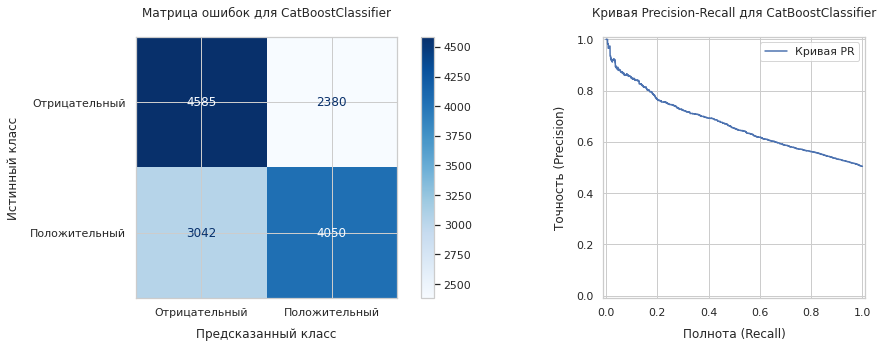


Текстовый отчёт:
Истинно отрицательные (TN): 4585 (32.6%)
Ложноположительные (FP): 2380 (16.9%)
Ложноотрицательные (FN): 3042 (21.6%)
Истинноположительные (TP): 4050 (28.8%)

Precision = TP/(TP+FP): 0.630
Recall = TP/(TP+FN): 0.571
F1-score: 0.599


In [ ]:
# Для CatBoostClassifier
display_model_performance(
    y_test,
    prediction_cb,
    best_model_cb.predict_proba(X_test)[:, 1],  # вероятности положительного класса
    'CatBoostClassifier'
)

На матрице ошибок мы можем заметить, что модель плохо предсказывает истинный класс 1 (около 28 % попаданий), чаще относя объекты к классу 0, чем к классу 1.

Кривая Precision-Recall (PR-кривая) — также важный инструмент для оценки качества классификатора, особенно в задачах с несбалансированными классами. Вот как её можно интерпретировать:


1. Форма:  

- Левая часть кривой (высокий Precision (точность), низкий Recall(полнота)):  
    - На старте кривой при Recall близком к 0 модель демонстрирует высокую Precision. Это означает, что для самых "уверенных" прогнозов положительного класса мы получаем минимальное количество ложных срабатываний.  
    - Однако, столь низкий Recall указывает, что модель пропускает значительную часть реальных положительных случаев (высокий FN).  

- Центральный участок (баланс Precision-Recall):  
     В области Recall 0.4-0.6 Precision снижается до 0.65-0.75. Это говорит о том, что:  
     - При попытке охватить больше положительных примеров модель начинает включать менее очевидные случаи, что закономерно увеличивает ошибки (FP).  
     - Наклон кривой здесь достаточно плавный, что свидетельствует о стабильной работе модели.  

- Правая часть (низкий Precision, высокий Recall):  
     При Recall > 0.7 Precision падает ниже 0.5. Это критическая зона, где модель приносит больше "шума" (FP), чем полезных прогнозов.  
     

2. Оптимальный компромисс: Для нашей бизнес-задачи (минимизация пропущенных положительных случаев) целесообразно выбрать точку с Recall около 0.6-0.7, где Precision сохраняется на уровне 0.55-0.65.  

То есть необходима ручная настройки порога.  

3. Площадь под кривой AUC-PR указывает, что модель:
     - лучше случайного угадывания;
     - но не достигает уровня "отличной" модели.
     
То есть модель имеет потенциал, но требует доработок для смещения кривой вверх.  

4. Сравнение с матрицей ошибок:  подтвердает, что автоматически выбранный порог в 0.5 неоптимален для нашей задачи.  

На основании этого мы можем сказать, что модель требует оптимизации под нашу бизнес-задачу.

Можно попробовать поменять параметры модели (дать больше вариантов перебора и возможно выйдет найти лучшую).

Или изменить порог классификации, используя точку на кривой, где Precision и Recall дают лучший компромисс для нашей задачи. В данном случае нам важнее не допустить потенциальных виновников к управлению, за что отвечает метрика Recall (полнота). Она показывает, насколько хорошо модель выявляет все положительные случаи в наборе данных и рассчитывается как отношение количества верно предсказанных положительных случаев к общему количеству положительных случаев, включая те, которые модель не смогла правильно идентифицировать.

Также посмотрим на важность признаков по мнению модели.

In [ ]:
### Исправленная функция `feat_shap_cb` для CatBoost:
# вариант 1

def feat_shap_cb(best_model, X, feature_names=None):
    """
    Анализ важности признаков для CatBoostClassifier с помощью SHAP

    Параметры:
    ----------
    best_model : CatBoostClassifier
        Обученная модель CatBoost
    X : pd.DataFrame или np.array
        Данные для анализа
    feature_names : list, optional
        Список названий признаков. Если None, будут использованы имена из DataFrame

    Возвращает:
    ----------
    shap_importance_df : pd.DataFrame
        DataFrame с важностью признаков
    """

    # Проверяем и обрабатываем имена признаков
    if feature_names is None:
        if hasattr(X, 'columns'):
            feature_names = X.columns.tolist()
        else:
            feature_names = [f'Feature_{i}' for i in range(X.shape[1])]

    # Создаем explainer для CatBoost
    explainer = shap.TreeExplainer(
        best_model,
        feature_perturbation="tree_path_dependent",
        model_output="raw"
    )

    # Вычисляем SHAP значения
    shap_values = explainer.shap_values(X)

    # Для бинарной классификации CatBoost возвращает один массив
    if isinstance(shap_values, list):
        shap_values = shap_values[1] if len(shap_values) == 2 else np.mean(shap_values, axis=0)

    # Создаем графики
    plt.figure(figsize=(15, 6))

    # 1. График важности признаков
    plt.subplot(1, 2, 1)
    shap.summary_plot(
        shap_values,
        X,
        feature_names=feature_names,
        plot_type="bar",
        show=False
    )
    plt.title("Важность признаков (mean|SHAP|)")

    # 2. График влияния признаков
    plt.subplot(1, 2, 2)
    shap.summary_plot(
        shap_values,
        X,
        feature_names=feature_names,
        plot_type="dot",
        show=False
    )
    plt.title("Влияние признаков на прогноз")

    plt.tight_layout()
    plt.show()

    # Создаем DataFrame с важностью признаков
    shap_importance = np.abs(shap_values).mean(axis=0)
    shap_importance_df = pd.DataFrame({
        'feature': feature_names,
        'shap_importance': shap_importance
    }).sort_values('shap_importance', ascending=False)

    print("\nТоп-10 самых важных признаков по SHAP:")
    print(shap_importance_df.head(10))

    return shap_importance_df

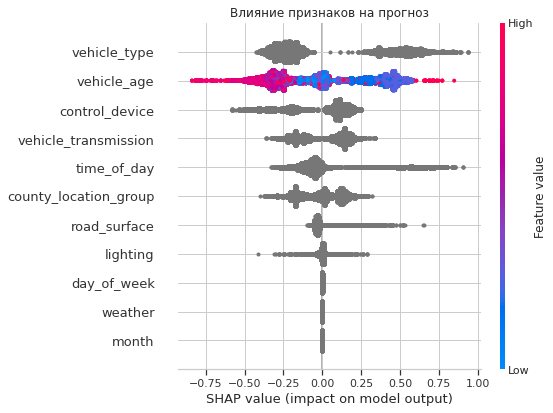


Топ-10 самых важных признаков по SHAP:
                  feature  shap_importance
0            vehicle_type             0.33
2             vehicle_age             0.27
6          control_device             0.16
1    vehicle_transmission             0.15
9             time_of_day             0.14
10  county_location_group             0.11
4            road_surface             0.06
5                lighting             0.01
8             day_of_week             0.00
3                 weather             0.00


In [ ]:
# Анализ SHAP
shap_results_cb = feat_shap_cb(best_model_cb, X_train)

# Если нужно явно указать имена признаков:
# shap_results_cb = feat_shap_cb(best_model_cb, X_train, feature_names=X_train.columns.tolist())

Лучшая модель сочла самым важным признаком тип кузова.

И хотя мы это уже делали в разделе исследовательского анализа, визуализируем дополнительно.

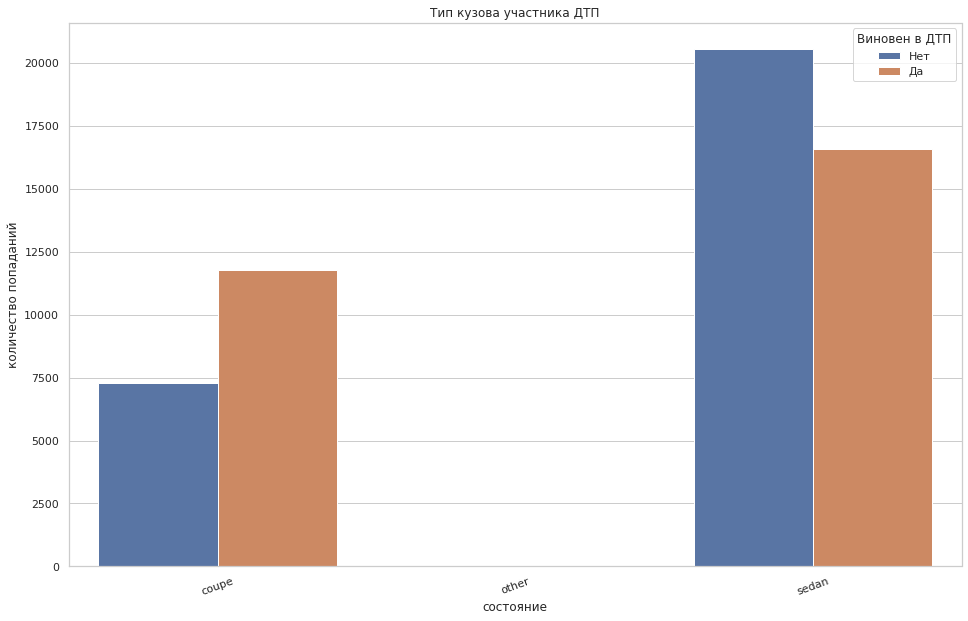

In [ ]:
# состояние участника
# общий график для наглядности
plt.figure(figsize=(16,10))

# Создаем общий график с разделением по признаку at_fault
sns.countplot(x=dtp['vehicle_type'], hue='at_fault', data=dtp)

plt.title('Тип кузова участника ДТП')
plt.xlabel('состояние')
plt.ylabel('количество попаданий')

# Добавляем легенду для пояснения цветов
plt.legend(title='Виновен в ДТП', labels=['Нет', 'Да'])

# наклоняем надписи на оси x
plt.xticks(rotation=20)

plt.show()

И действительно, автомобили с кузовом купе чаще становится виновником ДТП, чем с типом седан. Возможно, они мешают обзору ситуации позади автомобиля? Либо сами автомобили тяжелее и хуже управляются.

Если повышенный шанс стать виновником ДТП у автомобилей с типом кузова купе исходит от ограниченности обзора, можно рекомендовать оборудовать автомобиль дополнительными зеркалами заднего вида и дополнительными боковыми.

Однако в текущей ситуации с имеющимися данными адекватную систему оценки риска при выдаче авто создать не выйдет. Необходимо все-таки попробовать учесть и другие факторы. Например - то самое состояние трезвости `'party_sobriety'`. Автомобили заказчика не имеют датчиков для его оценки, однако  имеются исторические данные, которые в ходе исследовательского анализа показали связь с целевым признаком. Потенциально ограничение доступа нетрезвого водителя к управлению автомобилем (например, через обязательное тестирования на датчике алкоголя под камерой перед доступом к управлению) поможет снизить случаи виновности участников. Поэтому, несмотря на затраты по реализации такой системы, она может оказаться потенциально выгодной (сохраняя жизни и здоровье участников, а также целостность автомобиля, что вместе сос нижением количества "пьяных" ДТП за рулем автомобиля заказчика поможет укрепить положительную репутацию и принести новую клиентуру".

Также мы можем наблюдать, что, по мнению модели, месяц на шанс стать виновником не влияет (в отличие от дня недели). Погода также не оказывает влияние на виновность.

**Выводы**

- Полученная модель хоть и модет считаться лучше случайного угадывания, однако все-таки не может считаться пригодной для адекватной оценки водительского риска. Она требует доработки и оптимизации для нашей бизнес-задачию

- Самым важным признаком модель сочла тип автомобиля: седаны реже становятся виновниками ДТП, чем купе. Можно предположить, что это вызвано различными габаритами автомобилей и ухудшением обзора заднего вида для купе. Ввиду этого можно предложить оборудовать автомобили с данным типом кузова дополнительными зеркалами для лучшего обзора.

- Однако в текущей ситуации с имеющимися данными адекватную систему оценки риска при выдаче авто создать не выйдет. Необходимо все-таки попробовать учесть и другие факторы. Например - то самое состояние трезвости `'party_sobriety'`, которое на исследовательском анализа показало увеличение шансов на виновность ДТП при различных состояниях, связанных с алкоголем (и уменьшкние таких шансов - в трезвом состоянии).

- Также мы можем наблюдать, что, в отличие от дня недели, по мнению модели, месяц на шанс стать виновником не влияет. Погода также не оказывает влияние на виновность.

## Выводы

В рамках проекта мы и обучили одну базовую (Dummy Classifier (most frequent)) и четыре вида моделей для сравнения (LogisticRegression, RandomForestClassifier, LGBMClassifier, CatBoostClassifier).

Для их оценки использовалась метрика f1.

Лучшей стала модель CatBoostClassifier с указанными ниже параметрами, чья метрика на тесте составила *0.591*

In [ ]:
# параметры лучщей модели
best_model_cb.get_params()

{'verbose': 0,
 'random_state': 42,
 'cat_features': ['vehicle_type',
  'vehicle_transmission',
  'weather',
  'road_surface',
  'lighting',
  'control_device',
  'month',
  'day_of_week',
  'time_of_day',
  'county_location_group'],
 'iterations': 10,
 'learning_rate': 0.9,
 'max_depth': 10}

Данная модель нуждается в оптимизации (например, изменения порога классификации для увеличения  метрики Recall (полноты)
Самыми важными признаками модель сочла:
- тип кузова (как мы помним, автомобили с кузовом "седан" чаще становятся виновниками ДТП, чем "купе";
- возраст, который проявляет свое влияние неоднородно: какие-то значения увеличивают риск ДТП, какие-то - снижают, что мы наблюдали ранее на гистограмме.

Также по мнению модели месяц (в отличие от дня недели) на шанс стать виновником не влияет. Погода также не оказывает влияние на виновность.

Для решения первой проблемы (автомобили с типом кузова купе чаще попадают в ДТП, чем седан) можно рекомендовать оборудовать "проблемные" автомобили дополнительными зеркалами для улучшения обзора.

В данных мы наблюдали большое количество проблем (которые будут дополнительно обозначены в рекомендациях). После максимально возможной обработки данных кореляций с целевым признаком выше умеренной у признаков не выявлено. Все это создает сложности в адекватном обучении модели.

Поэтому рекомендуется максимально устранить выявленные проблемы, а также начать собирать дополнительные данные, чтобы провести новое, лучшее исследование.

Такими данными могут быть:
- данные, которые учитывают страховые для рассчета суммы страховки:
    * стаж вождения (более опытные водители могут реже становится виновниками ДТП);
    * количество ДТП, в которых участник был виновником за определенный период (их отутвтвие может говорить о более аккуратном вождении)
- иные данные:
    * скоростной режим на дорогах выбранного маршрута;
    * скорость передвиждения автомобиля незадолго до ДТП;
    * время посадки;
    * время поездки.
    
Также стоит попробовать учесть и другие факторы, которые уже у нас исторически накопились и потенциально поддаются оценке перед посадкой или попаданием в ДТП. Например - то самое состояние трезвости `'party_sobriety'`, которое на исследовательском анализе показало увеличение шансов на виновность ДТП при различных состояниях, связанных с алкоголем (и уменьшение таких шансов - в трезвом состоянии). Потенциальные расходы на установку камер и анализаторов (и их дополнительную настройку) смогут окупиться через увеличение безопасности поездок и укрепление положительной репутации, а следовательно - притоку клиентов.
    
Также модели лучше строить отдельные для разных городов, так как с данным признаком целевой показывал хорошую корреляцию. К тому же логично, что в разных георафических местах условия как дорожные, так и климатические и прочее отличаются.

## Дополнительные рекомендации заказчику

1. Предпринять мероприятия для снижения шансов попадания участников на автомобиле с кузовом купе в ДТП. Например, оборудовав данные автомобили дополнительными зеркалами для улучшения обзора.

2. Решить проблемы в данных:

- Актуализировать описание данных и настроить соответствие ER-диаграмме.
- Уточнить целесообразность существования таблицы `'case_ids'`.
- Рассмотреть использование для `'case_id'` числового, а не текстовый формата (предварительно проверив отстутствие применения букв в имеющихся значениях) в целях удобства применения и экономии места.
- Выяснить причины отсутствия данных за некоторые периоды (например, за период с 2014 по 2019 данные отсутствуют полностью, а данные за 2020 год неполные) в данной БД и минимизировать возможность их возникновения в будущем.
- Выяснить причины отсутствия данных для большой части участвовавших в ДТП автомобилей в нашей БД (особенно уделить внимание типам "minivan" или "hatchback" за период 2012 года).
- Выяснить причины резкого падения числа ДТП начиная с мая 2012 года.
- Выяснить причины появления аномального возраста большого числа автомобилей в 161 год.
- Выяснить причины возникновения различных пропусков в данных в целом и минимизировать возможность их возникновения в будущем.
- Уточнить возрастной состав автопарка и его соответствие таковому в базе данных (например, трехлетние автомобили чаще становятся виновниками ДТП, но возможно их в принципе больше всего было на момент сбора данных).
- Провести дополнительное исследование после устранения проблем с данными и их освежением. Это поможет получить более достоверную информацию и построить лучшую модель, а также позволит исследовать зависимость различных факторов между собой.

3. Начать сбор новых признаков, например:
- данные, которые учитывают страховые для рассчета суммы страховки:
    * стаж вождения (более опытные водители могут реже становится виновниками ДТП);
    * количество ДТП, в которых участник был виновником за определенный период (их отсутвтвие может говорить о более аккуратном вождении)
- иные данные:
    * скоростной режим на дорогах выбранного маршрута;
    * скорость передвиждения автомобиля незадолго до ДТП;
    * время посадки;
    * время поездки до наступления ДТП.
    
4. Рассмотреть возможность построения различных моделей для разных регионов ввиду возможного наличия климатических и инфраструктурных особеностей.

5. Пока остальные данные приводятся в порядок и собираются новые - рассмотреть возможность применения уже исторически накопившегося признака, который потенциально можно определить перед посадкой или моментом попадания в ДТП с помощью установки дополнительного оборудования. Например, использовать для прогнозирования признак`'party_sobriety'`, который на исследовательском анализе показал увеличение шансов на виновность ДТП при различных состояниях, связанных с алкоголем (и уменьшение таких шансов - в трезвом состоянии). Потенциальные расходы на установку камер и анализаторов (и их дополнительную настройку) смогут окупиться через увеличение безопасности поездок и укрепление положительной репутации, а следовательно - притоку клиентов.

## Приложение

### Более подробное описание данных

Здесь приведено описание данных из таблиц с уже исправленными (под видимые в выводе) именованиями стобцов, так как изначально (в прилагаемом к самостоятельному проекту вводному документу) они не соответствовали реальным: все были указаны целиком прописными буквами (несмотря на строчные в ER-диаграмме), также могли частично не совпадать имена столбцов (например, заявлено `'PRIMARY_COLL_FACTOR'` вместо реального `'primary_collision_factor'` в таблице `'collisions'`).

Само же содержимое столбцов (хоть и не всегда обозначения совпадают, например, заявлено `'N'` (Север) в столбце с направлением движения таблицы  `'collisions'` вместо реального `'north'` ) не редактировалось.

Возможно, в реальности таблицы выглядят так, как заявлены в исходном описании, а для проекта были специально заранее приведены в понятный вид. Но узнать это не представляется возможным.

Таблицы:

**case_ids** (индексы происшествий)

**parties** (описание участников происшествия)

- *case_id* (уникальный номер зарегистрированного происшествия в таблице происшествий);
    party_number (номер участника происшествия) - от 1 до N: по числу участников происшествия;
    party_type (тип участника происшествия):
        1 - Car (Авто);
        2 - Road bumper (Дорожные знаки);
        3 - Building (Строения);
        4 - Road signs (Отбойник);
        5 - Other (Другое);
        6 - Operator (Оператор);
        _ - Not Stated (Не указано).
- *at_fault* (виновность участника) - 0 или 1;
    insurance_premium (сумма страховки);
    party_drug_physical (состояние чуастника: физическое или с учетом принятых лекарств):
        E - Under Drug Influence (Под воздействием лекарств);
        F - Impairment Physical (Ухудшение состояния);
        G - Impairment Unknown (Не известно);
        H - Not Applicable (Не оценивался);
        I - Sleepy / Fatigued (Сонный / усталый);
        _ - Not Stated (Не указано).
- *party_sobriety* (трезвость участника):
        A - Had Not Been Drinking (Не пил);
        B - Had Been Drinking, Under Influence (Был пьян, под влиянием);
        C - Had Been Drinking, Not Under Influence (Был пьян, не под влиянием);
        D - Had Been Drinking, Impairment Unknown (Был пьян, ухудшение неизвестно);
        G - Impairment Unknown (Неизвестно ухудшение);
        H - Not Applicable (Не оценивался);
        _ - Not Stated (Не указано).
- *cellphone_in_use* (наличие телефона в автомобиле) - 0 или 1

**vehicles** (описание автомобиля)

- *id* (индекс текущей таблицы);
- *case_id* (идентификационный номер в базе данных);
- *vehicle_type* (тип кузова):
        MINIVAN;
        COUPE;
        SEDAN;
        HATCHBACK;
        OTHER.
- *vehicle_transmission* (тип КПП):
        auto (Автоматическая).
        manual (Ручная).
        _ - Not Stated (Не указано)
- *vehicle_age* (возраст автомобиля).

**collisions** (информация о происшествия)

- *case_id* (идентификационный номер в базе данных);
- *collision_date* (дата происшествия);
- *collision_time* (время происшествия);
- *intersection* (является ли место происшествия перекрестком):
        Y — Intersection (перекрёсток);
        N — Not Intersection (не перекрёсток);
        _ Not stated (Не указано).
- *weather_1* (погода):
        A — Clear (Ясно);
        B — Cloudy (Облачно);
        C — Raining (Дождь);
        D — Snowing (Снегопад);
        E — Fog (Туман);
        F — Other (Другое);
        G — Wind (Ветер);
- *collision_damage* (серьезность происшествия):
        Fatal TC (Не подлежит восстановлению);
        Severe Damage (Серьезное повреждение);
        Middle Damage (Машина в целом на ходу);
        Small Damage (Отдельный элемент под замену / покраску);
        Scratch (Царапина).
- *primary_collision_factor* (основной фактор аварии):
        A - Code Violation (Нарушение правил ПДД);
        B - Other Improper Driving (Другое неправильное вождение);
        C - Other Than Driver (Кроме водителя);
        D - Unknown (Неизвестно);
        E - Fell Asleep (Заснул);
        _ - Not Stated (Не указано).
- *road_surface* (состояние дороги):
        A — Dry (Сухая);
        B — Wet (Мокрая);
        C — Snowy or Icy (Заснеженная или обледенелая);
        D — Slippery (Muddy, Oily, etc.) (Скользкая, грязная, маслянистая и т. д.);
        _ Not Stated (Не указано).
- *lightning* (освещение):
        A — Daylight (Дневной свет);
        B — Dusk-Dawn (Сумерки-Рассвет);
        C — Dark-Street Lights (Темно-Уличные фонари);
        D — Dark-No Street Lights (Темно-Нет уличных фонарей);
        E — Dark-Street Lights Not Functioning (Темно-Уличные фонари не работают);
        _ Not Stated (Не указано).
- *county_city_location* (номер географических районов, где произошло ДТП);
- *county_location* (названия географических районов, где произошло ДТП);
- *direction* (направление движения):
        N — North (Север)
        E — East (Восток)
        S — South (Юг)
        W — West (Запад)
        _ — Not State (Не указано)
        на перекрёстке
- *distance* (расстояние до главной дороги в метрах);
- *location_type* (тип дороги):
        H — Highway (Шоссе);
        I — Intersection (Перекрёсток);
        R — Ramp (or Collector) (Рампа);
        _ — Not State Highway (Не указано).
- *party_count* (количество участников);
- *pcf_violation_category* (категория нарушения):
        01 - Driving Under the Influence of Alcohol or Drug - Вождение или езда в состоянии алкогольного или наркотического опьянения;
        02 - Impeding Traffic - Препятствие движению транспорта;
        03 - Unsafe Speed - Превышение скорости;
        04 - Following Too Closely - Опасное сближение;
        05 - Wrong Side of Road - Неправильная сторона дороги;
        06 — Improper Passing - Неправильное движение;
        07 — Unsafe Lane Change - Небезопасная смена полосы движения;
        08 — Improper Turning - Неправильный поворот;
        09 — Automobile Right of Way - Автомобильное право проезда;
        10 — Pedestrian Right of Way - Пешеходное право проезда;
        11 — Pedestrian Violation - Нарушение пешеходами;
        12 — Traffic Signals and Signs - Дорожные сигналы и знаки;
        13 — Hazardous Parking - Неправильная парковка;
        14 — Lights - Освещение;
        15 — Brakes - Тормоза;
        16 — Other Equipment - Другое оборудование;
        17 — Other Hazardous Violation - Другие нарушения;
        18 — Other Than Driver (or Pedestrian) - Кроме водителя или пешехода;
        19 — Speeding - Скорость;
        20 — Pedestrian dui - Нарушение пешехода;
        21 — Unsafe Starting or Backing - Опасный старт;
        22 — Other Improper Driving - Другое неправильное вождение;
        23 — Pedestrian or “Other” Under the Influence of Alcohol or Drug - Пешеход или «Другой» в состоянии алкогольного или наркотического опьянения;
        24 — Fell Asleep - Заснул;
        00 — Unknown - Неизвестно;
        _ - Not Stated - Не указано.
- *type_of_collision* (тип аварии):
        A — Head-On (Лоб в лоб);
        B — Sideswipe (Сторона);
        C — Rear End (Столкновение задней частью);
        D — Broadside (Боковой удар);
        E — Hit Object (Удар объекта);
        F — Overturned (Опрокинутый);
        G — Vehicle (транспортное средство/ Пешеход);
        H — Other (Другое);
        _ - Not Stated (Не указано).
- *motor_vehicle_involved_with* (дополнительные участники ДТП):
        Other motor vehicle (Другой автомобиль);
        Fixed object (Неподвижный объект);
        Parked motor vehicle (Припаркованный автомобиль);
        Pedestrian (Пешеход);
        Bicycle (Велосипедист);
        Non-collision (Не столкновение);
        Other object (Другой объект);
        Motor vehicle on other roadway (Автомобиль на другой проезжей);
        Animal (Животное);
        Train (Поезд).
- *road_condition_1* (дорожное состояние):
        A — Holes, Deep Ruts (Ямы, глубокая колея);
        B — Loose Material on Roadway (Сыпучий материал на проезжей части);
        C — Obstruction on Roadway (Препятствие на проезжей части);
        D — Construction or Repair Zone (Зона строительства или ремонта);
        E — Reduced Roadway Width (Уменьшенная ширина проезжей части);
        F — Flooded (Затоплено);
        G — Other (Другое);
        H — No Unusual Condition (Нет ничего необычного);
        _ — Not Stated (Не указано).
- *control_device* (устройство управления):
        A — Functioning (Функционирует);
        B — Not Functioning (Не функционирует);
        C — Obscured (Затемнённый);
        D — None (Нет);
        _ Not Stated (Не указано).
